# 09 — LSTM Validators for Alternative Models

This notebook reframes the standalone LSTM and the LSTM-EnKF preprocessor model as **validation tools** rather than as the primary winning forecasters.

The working verdict from notebooks 7–8 is that the LSTM-EnKF branch is not a statistically stronger standalone forecaster. Its useful role may instead be operational: it can validate, dispute, or flag forecasts from the more sensitive alternative models in notebook 6.

The notebook asks six questions:

1. Which validator is better at detecting when an alternative model is wrong?
2. Do the two validators detect the *same* errors, or do they capture complementary failure modes?
3. Do validator signals add information *beyond* the alternative model's own uncertainty?
4. When an alternative model and validator agree, is the forecast safer to accept?
5. When they disagree, how often does that disagreement capture alternative-model errors, missed events, or false alarms?
6. If the validator adjudicates disagreements, does performance improve or degrade?

Caveat: several notebook 6 alternatives are LSTM-derived or include the standalone LSTM as a component. Treat this as validation/triage consistency evidence, not fully independent external validation.


## Setup

In [11]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

from shared_config import *
print_config_summary()

SEED = 42
np.random.seed(SEED)

VALIDATION_DIR = os.path.join(OUTPUT_DIR, 'validation_tools')
os.makedirs(VALIDATION_DIR, exist_ok=True)

plt.rcdefaults()
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {
    'Standalone LSTM': '#1976D2',
    'LSTM-EnKF validator': '#D32F2F',
    'accepted': '#2E7D32',
    'flagged': '#F57C00',
    'gray': '#6B7280',
    'light_gray': '#E5E7EB',
    'dark': '#111827',
}
MODEL_COLORS = ['#5C6BC0', '#26A69A', '#F57C00', '#7B1FA2', '#455A64', '#C62828']


def savefig(fig, stem):
    png = os.path.join(VALIDATION_DIR, f'{stem}.png')
    pdf = os.path.join(VALIDATION_DIR, f'{stem}.pdf')
    fig.savefig(png, dpi=300, bbox_inches='tight')
    fig.savefig(pdf, dpi=300, bbox_inches='tight')
    print(f'  saved {png}')
    print(f'  saved {pdf}')


def display_df(df):
    try:
        display(df)
    except NameError:
        print(df.to_string(index=False))


def render_table_figure(df, stem, title, max_rows=24):
    if df is None or df.empty:
        return
    shown = df.copy().head(max_rows)
    for col in shown.columns:
        if pd.api.types.is_float_dtype(shown[col]):
            shown[col] = shown[col].map(lambda x: '' if pd.isna(x) else f'{x:.3f}')
    n_rows, n_cols = shown.shape
    fig_w = min(15, max(8, 1.25 * n_cols))
    fig_h = min(12, max(2.4, 0.34 * n_rows + 1.3))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')
    ax.set_title(title, loc='left', fontweight='bold', pad=8)
    table = ax.table(cellText=shown.values, colLabels=shown.columns,
                     loc='center', cellLoc='center', colLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.22)
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#D1D5DB')
        cell.set_linewidth(0.5)
        if row == 0:
            cell.set_facecolor('#E8EEF7')
            cell.set_text_props(weight='bold', color=COLORS['dark'])
        elif row % 2 == 0:
            cell.set_facecolor('#F8FAFC')
    if len(df) > max_rows:
        ax.text(0.01, -0.04, f'Showing first {max_rows} of {len(df)} rows.',
                transform=ax.transAxes, fontsize=8, color=COLORS['gray'])
    savefig(fig, stem)
    plt.show()


def save_table(df, filename, title=None, render=True, max_rows=24):
    path = os.path.join(VALIDATION_DIR, filename)
    df.to_csv(path, index=False)
    print(f'  saved table {path}')
    display_df(df)
    if render:
        render_table_figure(df, filename.replace('.csv', ''), title or filename.replace('.csv', ''), max_rows=max_rows)
    return path


def safe_auc(y_true, score):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2 or not np.isfinite(score).all():
        return np.nan
    return float(roc_auc_score(y_true, score))


def safe_ap(y_true, score):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2 or not np.isfinite(score).all():
        return np.nan
    return float(average_precision_score(y_true, score))


def hard_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'AUC': safe_auc(y_true, y_prob),
        'AUPRC': safe_ap(y_true, y_prob),
        'Brier': float(brier_score_loss(y_true, y_prob)),
        'Accuracy': float(accuracy_score(y_true, y_pred)),
        'Precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'Recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'F1': float(f1_score(y_true, y_pred, zero_division=0)),
    }


def align_tail(y_true, *arrays):
    lengths = [len(y_true)] + [len(a) for a in arrays]
    n = min(lengths)
    return (np.asarray(y_true)[-n:],) + tuple(np.asarray(a)[-n:] for a in arrays)


def disagreement_signal(alt_prob, val_prob, val_threshold):
    """Confidence-weighted disagreement between alt-model and validator.

    The validator's confidence is normalized symmetrically: distance above the
    threshold is divided by (1 - threshold), distance below by the threshold,
    so a confident bloom call and a confident no-bloom call both saturate at 1.
    The earlier formulation divided by max(threshold, 1 - threshold), which
    silently down-weighted confident calls on the smaller side of the threshold.
    """
    alt_prob = np.asarray(alt_prob, dtype=float)
    val_prob = np.asarray(val_prob, dtype=float)
    gap = np.abs(alt_prob - val_prob)
    gap_pos = max(1.0 - float(val_threshold), 1e-6)
    gap_neg = max(float(val_threshold), 1e-6)
    val_conf = np.where(
        val_prob >= val_threshold,
        (val_prob - val_threshold) / gap_pos,
        (val_threshold - val_prob) / gap_neg,
    )
    val_conf = np.clip(val_conf, 0.0, 1.0)
    return gap * val_conf


def holm_adjust(p_values):
    """Holm-Bonferroni adjusted p-values, preserving original order."""
    p = np.asarray(p_values, dtype=float)
    out = np.full_like(p, np.nan, dtype=float)
    finite = np.isfinite(p)
    if finite.sum() == 0:
        return out
    idx = np.where(finite)[0]
    order = idx[np.argsort(p[idx])]
    m = len(order)
    running = 0.0
    for rank, original_idx in enumerate(order):
        adjusted = min(1.0, (m - rank) * p[original_idx])
        running = max(running, adjusted)
        out[original_idx] = running
    return out


def bootstrap_p_two_sided(boot_diffs):
    boot_diffs = np.asarray(boot_diffs, dtype=float)
    boot_diffs = boot_diffs[np.isfinite(boot_diffs)]
    if len(boot_diffs) == 0:
        return np.nan
    return float(min(1.0, 2.0 * min(np.mean(boot_diffs <= 0), np.mean(boot_diffs >= 0))))


--- Workflow Configuration Summary ---
Enhanced Features Enabled:     True
Scaler Type Selected:          Robust
Class Weighting Enabled:       True
Hyperparameter Tuning Enabled: True
EnKF Enabled:                  True
FAST_TEST Mode:                False
Sequence Length (default):     26
Forecast Horizon:              1 week(s)
Output directory:              output_refactored/
--------------------------------------


## Load Artifacts

In [12]:
if not os.path.exists(ALT_MODEL_STREAMS_PATH):
    raise FileNotFoundError(f'Missing {ALT_MODEL_STREAMS_PATH}. Run notebook 06 first.')

with np.load(ALT_MODEL_STREAMS_PATH) as data:
    streams = {k: data[k].astype(float) for k in data.files}

y_test = streams['y_test'].astype(int)

# Prefer the streams bundled by notebook 06, then fall back to notebook 03 outputs.
if 'lstm' not in streams and os.path.exists(LSTM_TEST_PROBS_PATH):
    streams['lstm'] = np.load(LSTM_TEST_PROBS_PATH).astype(float).flatten()
if 'lstm_enkf_preprocessor' not in streams and os.path.exists(LSTM_ENKF_TEST_PROBS_PATH):
    streams['lstm_enkf_preprocessor'] = np.load(LSTM_ENKF_TEST_PROBS_PATH).astype(float).flatten()

with open(BASELINE_METRICS_PATH) as f:
    standalone_metrics_json = json.load(f)
with open(LSTM_ENKF_METRICS_PATH) as f:
    enkf_metrics_json = json.load(f)

validator_specs = {
    'Standalone LSTM': {
        'key': 'lstm',
        'threshold': float(standalone_metrics_json.get('threshold_used', 0.5)),
    },
    'LSTM-EnKF validator': {
        'key': 'lstm_enkf_preprocessor',
        'threshold': float(enkf_metrics_json.get('threshold_used', 0.5)),
    },
}

missing_validators = [name for name, spec in validator_specs.items() if spec['key'] not in streams]
if missing_validators:
    raise FileNotFoundError(f'Missing validator streams: {missing_validators}')

alternate_keys = [
    k for k in streams
    if k not in {'y_test', 'lstm', 'lstm_enkf_preprocessor'}
]
name_map = {
    'var': 'VAR',
    'regime_switching': 'Regime-switching',
    'pinn': 'PINN-augmented LSTM',
    'lstm_gp': 'LSTM + GP',
    'hybrid_ensemble': 'Hybrid ensemble',
}
alternate_names = {k: name_map.get(k, k) for k in alternate_keys}

print('Validators:')
for name, spec in validator_specs.items():
    print(f"  {name}: stream={spec['key']}, threshold={spec['threshold']:.3f}, n={len(streams[spec['key']])}")
print('\nAlternative model streams:')
for key in alternate_keys:
    print(f"  {alternate_names[key]} ({key}) n={len(streams[key])}")
print(f'Outcome n={len(y_test)}, bloom rate={y_test.mean():.3f}')

Validators:
  Standalone LSTM: stream=lstm, threshold=0.658, n=216
  LSTM-EnKF validator: stream=lstm_enkf_preprocessor, threshold=0.771, n=216

Alternative model streams:
  VAR (var) n=216
  Regime-switching (regime_switching) n=216
  PINN-augmented LSTM (pinn) n=216
  LSTM + GP (lstm_gp) n=216
  Hybrid ensemble (hybrid_ensemble) n=216
Outcome n=216, bloom rate=0.324


## Baseline Skill of Validators and Alternative Models

  saved table output_refactored/validation_tools\Table9_model_skill_baseline.csv


,role,model,threshold,AUC,AUPRC,Brier,Accuracy,Precision,Recall,F1
0,validator,Standalone LSTM,0.658039,0.945890,0.842390,0.099344,0.898148,0.792683,0.928571,0.855263
1,validator,LSTM-EnKF validator,0.771356,0.935910,0.863625,0.148470,0.870370,0.756098,0.885714,0.815789
2,alternative,VAR,0.500000,0.969178,0.928204,0.103064,0.833333,0.947368,0.514286,0.666667
3,alternative,Regime-switching,0.500000,0.956164,0.912990,0.112754,0.893519,0.764045,0.971429,0.855346
4,alternative,PINN-augmented LSTM,0.500000,0.939726,0.869109,0.110397,0.851852,0.702128,0.942857,0.804878
5,alternative,LSTM + GP,0.500000,0.939432,0.803597,0.096296,0.861111,0.722222,0.928571,0.812500
6,alternative,Hybrid ensemble,0.500000,0.965753,0.918692,0.064874,0.925926,0.875000,0.900000,0.887324


  saved output_refactored/validation_tools\Table9_model_skill_baseline.png
  saved output_refactored/validation_tools\Table9_model_skill_baseline.pdf


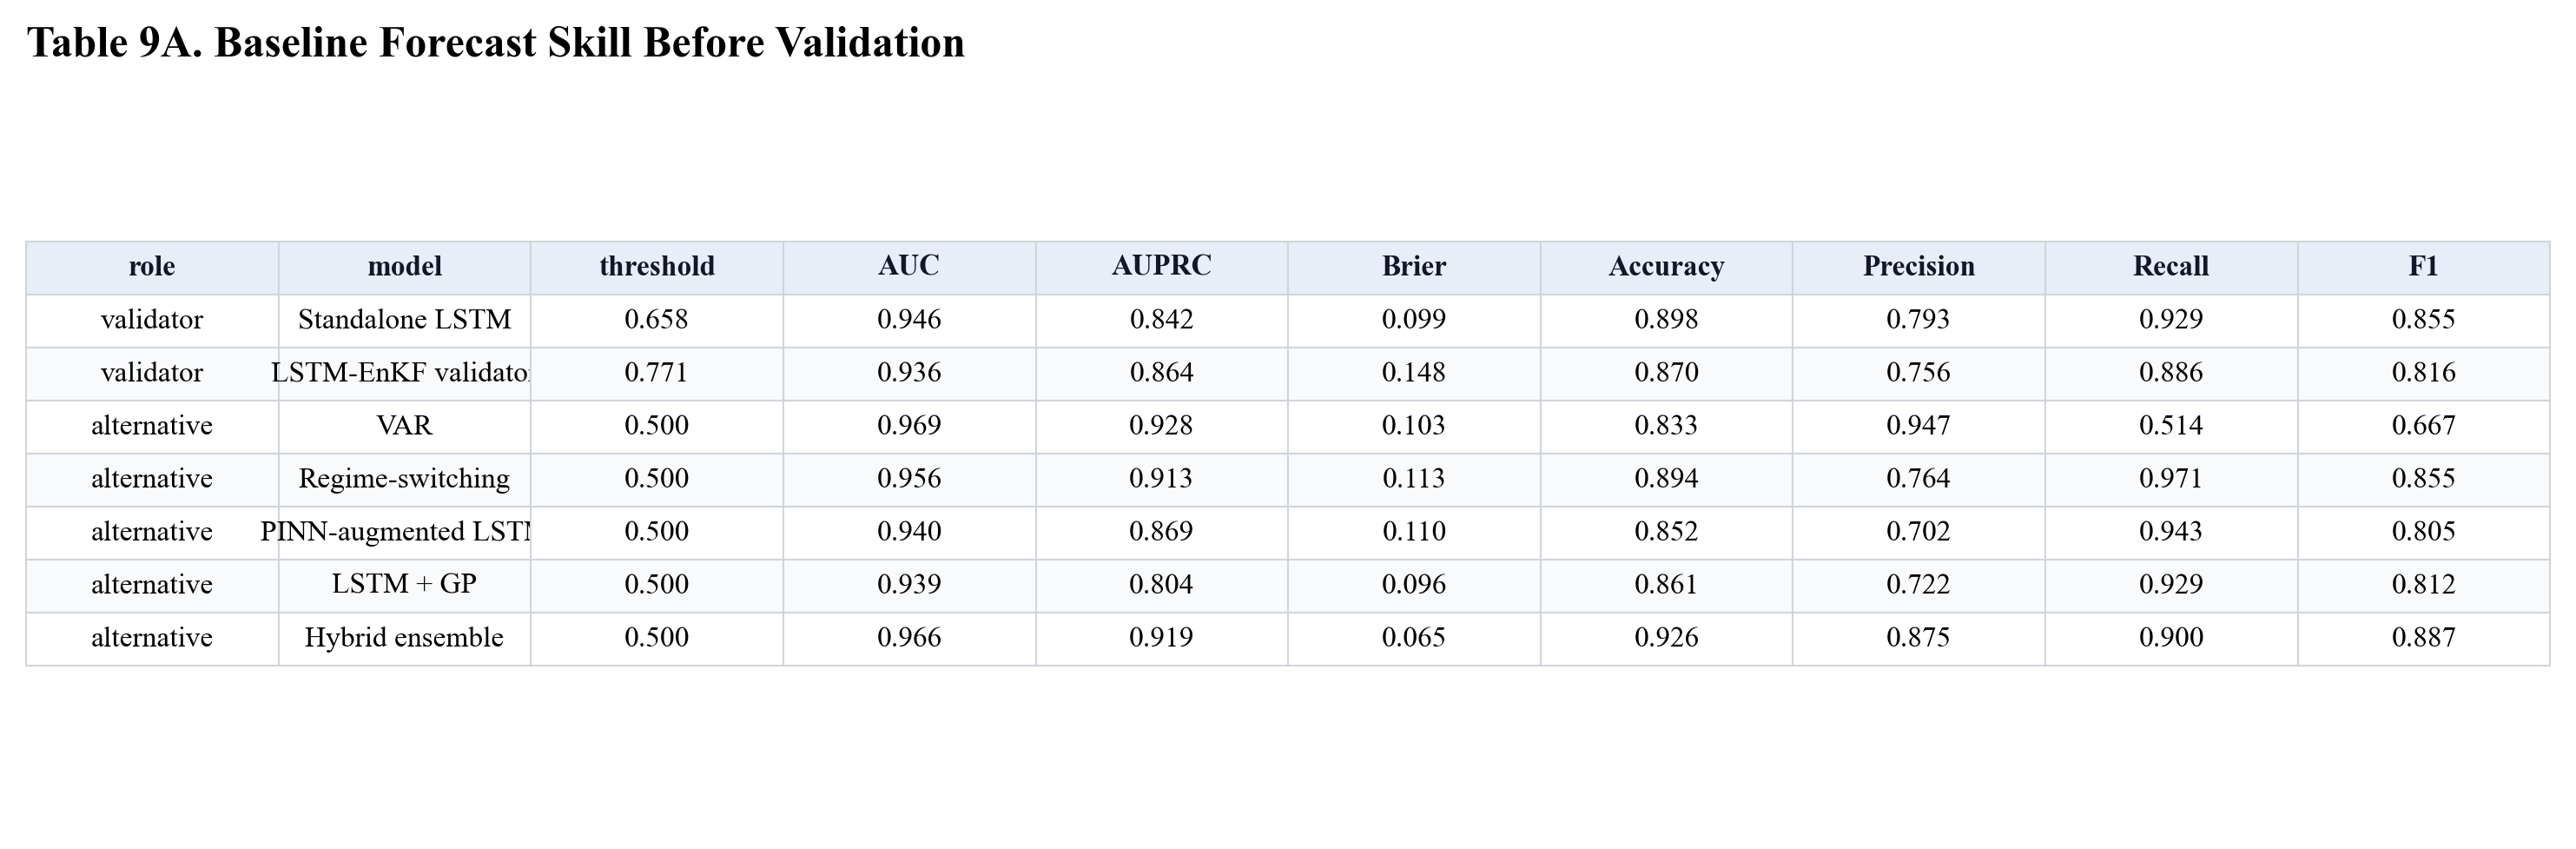

  saved output_refactored/validation_tools\Fig9A_model_skill_baseline.png
  saved output_refactored/validation_tools\Fig9A_model_skill_baseline.pdf


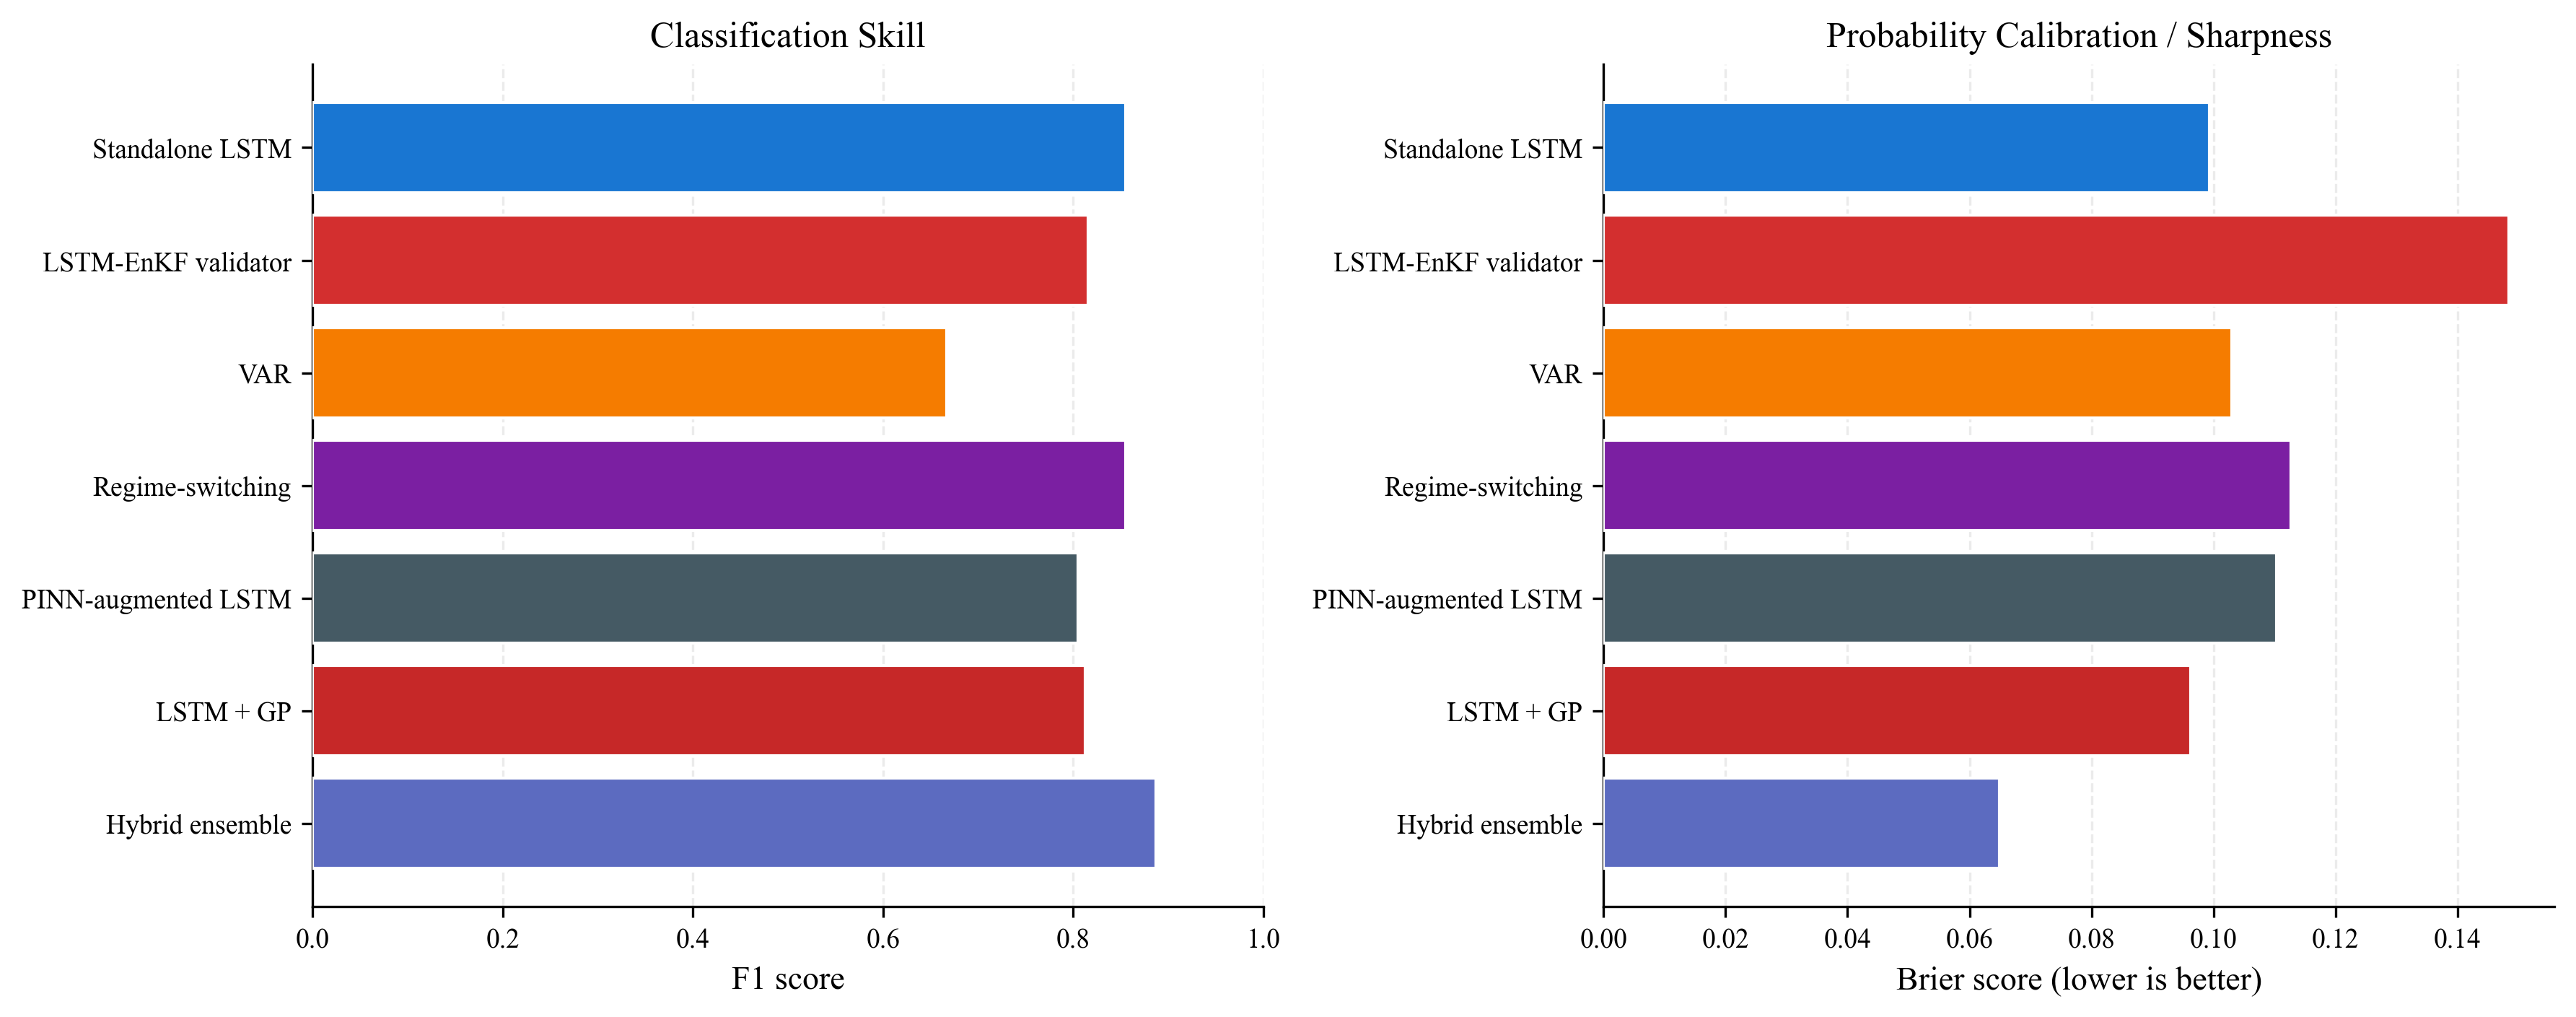

In [13]:
rows = []
for validator_name, spec in validator_specs.items():
    y, p = align_tail(y_test, streams[spec['key']])
    row = {'role': 'validator', 'model': validator_name, 'threshold': spec['threshold']}
    row.update(hard_metrics(y, p, threshold=spec['threshold']))
    rows.append(row)

for key in alternate_keys:
    y, p = align_tail(y_test, streams[key])
    row = {'role': 'alternative', 'model': alternate_names[key], 'threshold': 0.5}
    row.update(hard_metrics(y, p, threshold=0.5))
    rows.append(row)

skill_df = pd.DataFrame(rows)
save_table(skill_df, 'Table9_model_skill_baseline.csv',
           'Table 9A. Baseline Forecast Skill Before Validation')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
plot_df = skill_df.copy()
colors = [COLORS.get(m, MODEL_COLORS[i % len(MODEL_COLORS)]) for i, m in enumerate(plot_df['model'])]
axes[0].barh(plot_df['model'], plot_df['F1'], color=colors, edgecolor='white', zorder=3)
axes[0].set_xlabel('F1 score')
axes[0].set_title('Classification Skill')
axes[0].set_xlim(0, 1)
axes[0].grid(axis='x', alpha=0.25, linestyle='--', zorder=0)
axes[1].barh(plot_df['model'], plot_df['Brier'], color=colors, edgecolor='white', zorder=3)
axes[1].set_xlabel('Brier score (lower is better)')
axes[1].set_title('Probability Calibration / Sharpness')
axes[1].grid(axis='x', alpha=0.25, linestyle='--', zorder=0)
for ax in axes:
    ax.invert_yaxis()
plt.tight_layout()
savefig(fig, 'Fig9A_model_skill_baseline')
plt.show()

## Validator Disagreement as an Error Detector

  saved table output_refactored/validation_tools\Table9_validator_error_detection.csv


,alternative_model,validator,signal,AUROC_alt_wrong,AUPRC_alt_wrong,alt_error_rate
0,VAR,Standalone LSTM,Hard disagreement,0.861111,0.563342,0.166667
1,VAR,Standalone LSTM,Probability gap,0.800772,0.348678,0.166667
2,VAR,Standalone LSTM,Confidence-weighted contradiction,0.720370,0.315158,0.166667
3,VAR,LSTM-EnKF validator,Hard disagreement,0.811111,0.473064,0.166667
4,VAR,LSTM-EnKF validator,Probability gap,0.760340,0.292059,0.166667
5,VAR,LSTM-EnKF validator,Confidence-weighted contradiction,0.721451,0.373237,0.166667
6,Regime-switching,Standalone LSTM,Hard disagreement,0.732372,0.323138,0.106481
7,Regime-switching,Standalone LSTM,Probability gap,0.362920,0.080822,0.106481
8,Regime-switching,Standalone LSTM,Confidence-weighted contradiction,0.234512,0.068945,0.106481
9,Regime-switching,LSTM-EnKF validator,Hard disagreement,0.697680,0.250403,0.106481


  saved output_refactored/validation_tools\Table9_validator_error_detection.png
  saved output_refactored/validation_tools\Table9_validator_error_detection.pdf


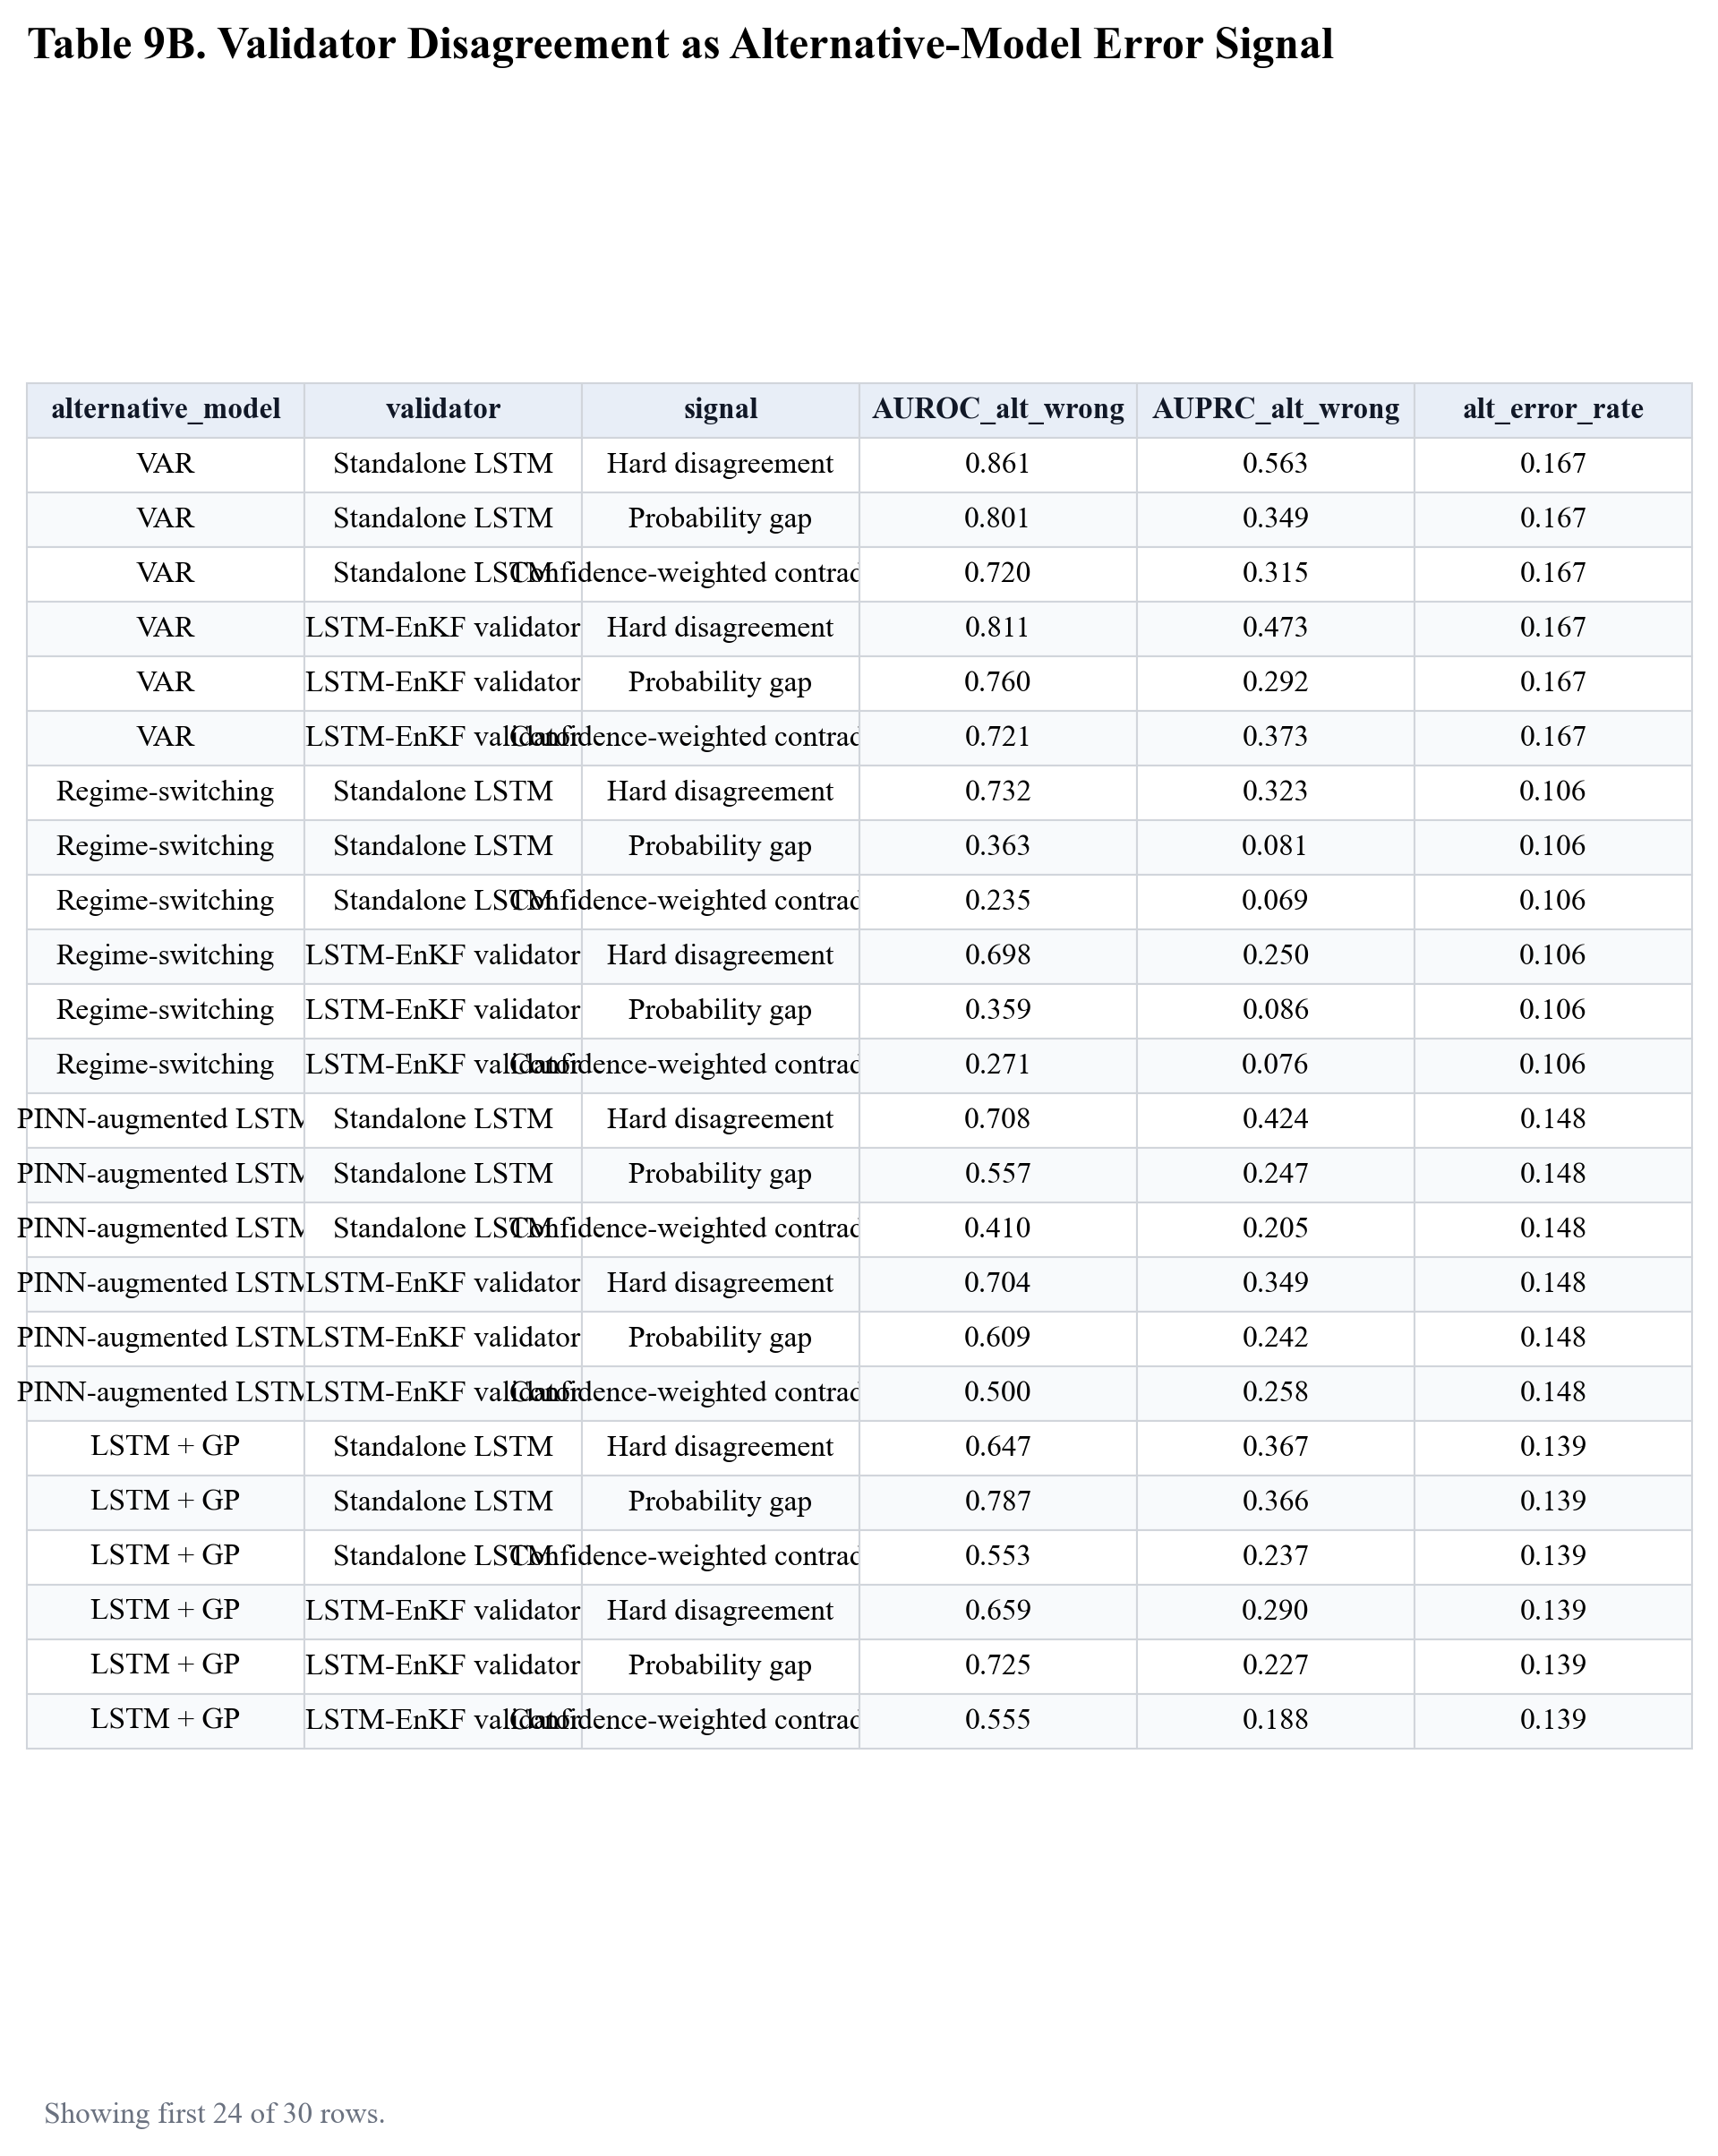

  saved output_refactored/validation_tools\Fig9B_validator_error_detection.png
  saved output_refactored/validation_tools\Fig9B_validator_error_detection.pdf


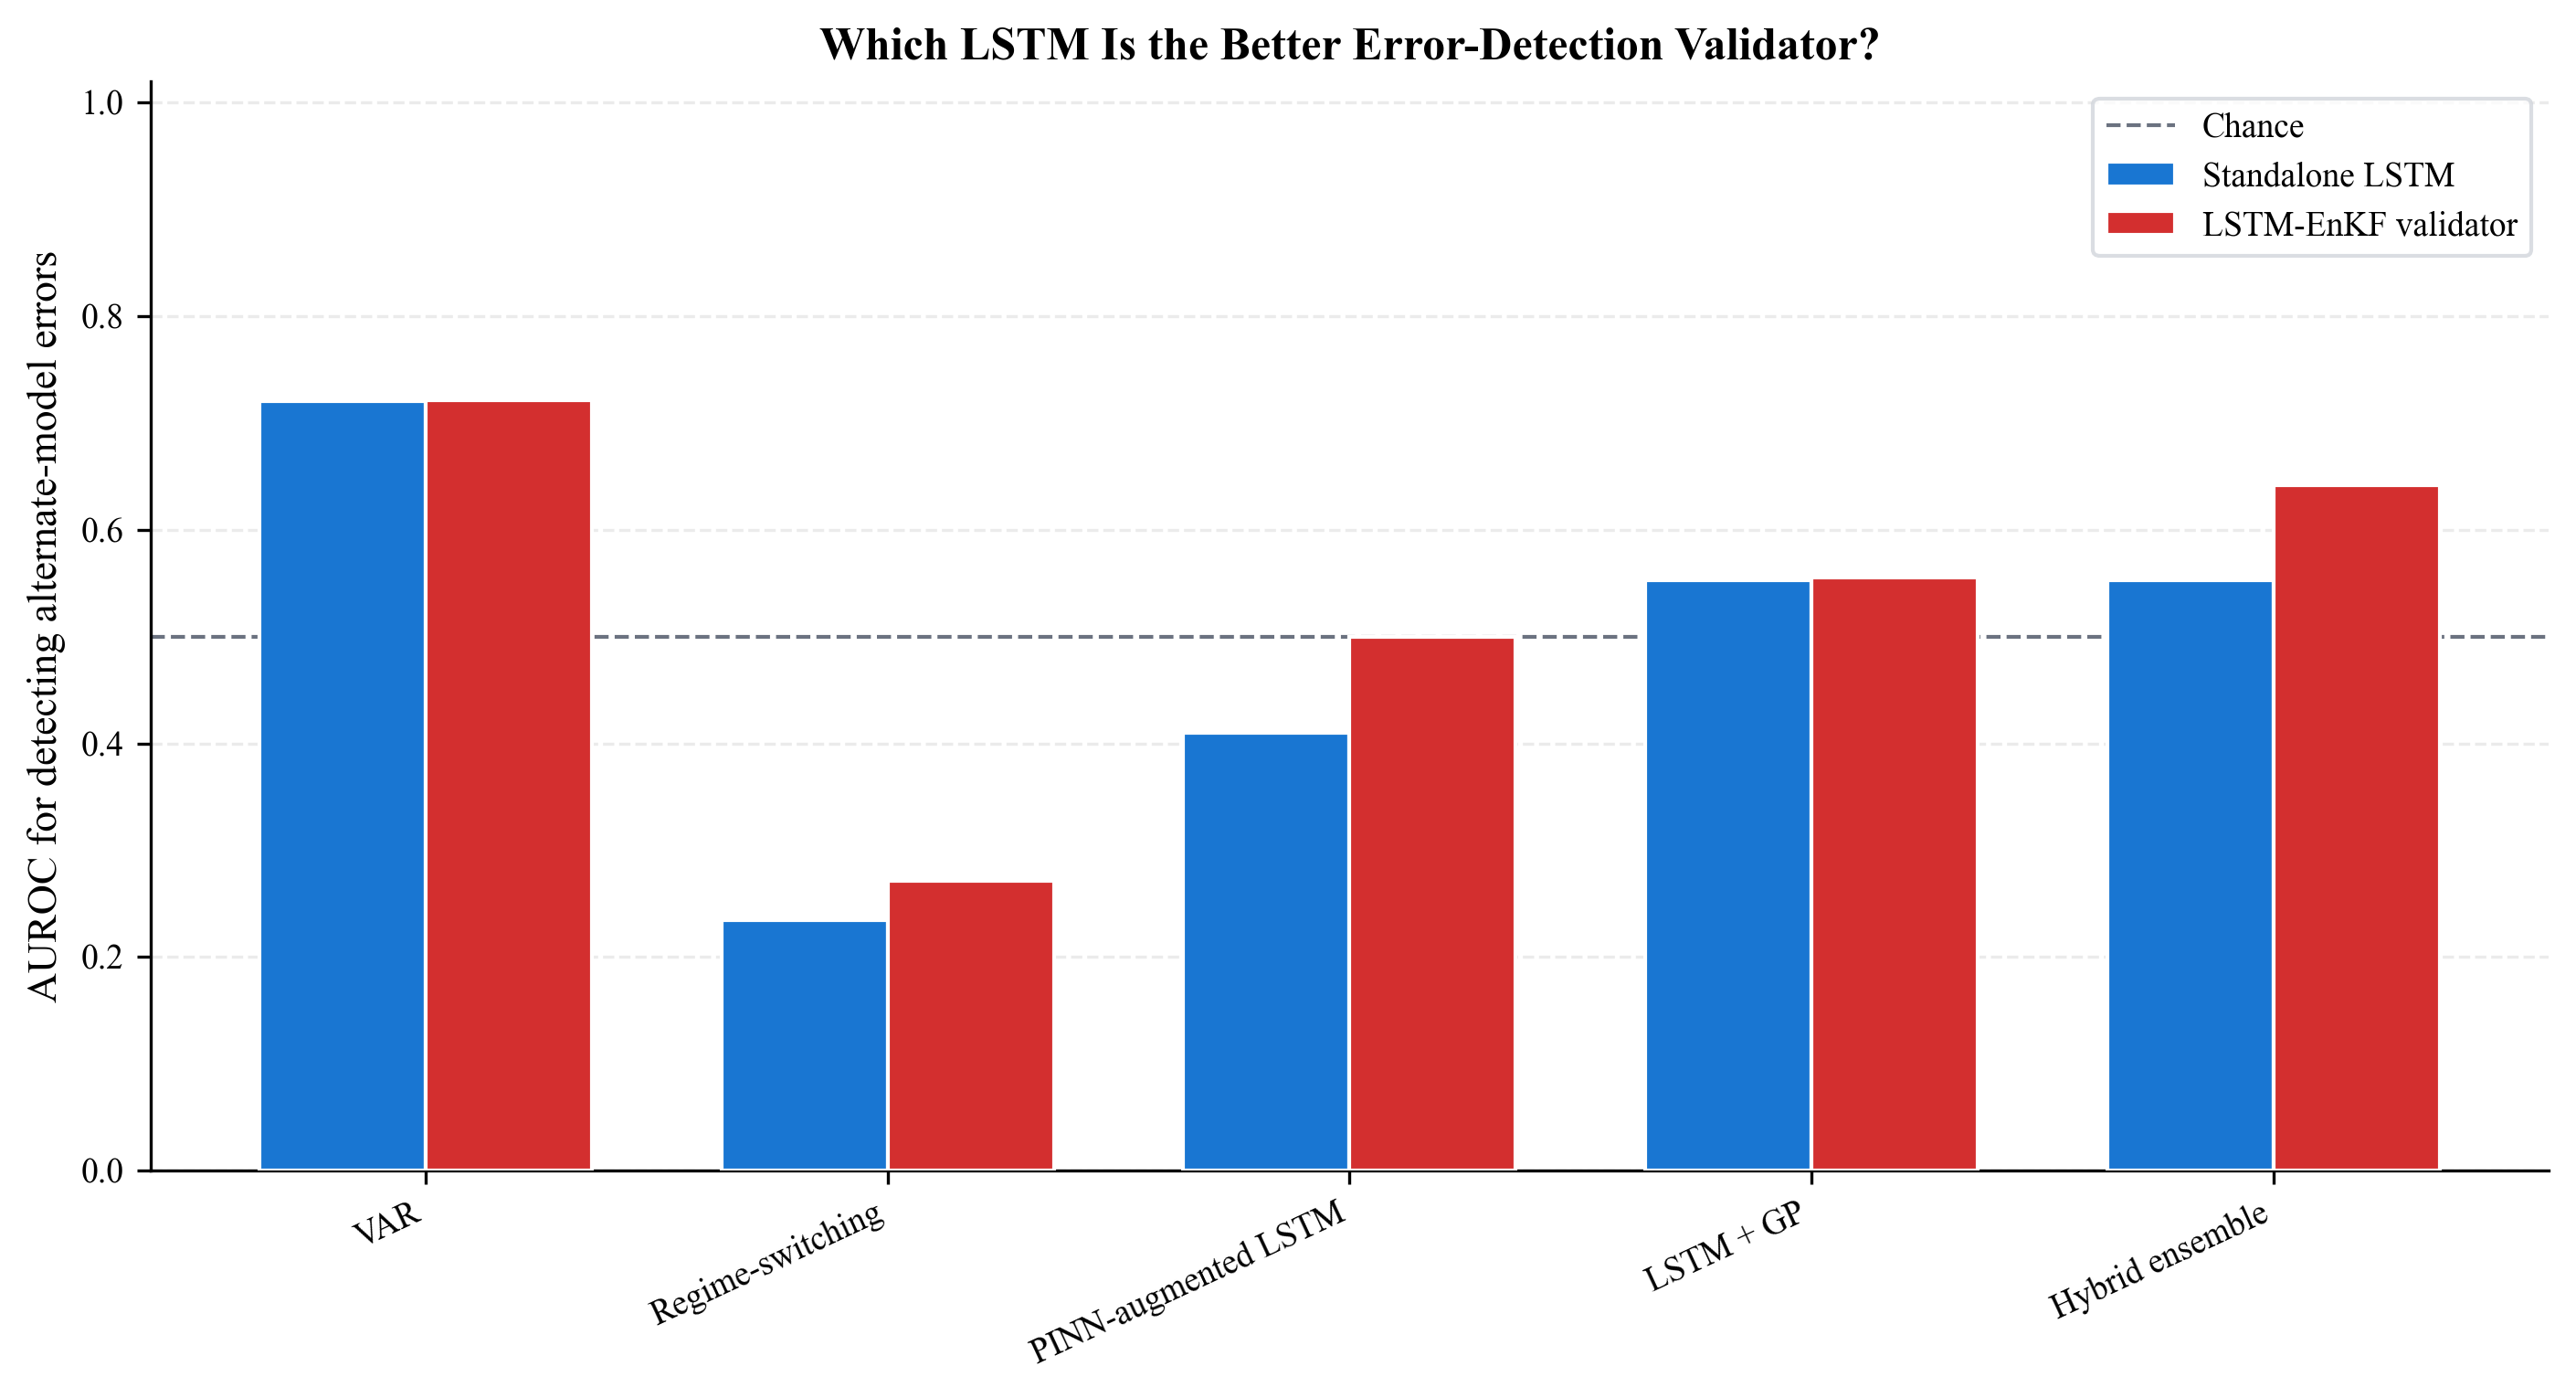

In [14]:
error_rows = []
for alt_key in alternate_keys:
    alt_name = alternate_names[alt_key]
    for validator_name, spec in validator_specs.items():
        y, alt_prob, val_prob = align_tail(y_test, streams[alt_key], streams[spec['key']])
        alt_pred = (alt_prob >= 0.5).astype(int)
        val_pred = (val_prob >= spec['threshold']).astype(int)
        alt_wrong = (alt_pred != y).astype(int)
        hard_disagree = (alt_pred != val_pred).astype(float)
        probability_gap = np.abs(alt_prob - val_prob)
        # Confidence-weighted contradiction using the symmetric helper so that
        # confident bloom calls and confident no-bloom calls saturate equally.
        contradiction = disagreement_signal(alt_prob, val_prob, spec['threshold'])

        error_rows.extend([
            {'alternative_model': alt_name, 'validator': validator_name, 'signal': 'Hard disagreement',
             'AUROC_alt_wrong': safe_auc(alt_wrong, hard_disagree), 'AUPRC_alt_wrong': safe_ap(alt_wrong, hard_disagree),
             'alt_error_rate': float(alt_wrong.mean())},
            {'alternative_model': alt_name, 'validator': validator_name, 'signal': 'Probability gap',
             'AUROC_alt_wrong': safe_auc(alt_wrong, probability_gap), 'AUPRC_alt_wrong': safe_ap(alt_wrong, probability_gap),
             'alt_error_rate': float(alt_wrong.mean())},
            {'alternative_model': alt_name, 'validator': validator_name, 'signal': 'Confidence-weighted contradiction',
             'AUROC_alt_wrong': safe_auc(alt_wrong, contradiction), 'AUPRC_alt_wrong': safe_ap(alt_wrong, contradiction),
             'alt_error_rate': float(alt_wrong.mean())},
        ])

error_df = pd.DataFrame(error_rows)
save_table(error_df, 'Table9_validator_error_detection.csv',
           'Table 9B. Validator Disagreement as Alternative-Model Error Signal')

plot_df = error_df[error_df['signal'] == 'Confidence-weighted contradiction'].copy()
fig, ax = plt.subplots(figsize=(9.5, 5.2))
models = plot_df['alternative_model'].unique().tolist()
x = np.arange(len(models))
width = 0.36
for i, validator_name in enumerate(validator_specs):
    sub = plot_df[plot_df['validator'] == validator_name].set_index('alternative_model').reindex(models)
    ax.bar(x + (i - 0.5) * width, sub['AUROC_alt_wrong'], width,
           label=validator_name, color=COLORS[validator_name], edgecolor='white', zorder=3)
ax.axhline(0.5, color=COLORS['gray'], linestyle='--', linewidth=1, label='Chance')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=25, ha='right')
ax.set_ylim(0, 1.02)
ax.set_ylabel('AUROC for detecting alternate-model errors')
ax.set_title('Which LSTM Is the Better Error-Detection Validator?', fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='--', zorder=0)
ax.legend(frameon=True, edgecolor='#D1D5DB')
plt.tight_layout()
savefig(fig, 'Fig9B_validator_error_detection')
plt.show()

## Cross-Validator Disagreement-Signal Correlation

If the two validators flag the same weeks as suspicious, the choice between them is cosmetic. If their disagreement signals are uncorrelated, they capture complementary failure modes and could be combined into a stronger triage tool. We compute Pearson and Spearman correlation of the confidence-weighted contradiction signal between the two validators per alternative model, plus the Jaccard index of their *hard* disagreement masks (validator-flagged weeks).


  saved table output_refactored/validation_tools\Table9_validator_signal_correlation.csv


,alternative_model,pearson_disagreement_signals,spearman_disagreement_signals,jaccard_hard_disagreement,n_weeks_flagged_standalone,n_weeks_flagged_enkf,n_weeks_flagged_both,n_weeks_flagged_either
0,VAR,0.757455,0.685136,0.760000,44,44,38,50
1,Regime-switching,0.744637,0.712183,0.612903,23,27,19,31
2,PINN-augmented LSTM,0.539308,0.398391,0.571429,18,26,16,28
3,LSTM + GP,0.186512,0.416083,0.428571,10,20,9,21
4,Hybrid ensemble,0.708452,0.478933,0.500000,14,22,12,24


  saved output_refactored/validation_tools\Table9_validator_signal_correlation.png
  saved output_refactored/validation_tools\Table9_validator_signal_correlation.pdf


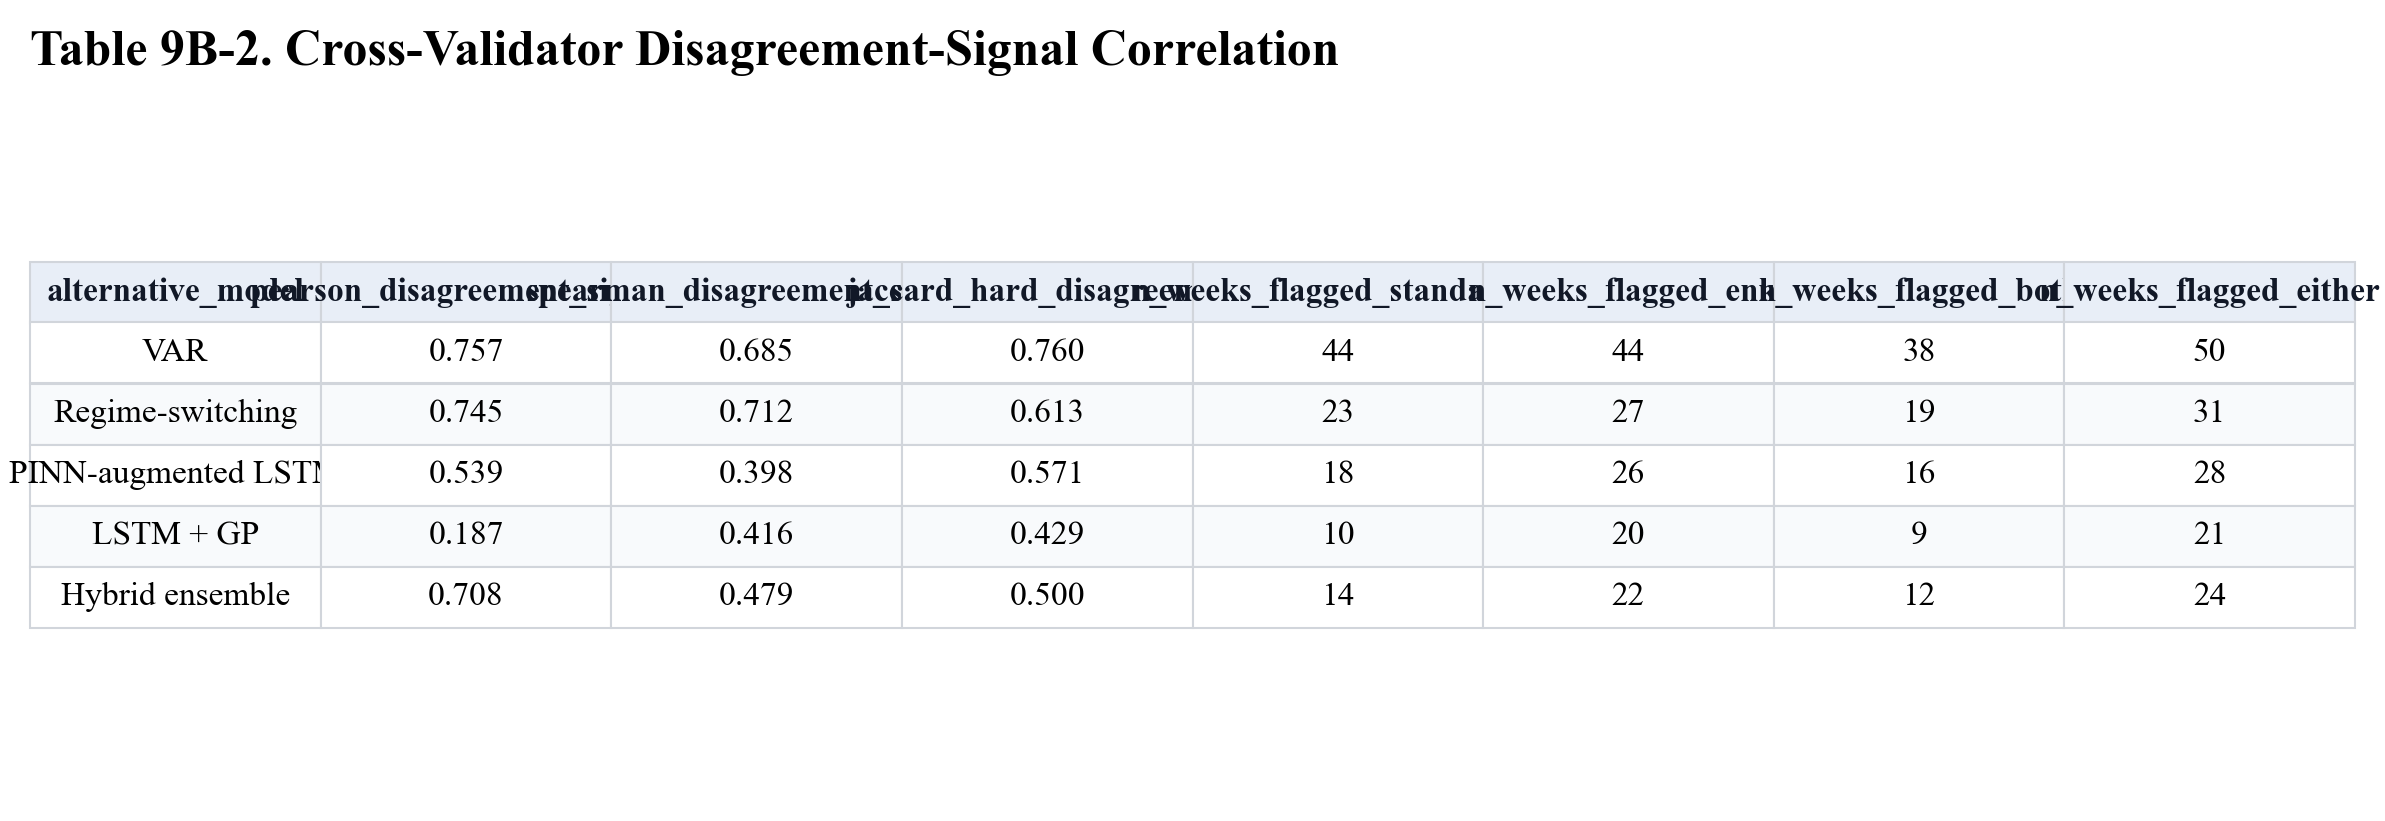

  saved output_refactored/validation_tools\Fig9H_validator_signal_scatter.png
  saved output_refactored/validation_tools\Fig9H_validator_signal_scatter.pdf


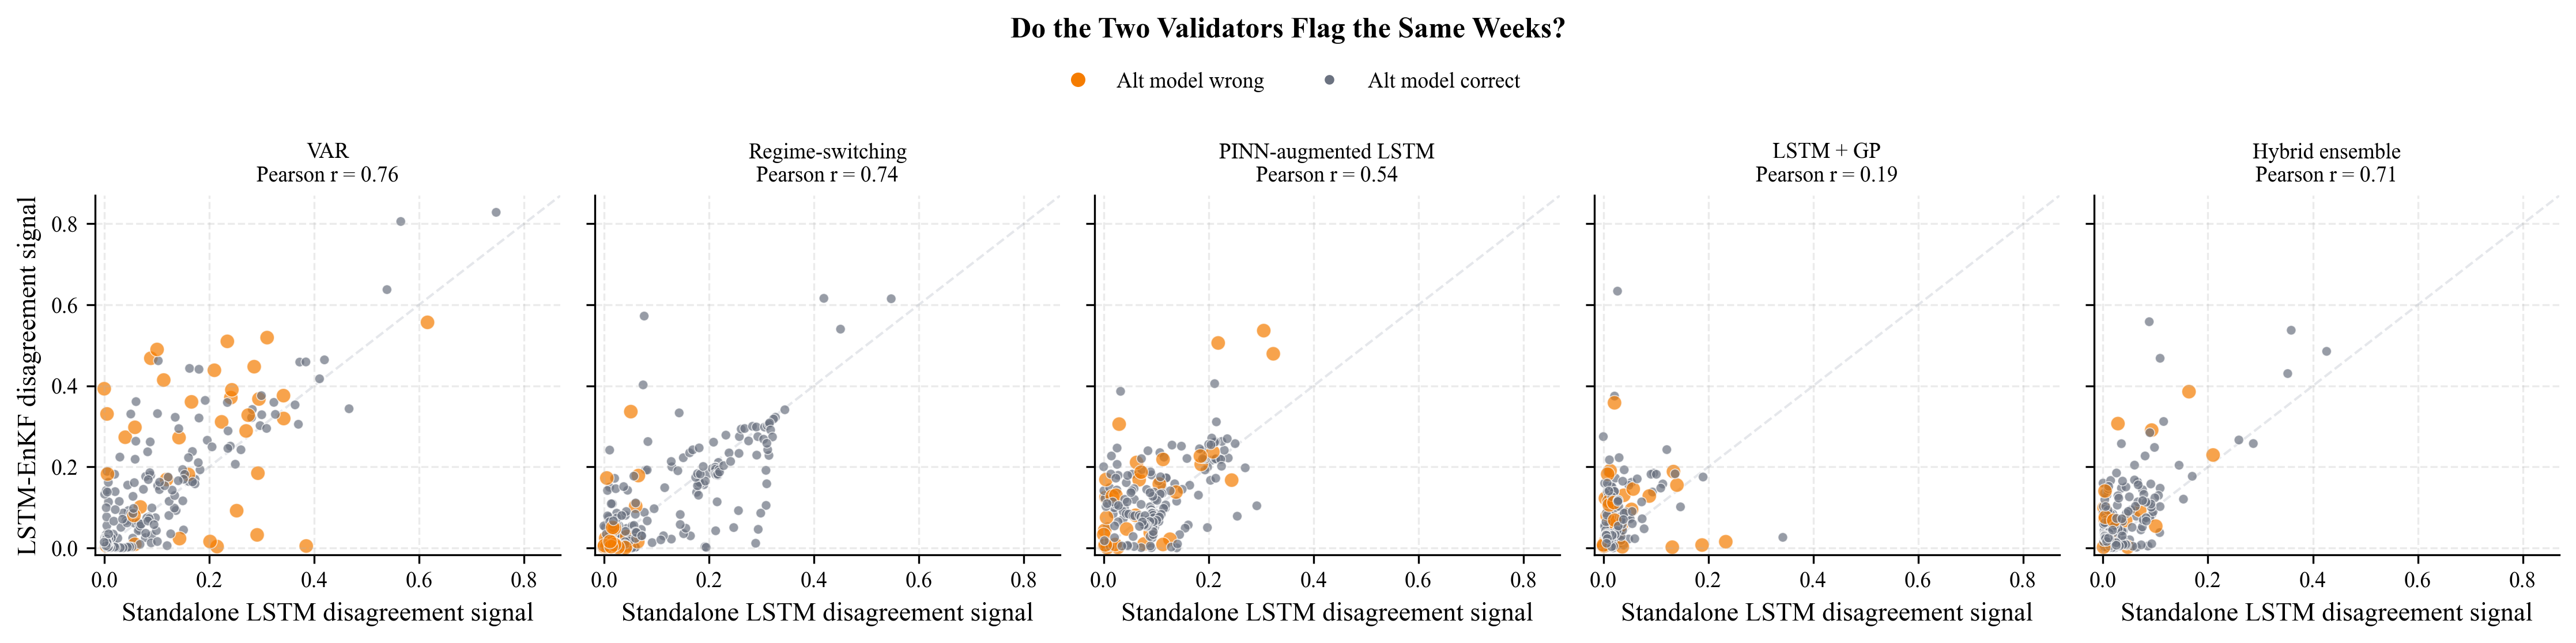


Interpretation: high correlation (r > 0.9) means the validators are redundant; lower correlation means they detect different failures and could be combined.


In [15]:
from scipy.stats import spearmanr

corr_rows = []
scatter_data = {}
standalone_spec = validator_specs['Standalone LSTM']
enkf_spec = validator_specs['LSTM-EnKF validator']

for alt_key in alternate_keys:
    alt_name = alternate_names[alt_key]
    y, alt_prob, p_std, p_enk = align_tail(
        y_test, streams[alt_key],
        streams[standalone_spec['key']], streams[enkf_spec['key']],
    )
    s_std = disagreement_signal(alt_prob, p_std, standalone_spec['threshold'])
    s_enk = disagreement_signal(alt_prob, p_enk, enkf_spec['threshold'])

    alt_pred = (alt_prob >= 0.5).astype(int)
    hard_std = (alt_pred != (p_std >= standalone_spec['threshold']).astype(int)).astype(int)
    hard_enk = (alt_pred != (p_enk >= enkf_spec['threshold']).astype(int)).astype(int)
    union = (hard_std | hard_enk).sum()
    inter = (hard_std & hard_enk).sum()
    jaccard = float(inter / union) if union > 0 else np.nan

    pearson = float(np.corrcoef(s_std, s_enk)[0, 1]) if np.std(s_std) > 0 and np.std(s_enk) > 0 else np.nan
    spearman = float(spearmanr(s_std, s_enk).statistic) if np.std(s_std) > 0 and np.std(s_enk) > 0 else np.nan

    corr_rows.append({
        'alternative_model': alt_name,
        'pearson_disagreement_signals': pearson,
        'spearman_disagreement_signals': spearman,
        'jaccard_hard_disagreement': jaccard,
        'n_weeks_flagged_standalone': int(hard_std.sum()),
        'n_weeks_flagged_enkf': int(hard_enk.sum()),
        'n_weeks_flagged_both': int(inter),
        'n_weeks_flagged_either': int(union),
    })
    scatter_data[alt_name] = (s_std, s_enk, alt_pred != y)

corr_df = pd.DataFrame(corr_rows)
save_table(corr_df, 'Table9_validator_signal_correlation.csv',
           'Table 9B-2. Cross-Validator Disagreement-Signal Correlation')

# Scatter plot per alt model
n = len(alternate_keys)
fig, axes = plt.subplots(1, n, figsize=(3.0 * n, 3.4), sharex=True, sharey=True)
if n == 1:
    axes = [axes]
lim = 0.0
for alt_key in alternate_keys:
    s_std, s_enk, _ = scatter_data[alternate_names[alt_key]]
    lim = max(lim, float(s_std.max()), float(s_enk.max()))
lim = max(lim * 1.05, 0.05)

for ax, alt_key in zip(axes, alternate_keys):
    alt_name = alternate_names[alt_key]
    s_std, s_enk, alt_wrong = scatter_data[alt_name]
    colors = np.where(alt_wrong, COLORS['flagged'], COLORS['gray'])
    sizes = np.where(alt_wrong, 36, 16)
    ax.scatter(s_std, s_enk, c=colors, s=sizes, alpha=0.7, edgecolor='white', linewidth=0.4)
    ax.plot([0, lim], [0, lim], '--', color=COLORS['light_gray'], lw=1, zorder=0)
    r = corr_df[corr_df['alternative_model'] == alt_name]['pearson_disagreement_signals'].iloc[0]
    ax.set_title(f'{alt_name}\nPearson r = {r:.2f}', fontsize=9)
    ax.set_xlim(-lim*0.02, lim)
    ax.set_ylim(-lim*0.02, lim)
    ax.grid(alpha=0.25, linestyle='--')

axes[0].set_ylabel('LSTM-EnKF disagreement signal')
for ax in axes:
    ax.set_xlabel('Standalone LSTM disagreement signal')

from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['flagged'], markersize=7, label='Alt model wrong'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['gray'], markersize=5, label='Alt model correct'),
]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)
fig.suptitle('Do the Two Validators Flag the Same Weeks?', fontweight='bold', y=1.08)
plt.tight_layout()
savefig(fig, 'Fig9H_validator_signal_scatter')
plt.show()

print('\nInterpretation: high correlation (r > 0.9) means the validators are redundant; lower correlation means they detect different failures and could be combined.')


## Incremental Validator Information Beyond the Alternative's Own Uncertainty

A validator is only operationally useful if it tells us something `|alt_prob − 0.5|` does not already say. For each (alt model, validator) pair we fit two nested logistic regressions of `alt_wrong` on (a) the alternative's own uncertainty alone and (b) the alternative's uncertainty plus the validator's disagreement signal. A likelihood-ratio test on the added validator term measures whether the validator contributes information beyond what the alternative model already knows about itself.


  saved table output_refactored/validation_tools\Table9_incremental_validator_information.csv


,alternative_model,validator,LL_alt_uncertainty_only,LL_with_validator,LR_chi2,p_LR_test,n_errors,beta_validator,note,p_holm,holm_significant_0.05
0,VAR,Standalone LSTM,-77.286436,-76.867084,0.838704,0.359768,36,0.924358,,1.000000,False
1,VAR,LSTM-EnKF validator,-77.286436,-76.018590,2.535692,0.111298,36,1.325466,,0.890384,False
2,Regime-switching,Standalone LSTM,-71.563079,-67.949478,7.227203,0.007181,23,-1.758879,,0.071807,False
3,Regime-switching,LSTM-EnKF validator,-71.563079,-69.368351,4.389457,0.036162,23,-1.352028,,0.325456,False
4,PINN-augmented LSTM,Standalone LSTM,-81.041974,-80.950206,0.183537,0.668351,32,-0.301550,,1.000000,False
5,PINN-augmented LSTM,LSTM-EnKF validator,-81.041974,-80.932023,0.219902,0.639114,32,0.398966,,1.000000,False
6,LSTM + GP,Standalone LSTM,-75.620481,-75.482644,0.275674,0.599551,30,0.404821,,1.000000,False
7,LSTM + GP,LSTM-EnKF validator,-75.620481,-75.601869,0.037224,0.847011,30,0.249888,,1.000000,False
8,Hybrid ensemble,Standalone LSTM,-53.968295,-53.969385,0.000000,1.000000,16,0.116334,,1.000000,False
9,Hybrid ensemble,LSTM-EnKF validator,-53.968295,-53.769447,0.397695,0.528282,16,0.520945,,1.000000,False


  saved output_refactored/validation_tools\Table9_incremental_validator_information.png
  saved output_refactored/validation_tools\Table9_incremental_validator_information.pdf


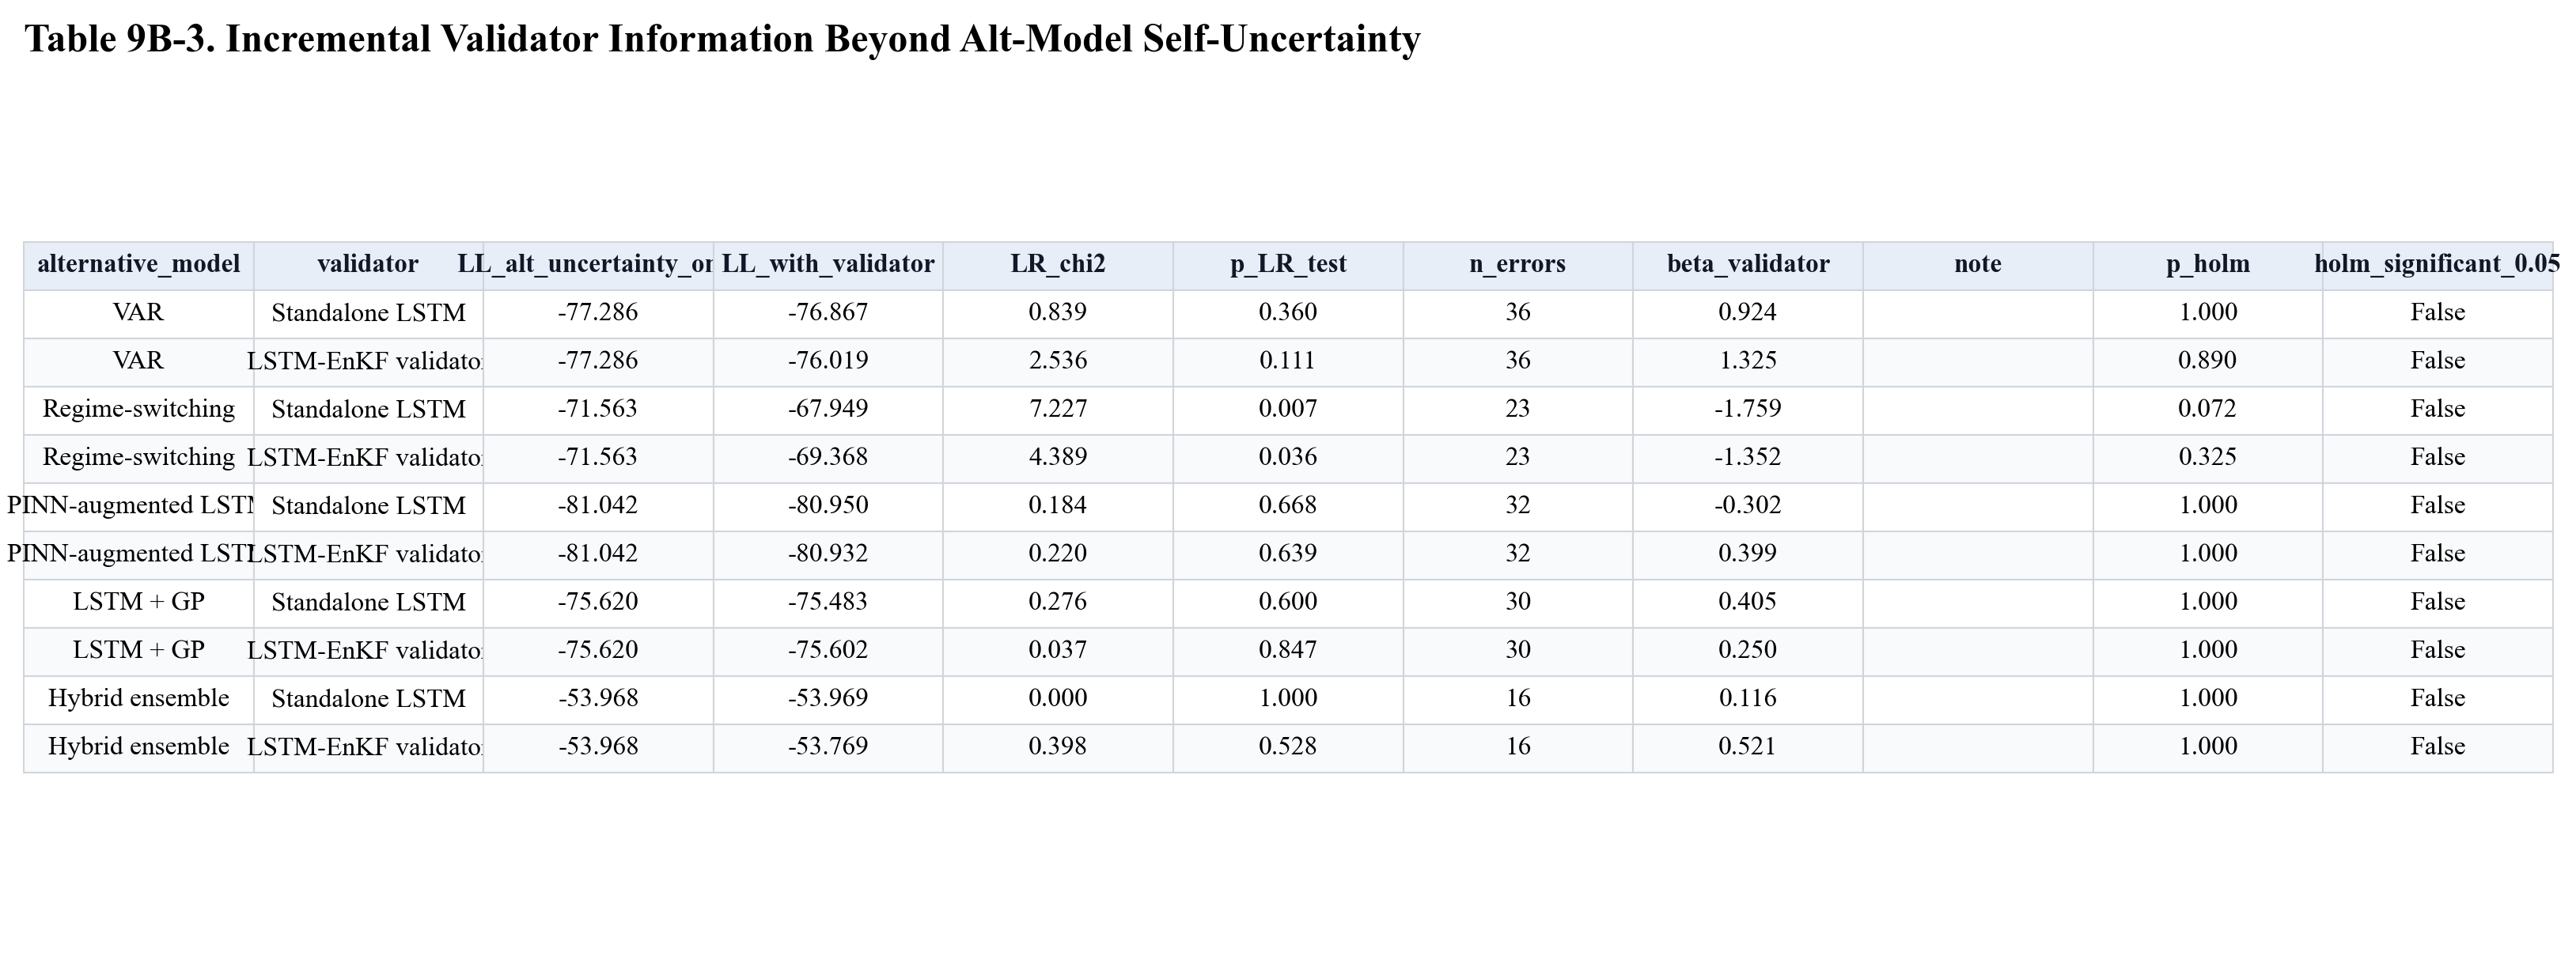

  saved output_refactored/validation_tools\Fig9I_incremental_validator_information.png
  saved output_refactored/validation_tools\Fig9I_incremental_validator_information.pdf


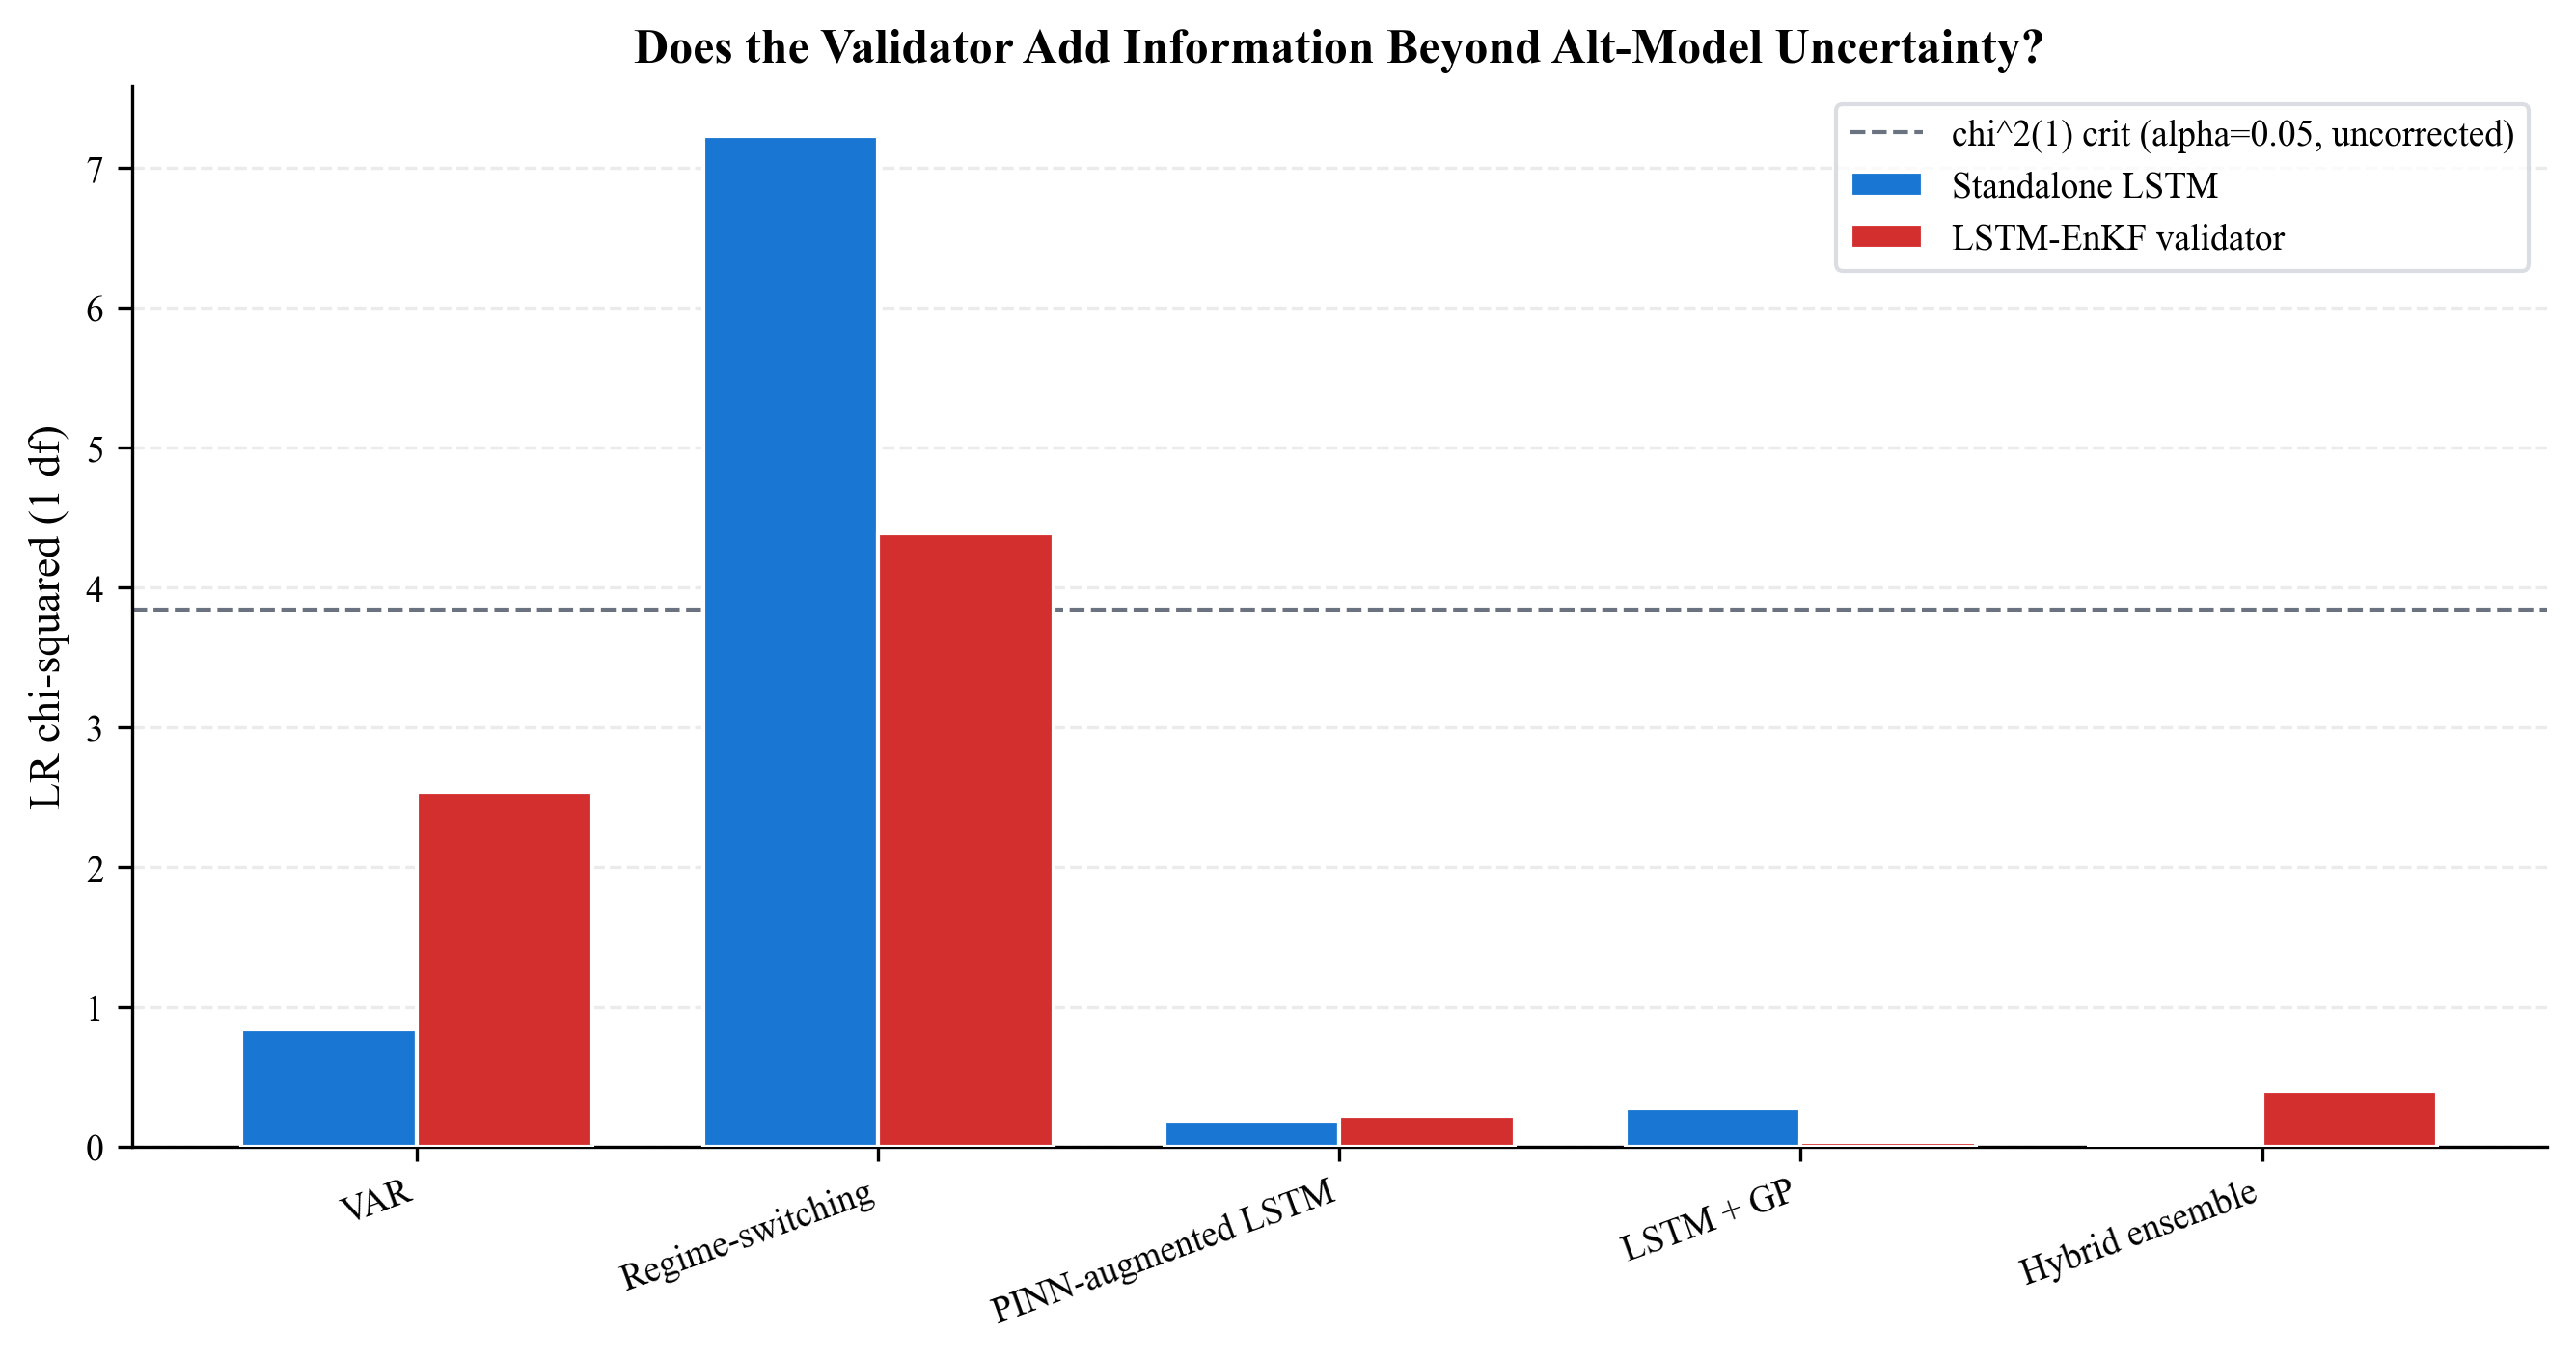


A significant LR test (asterisk above bar) means the validator carries information beyond the alternative model already knowing it is uncertain. Holm correction is applied across all (alt-model x validator) tests in this table.


In [16]:
from sklearn.linear_model import LogisticRegression
from scipy.stats import chi2 as _chi2

def _log_likelihood(model, X, y):
    p = np.clip(model.predict_proba(X)[:, 1], 1e-9, 1 - 1e-9)
    return float((y * np.log(p) + (1 - y) * np.log(1 - p)).sum())

incremental_rows = []
for alt_key in alternate_keys:
    alt_name = alternate_names[alt_key]
    for validator_name, spec in validator_specs.items():
        y, alt_prob, val_prob = align_tail(y_test, streams[alt_key], streams[spec['key']])
        alt_pred = (alt_prob >= 0.5).astype(int)
        alt_wrong = (alt_pred != y).astype(int)

        # Skip pairs with too few errors / non-errors for a stable fit.
        if alt_wrong.sum() < 5 or (alt_wrong == 0).sum() < 5:
            incremental_rows.append({
                'alternative_model': alt_name, 'validator': validator_name,
                'LL_alt_uncertainty_only': np.nan, 'LL_with_validator': np.nan,
                'LR_chi2': np.nan, 'p_LR_test': np.nan, 'n_errors': int(alt_wrong.sum()),
                'beta_validator': np.nan, 'note': 'too few errors',
            })
            continue

        # Alt uncertainty: distance from 0.5, sign-flipped so larger = more uncertain.
        alt_unc = -np.abs(alt_prob - 0.5)
        contradiction = disagreement_signal(alt_prob, val_prob, spec['threshold'])

        X1 = alt_unc.reshape(-1, 1)
        X2 = np.column_stack([alt_unc, contradiction])
        m1 = LogisticRegression(max_iter=1000, solver='lbfgs').fit(X1, alt_wrong)
        m2 = LogisticRegression(max_iter=1000, solver='lbfgs').fit(X2, alt_wrong)
        ll1 = _log_likelihood(m1, X1, alt_wrong)
        ll2 = _log_likelihood(m2, X2, alt_wrong)
        lr_stat = max(2.0 * (ll2 - ll1), 0.0)
        p_lr = float(1.0 - _chi2.cdf(lr_stat, df=1))

        incremental_rows.append({
            'alternative_model': alt_name,
            'validator': validator_name,
            'LL_alt_uncertainty_only': ll1,
            'LL_with_validator': ll2,
            'LR_chi2': float(lr_stat),
            'p_LR_test': p_lr,
            'n_errors': int(alt_wrong.sum()),
            'beta_validator': float(m2.coef_[0, 1]),
            'note': '',
        })

incremental_df = pd.DataFrame(incremental_rows)
incremental_df['p_holm'] = holm_adjust(incremental_df['p_LR_test'].values)
incremental_df['holm_significant_0.05'] = incremental_df['p_holm'] < 0.05
save_table(incremental_df, 'Table9_incremental_validator_information.csv',
           'Table 9B-3. Incremental Validator Information Beyond Alt-Model Self-Uncertainty')

# Visualize the LR chi^2 statistic per (alt, validator)
fig, ax = plt.subplots(figsize=(9, 4.8))
models = list(alternate_names.values())
x = np.arange(len(models))
width = 0.38
for i, validator_name in enumerate(validator_specs):
    sub = incremental_df[incremental_df['validator'] == validator_name].set_index('alternative_model').reindex(models)
    bars = ax.bar(x + (i - 0.5) * width, sub['LR_chi2'].fillna(0).values, width,
                  label=validator_name, color=COLORS[validator_name], edgecolor='white', zorder=3)
    for bar, sig in zip(bars, sub['holm_significant_0.05'].fillna(False).values):
        if sig:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                    '*', ha='center', va='bottom', fontsize=14, color=COLORS['dark'])
# Reference line at chi^2 critical value for alpha=0.05, df=1
ax.axhline(3.84, color=COLORS['gray'], linestyle='--', linewidth=1, label='chi^2(1) crit (alpha=0.05, uncorrected)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylabel('LR chi-squared (1 df)')
ax.set_title('Does the Validator Add Information Beyond Alt-Model Uncertainty?', fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='--', zorder=0)
ax.legend(frameon=True, edgecolor='#D1D5DB', loc='upper right')
plt.tight_layout()
savefig(fig, 'Fig9I_incremental_validator_information')
plt.show()

print('\nA significant LR test (asterisk above bar) means the validator carries information beyond the alternative model already knowing it is uncertain. Holm correction is applied across all (alt-model x validator) tests in this table.')


## Agreement-Gated Acceptance

  saved table output_refactored/validation_tools\Table9_agreement_gated_acceptance.csv


,alternative_model,validator,agreement_coverage,flagged_fraction,accepted_alt_accuracy,flagged_alt_accuracy,accepted_positive_precision,flag_precision_alt_wrong,alt_error_capture_by_flags,alt_false_alarm_capture,alt_missed_event_capture,n_alt_false_positives,n_alt_false_negatives,overall_alt_accuracy,accepted_accuracy_lift
0,VAR,Standalone LSTM,0.796296,0.203704,0.959302,0.340909,0.947368,0.659091,0.805556,NaN,0.852941,2,34,0.833333,0.125969
1,VAR,LSTM-EnKF validator,0.796296,0.203704,0.941860,0.409091,0.947368,0.590909,0.722222,NaN,0.764706,2,34,0.833333,0.108527
2,Regime-switching,Standalone LSTM,0.893519,0.106481,0.943005,0.478261,0.864865,0.521739,0.521739,0.523810,NaN,21,2,0.893519,0.049487
3,Regime-switching,LSTM-EnKF validator,0.875000,0.125000,0.936508,0.592593,0.847222,0.407407,0.478261,0.476190,NaN,21,2,0.893519,0.042989
4,PINN-augmented LSTM,Standalone LSTM,0.916667,0.083333,0.909091,0.222222,0.810127,0.777778,0.437500,0.464286,NaN,28,4,0.851852,0.057239
5,PINN-augmented LSTM,LSTM-EnKF validator,0.879630,0.120370,0.910526,0.423077,0.800000,0.576923,0.468750,0.464286,NaN,28,4,0.851852,0.058674
6,LSTM + GP,Standalone LSTM,0.953704,0.046296,0.898058,0.100000,0.802469,0.900000,0.300000,0.360000,0.000000,25,5,0.861111,0.036947
7,LSTM + GP,LSTM-EnKF validator,0.907407,0.092593,0.903061,0.450000,0.789474,0.550000,0.366667,0.360000,0.400000,25,5,0.861111,0.041950
8,Hybrid ensemble,Standalone LSTM,0.935185,0.064815,0.940594,0.714286,0.900000,0.285714,0.250000,0.222222,0.285714,9,7,0.925926,0.014668
9,Hybrid ensemble,LSTM-EnKF validator,0.898148,0.101852,0.943299,0.772727,0.878788,0.227273,0.312500,0.111111,0.571429,9,7,0.925926,0.017373


  saved output_refactored/validation_tools\Table9_agreement_gated_acceptance.png
  saved output_refactored/validation_tools\Table9_agreement_gated_acceptance.pdf


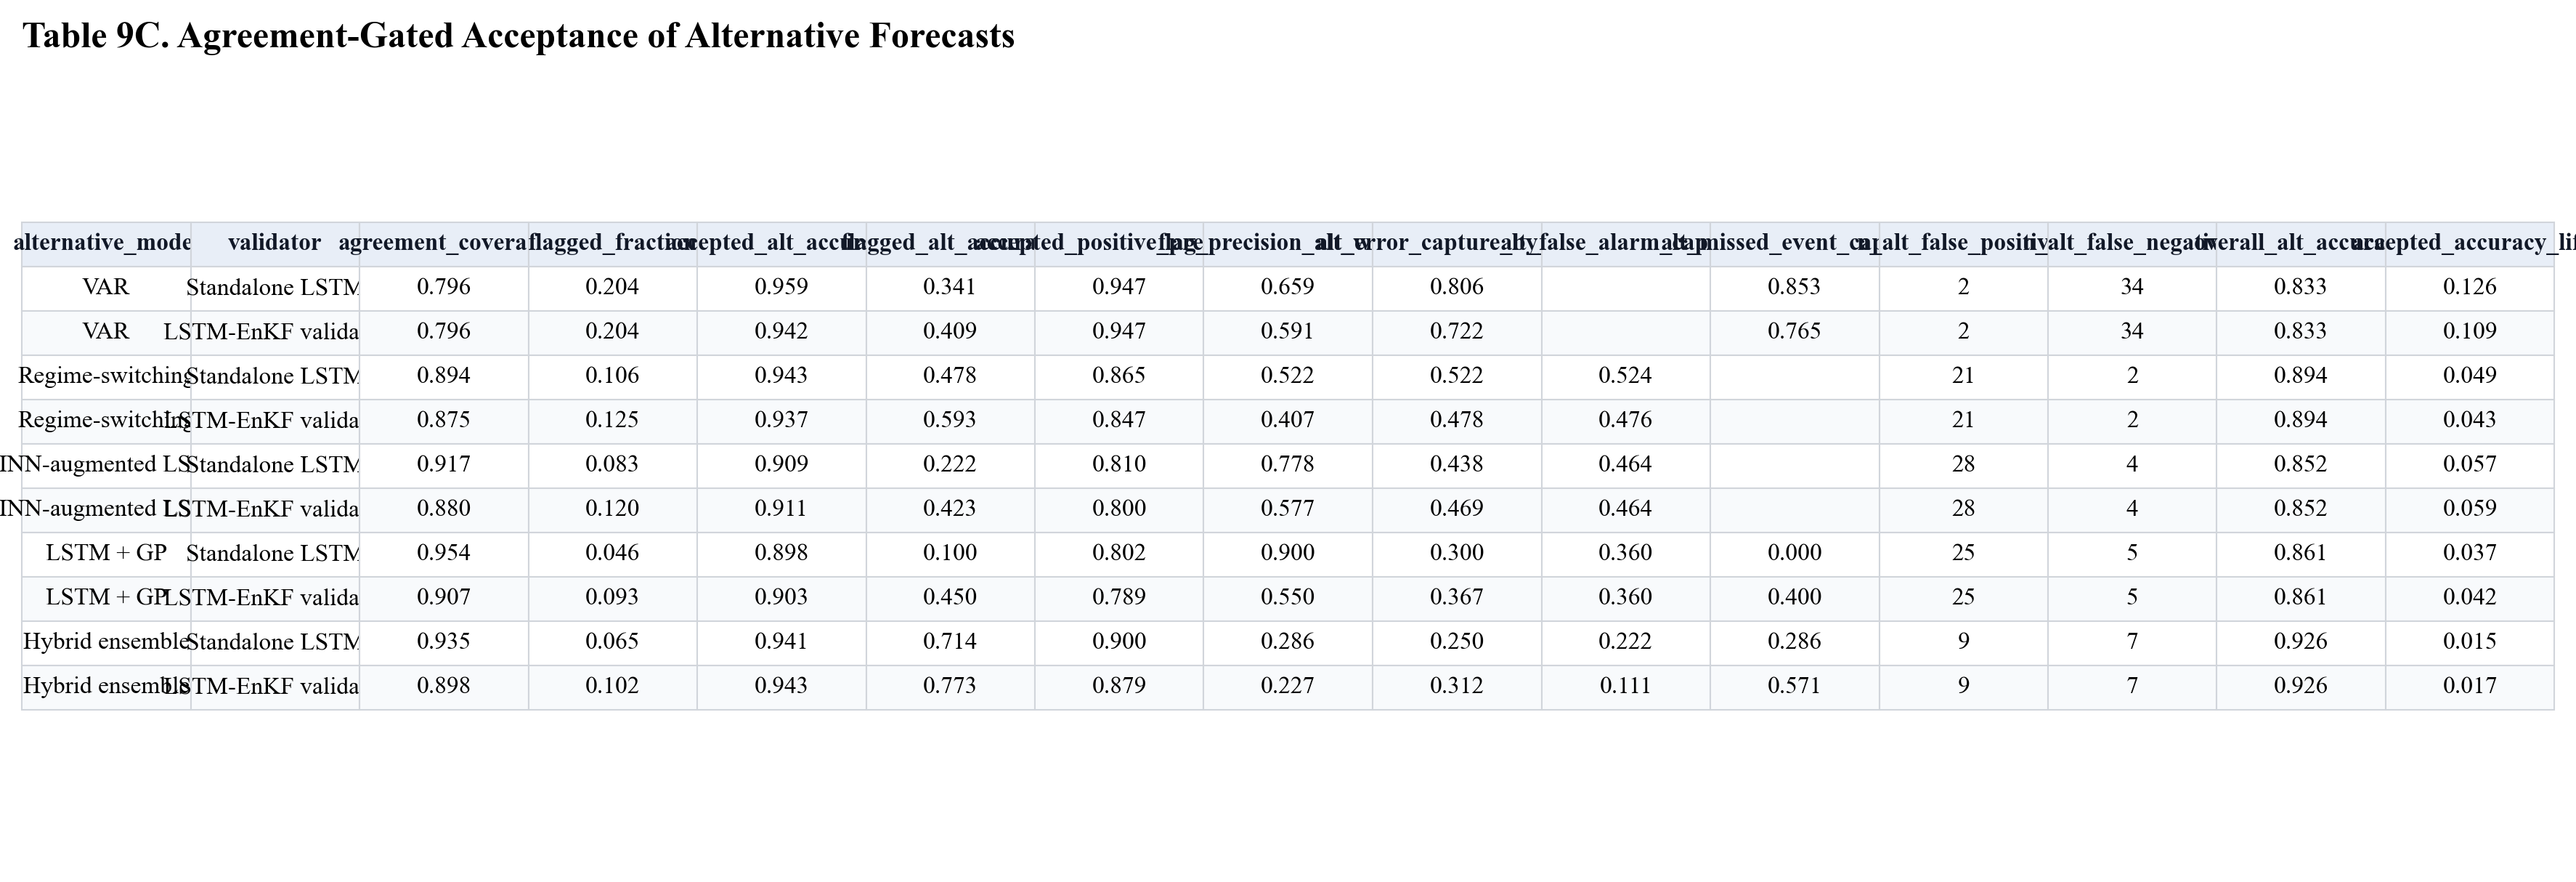

  saved output_refactored/validation_tools\Fig9C_agreement_gated_acceptance.png
  saved output_refactored/validation_tools\Fig9C_agreement_gated_acceptance.pdf


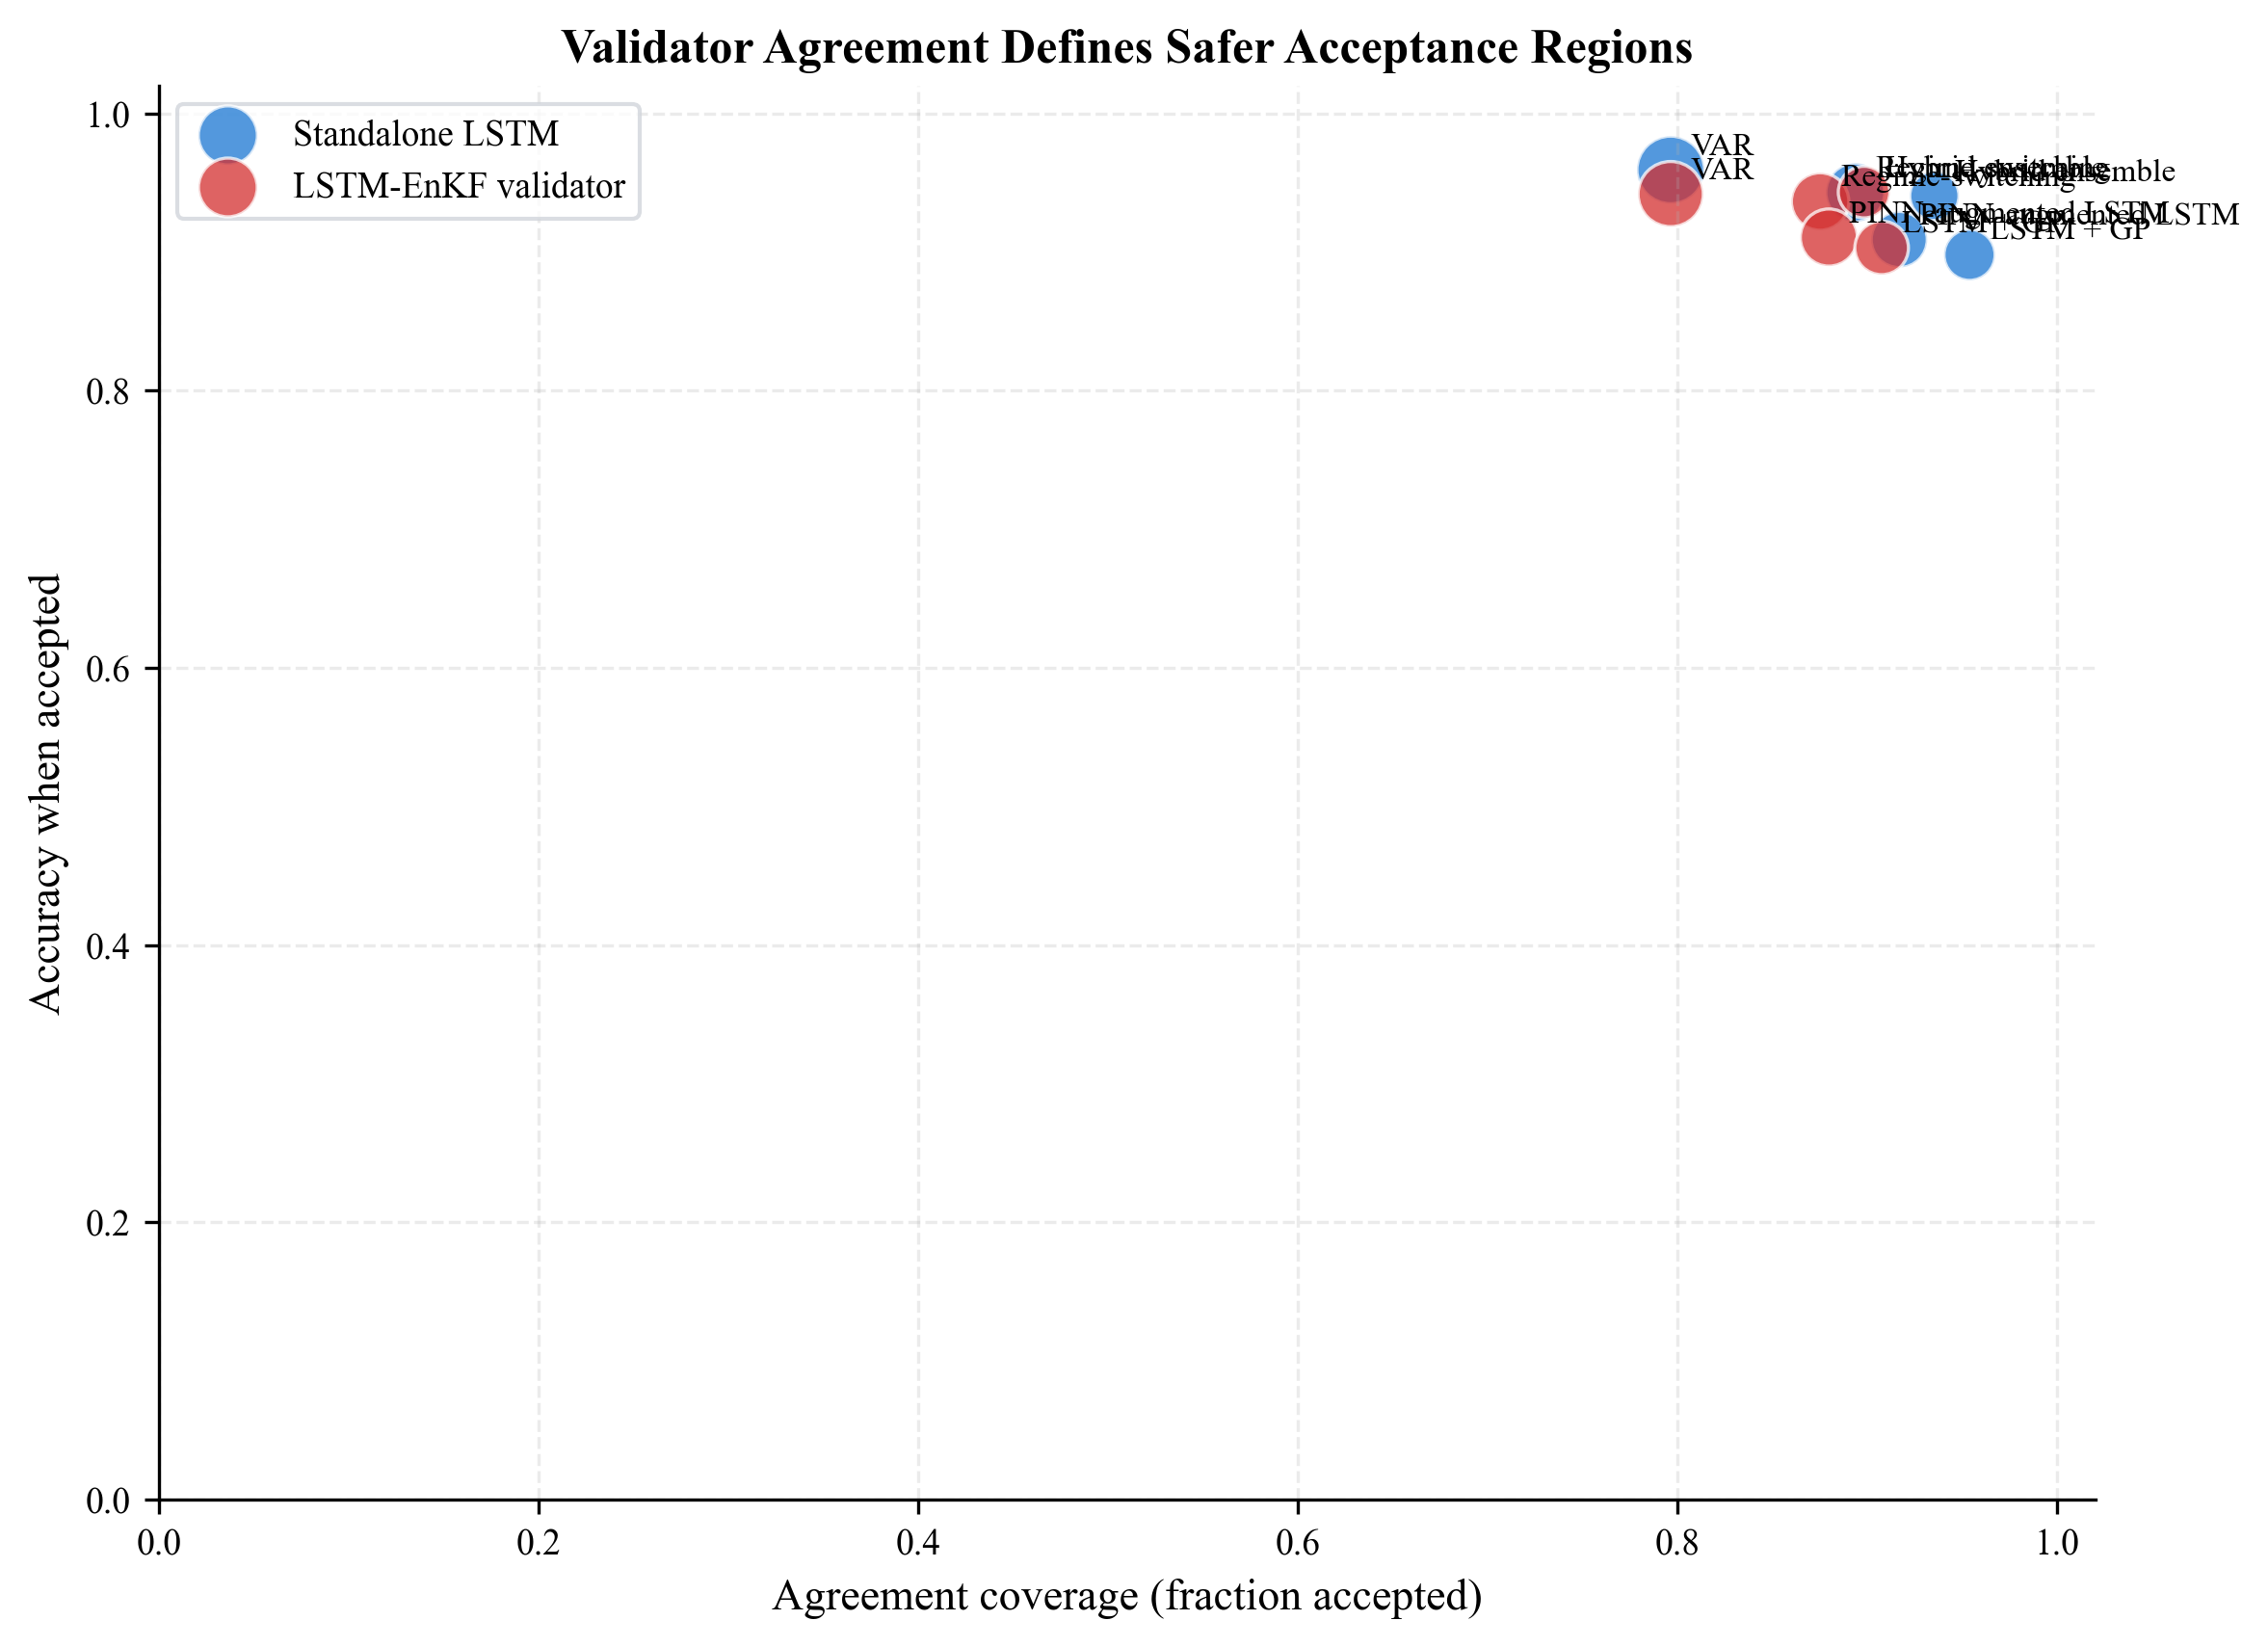

In [17]:
gate_rows = []
for alt_key in alternate_keys:
    alt_name = alternate_names[alt_key]
    for validator_name, spec in validator_specs.items():
        y, alt_prob, val_prob = align_tail(y_test, streams[alt_key], streams[spec['key']])
        alt_pred = (alt_prob >= 0.5).astype(int)
        val_pred = (val_prob >= spec['threshold']).astype(int)
        agree = alt_pred == val_pred
        disagree = ~agree
        alt_wrong = alt_pred != y
        alt_pos = alt_pred == 1
        alt_neg = alt_pred == 0
        alt_fp = alt_pos & (y == 0)
        alt_fn = alt_neg & (y == 1)
        disputed_positive = alt_pos & (val_pred == 0)
        disputed_negative = alt_neg & (val_pred == 1)

        accepted_acc = accuracy_score(y[agree], alt_pred[agree]) if agree.any() else np.nan
        rejected_acc = accuracy_score(y[disagree], alt_pred[disagree]) if disagree.any() else np.nan
        flag_precision = float((alt_wrong & disagree).sum() / max(disagree.sum(), 1))
        error_capture = float((alt_wrong & disagree).sum() / max(alt_wrong.sum(), 1))
        # Two operationally distinct failure modes captured by validator disagreement.
        # Guard with a minimum event count: ratios with <10 events in the denominator
        # have meaningless bootstrap distributions (see Table 9A row counts for VAR).
        FA_MIN_EVENTS = 5  # minimum events required to report capture rate
        if alt_fp.sum() >= FA_MIN_EVENTS:
            false_alarm_capture = float((alt_fp & disputed_positive).sum() / alt_fp.sum())
        else:
            false_alarm_capture = np.nan
        if alt_fn.sum() >= FA_MIN_EVENTS:
            missed_event_capture = float((alt_fn & disputed_negative).sum() / alt_fn.sum())
        else:
            missed_event_capture = np.nan
        accepted_positive_precision = precision_score(y[agree], alt_pred[agree], zero_division=0) if agree.any() else np.nan

        gate_rows.append({
            'alternative_model': alt_name,
            'validator': validator_name,
            'agreement_coverage': float(agree.mean()),
            'flagged_fraction': float(disagree.mean()),
            'accepted_alt_accuracy': float(accepted_acc),
            'flagged_alt_accuracy': float(rejected_acc),
            'accepted_positive_precision': float(accepted_positive_precision),
            'flag_precision_alt_wrong': flag_precision,
            'alt_error_capture_by_flags': error_capture,
            'alt_false_alarm_capture': false_alarm_capture,
            'alt_missed_event_capture': missed_event_capture,
            'n_alt_false_positives': int(alt_fp.sum()),
            'n_alt_false_negatives': int(alt_fn.sum()),
            'overall_alt_accuracy': float(accuracy_score(y, alt_pred)),
        })

gate_df = pd.DataFrame(gate_rows)
gate_df['accepted_accuracy_lift'] = gate_df['accepted_alt_accuracy'] - gate_df['overall_alt_accuracy']
save_table(gate_df, 'Table9_agreement_gated_acceptance.csv',
           'Table 9C. Agreement-Gated Acceptance of Alternative Forecasts')

fig, ax = plt.subplots(figsize=(8, 5.8))
for validator_name in validator_specs:
    sub = gate_df[gate_df['validator'] == validator_name]
    ax.scatter(sub['agreement_coverage'], sub['accepted_alt_accuracy'],
               s=90 + 240 * sub['alt_error_capture_by_flags'],
               color=COLORS[validator_name], alpha=0.75, edgecolor='white', linewidth=0.8,
               label=validator_name)
    for _, row in sub.iterrows():
        ax.annotate(row['alternative_model'],
                    (row['agreement_coverage'], row['accepted_alt_accuracy']),
                    xytext=(5, 4), textcoords='offset points', fontsize=8)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.set_xlabel('Agreement coverage (fraction accepted)')
ax.set_ylabel('Accuracy when accepted')
ax.set_title('Validator Agreement Defines Safer Acceptance Regions', fontweight='bold')
ax.grid(alpha=0.25, linestyle='--')
ax.legend(frameon=True, edgecolor='#D1D5DB')
plt.tight_layout()
savefig(fig, 'Fig9C_agreement_gated_acceptance')
plt.show()

## Disagreement-Direction Breakdown

Aggregate disagreement as a single Boolean hides operationally relevant structure. We split the "disagree" cell into the two directions — *validator says no-bloom when the alternative model says bloom* (a credibility-protection signal) and *validator says bloom when the alternative model says no-bloom* (a safety-protection signal) — and report the alt-model error rate within each cell. A validator whose `disputed_positive_alt_wrong_rate` is high is a sharp false-alarm filter; one whose `disputed_negative_alt_wrong_rate` is high is a sharp missed-event detector.


  saved table output_refactored/validation_tools\Table9_disagreement_direction.csv


,alternative_model,validator,n_disputed_positive,disputed_positive_alt_wrong_rate,n_disputed_negative,disputed_negative_alt_wrong_rate,alt_overall_error_rate
0,VAR,Standalone LSTM,0,NaN,44,0.659091,0.166667
1,VAR,LSTM-EnKF validator,0,NaN,44,0.590909,0.166667
2,Regime-switching,Standalone LSTM,15,0.733333,8,0.125000,0.106481
3,Regime-switching,LSTM-EnKF validator,17,0.588235,10,0.100000,0.106481
4,PINN-augmented LSTM,Standalone LSTM,15,0.866667,3,0.333333,0.148148
5,PINN-augmented LSTM,LSTM-EnKF validator,19,0.684211,7,0.285714,0.148148
6,LSTM + GP,Standalone LSTM,9,1.000000,1,0.000000,0.138889
7,LSTM + GP,LSTM-EnKF validator,14,0.642857,6,0.333333,0.138889
8,Hybrid ensemble,Standalone LSTM,2,1.000000,12,0.166667,0.074074
9,Hybrid ensemble,LSTM-EnKF validator,6,0.166667,16,0.250000,0.074074


  saved output_refactored/validation_tools\Table9_disagreement_direction.png
  saved output_refactored/validation_tools\Table9_disagreement_direction.pdf


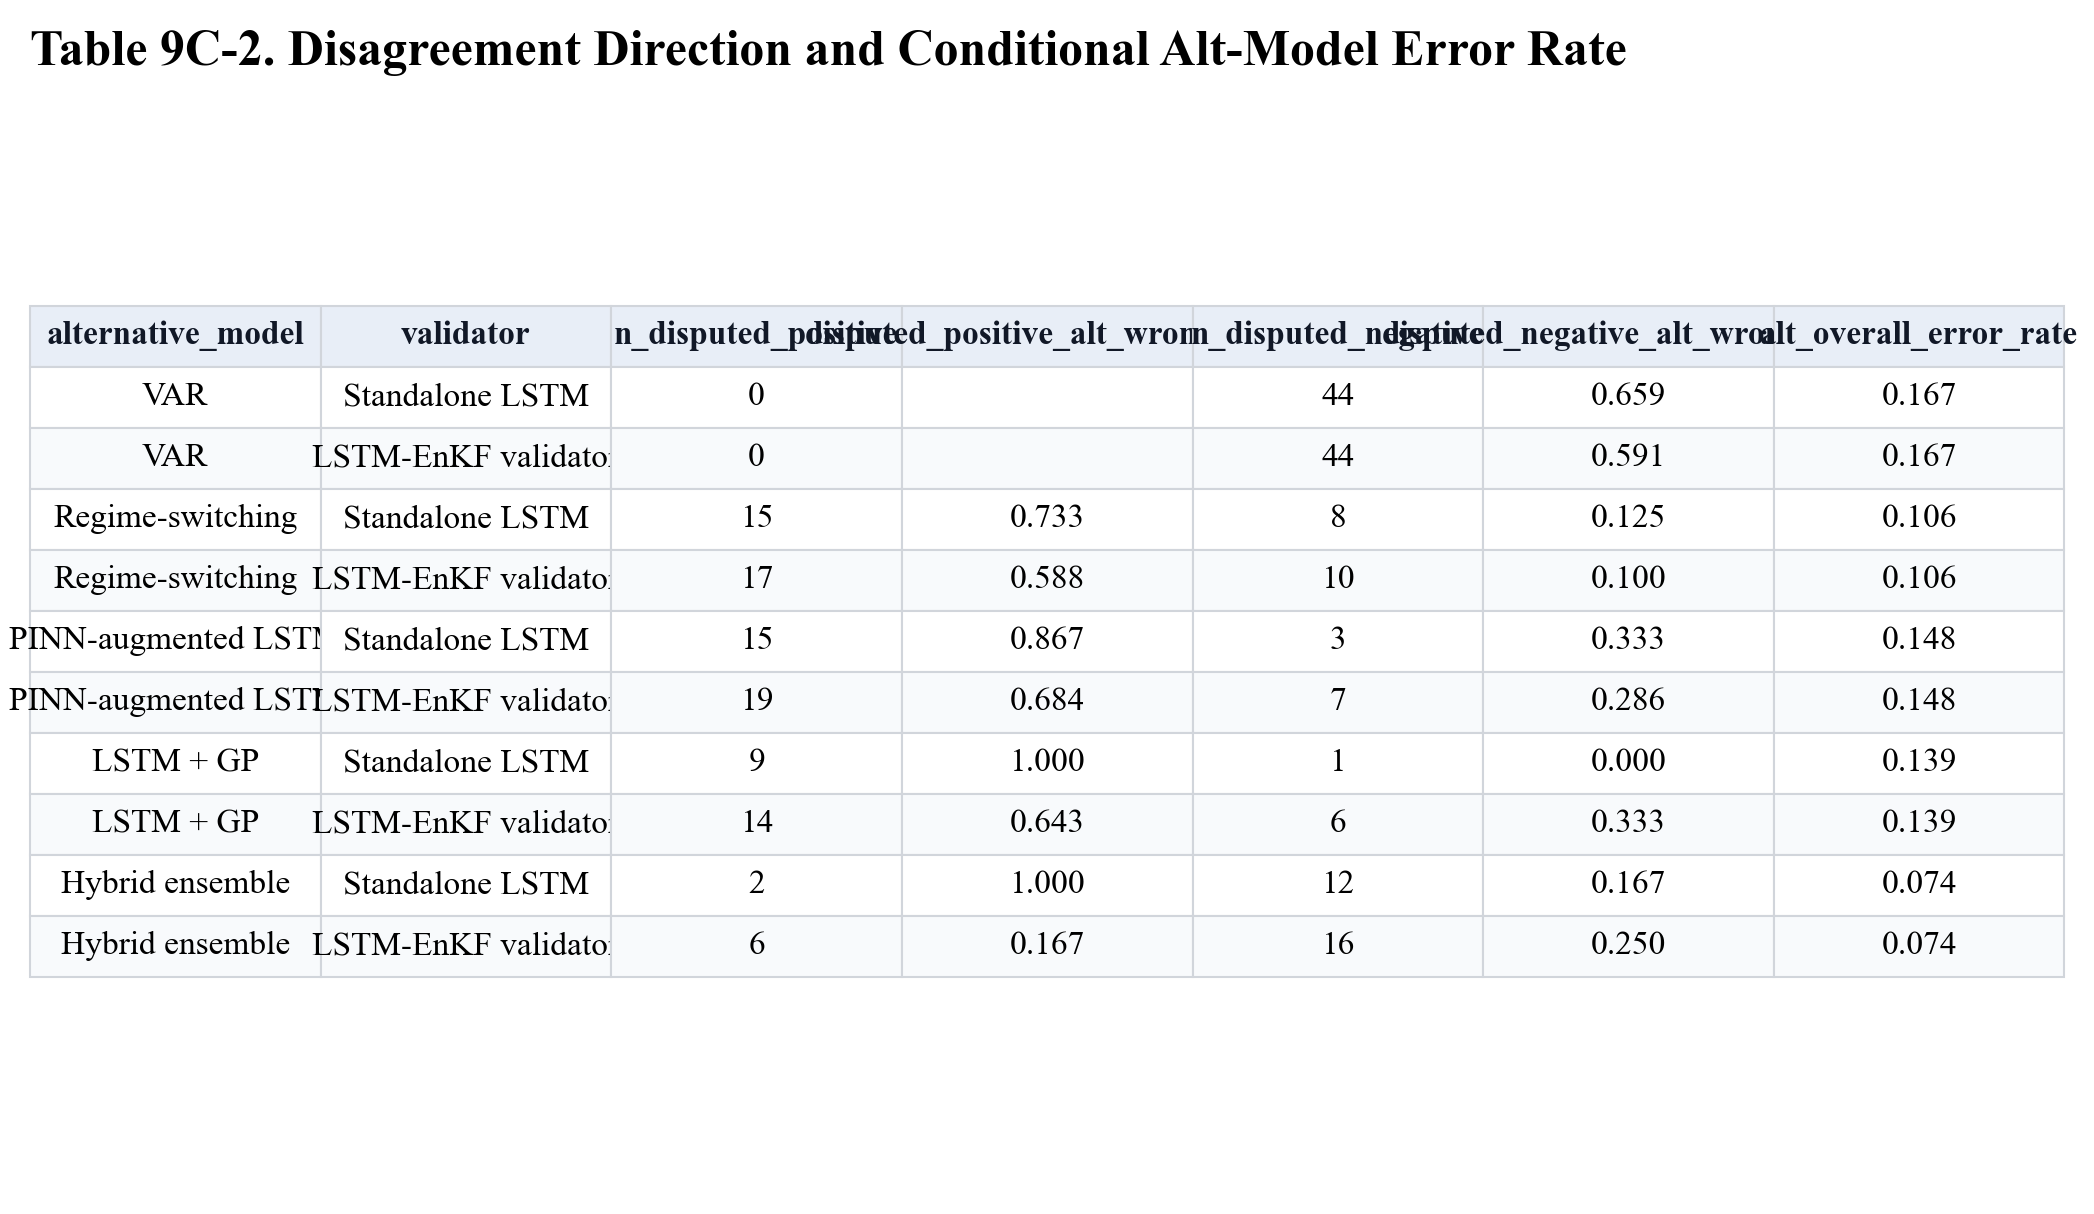

  saved output_refactored/validation_tools\Fig9J_disagreement_direction.png
  saved output_refactored/validation_tools\Fig9J_disagreement_direction.pdf


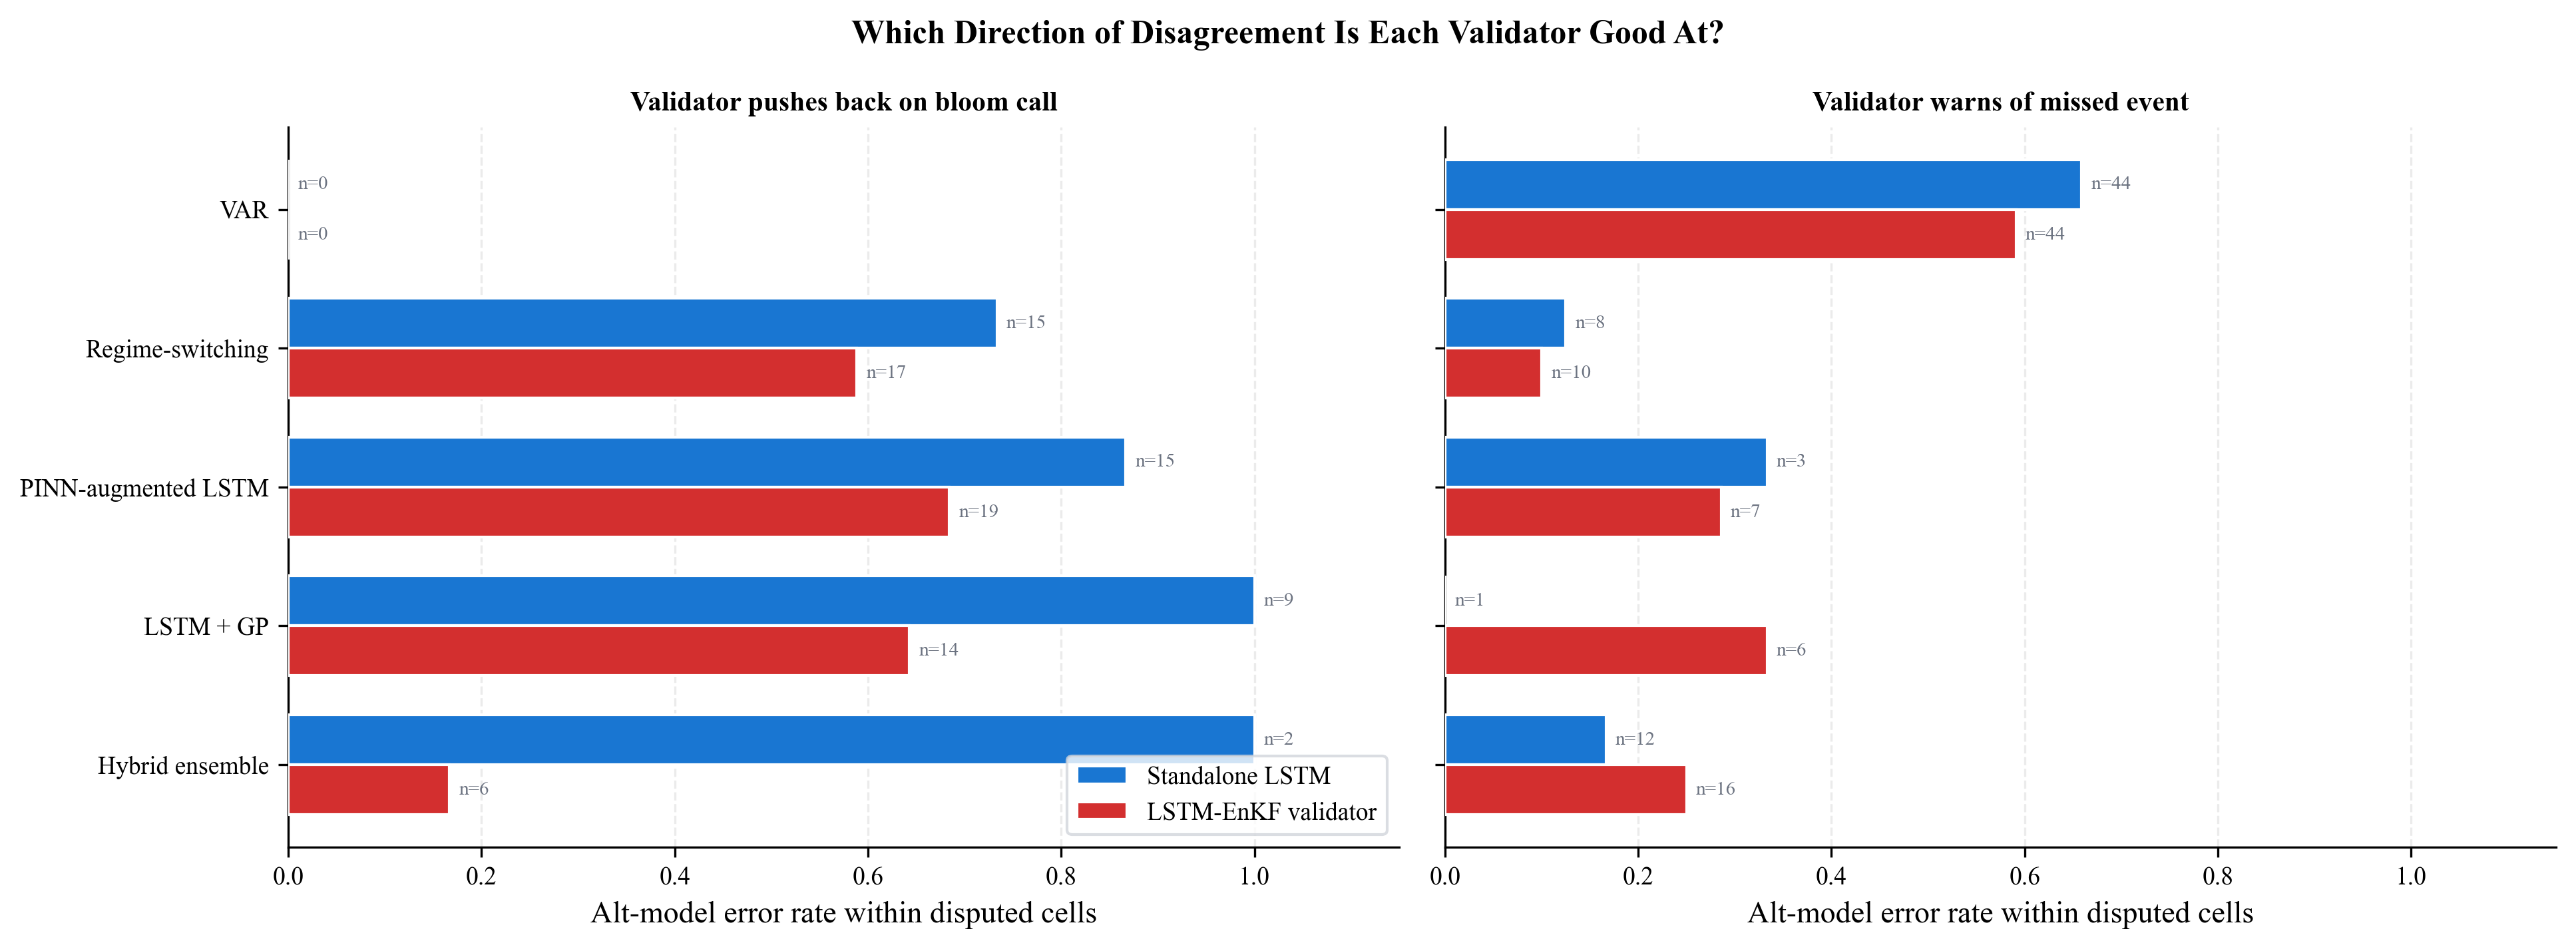


High rates in the left panel = strong false-alarm filter; high rates in the right panel = strong missed-event detector. Low counts (n) signal the cell is too sparse to interpret.


In [18]:
direction_rows = []
for alt_key in alternate_keys:
    alt_name = alternate_names[alt_key]
    for validator_name, spec in validator_specs.items():
        y, alt_prob, val_prob = align_tail(y_test, streams[alt_key], streams[spec['key']])
        alt_pred = (alt_prob >= 0.5).astype(int)
        val_pred = (val_prob >= spec['threshold']).astype(int)
        alt_wrong = (alt_pred != y)

        disputed_pos = (alt_pred == 1) & (val_pred == 0)   # validator pushes back on bloom call
        disputed_neg = (alt_pred == 0) & (val_pred == 1)   # validator warns of missed event
        n_pos = int(disputed_pos.sum())
        n_neg = int(disputed_neg.sum())

        direction_rows.append({
            'alternative_model': alt_name,
            'validator': validator_name,
            'n_disputed_positive': n_pos,
            'disputed_positive_alt_wrong_rate':
                float((alt_wrong & disputed_pos).sum() / n_pos) if n_pos > 0 else np.nan,
            'n_disputed_negative': n_neg,
            'disputed_negative_alt_wrong_rate':
                float((alt_wrong & disputed_neg).sum() / n_neg) if n_neg > 0 else np.nan,
            'alt_overall_error_rate': float(alt_wrong.mean()),
        })

direction_df = pd.DataFrame(direction_rows)
save_table(direction_df, 'Table9_disagreement_direction.csv',
           'Table 9C-2. Disagreement Direction and Conditional Alt-Model Error Rate')

# Stacked figure: how many weeks fall in each direction, colored by alt-error rate within
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
models = list(alternate_names.values())
y_pos = np.arange(len(models))
height = 0.36

for col_idx, (ax, direction_col, count_col, title) in enumerate([
    (axes[0], 'disputed_positive_alt_wrong_rate', 'n_disputed_positive',
     'Validator pushes back on bloom call'),
    (axes[1], 'disputed_negative_alt_wrong_rate', 'n_disputed_negative',
     'Validator warns of missed event'),
]):
    for i, validator_name in enumerate(validator_specs):
        sub = direction_df[direction_df['validator'] == validator_name].set_index('alternative_model').reindex(models)
        offset = (i - 0.5) * height
        bars = ax.barh(y_pos + offset, sub[direction_col].fillna(0).values, height,
                       label=validator_name, color=COLORS[validator_name], edgecolor='white', zorder=3)
        # Annotate with count
        for bar, n in zip(bars, sub[count_col].fillna(0).values):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'n={int(n)}', va='center', fontsize=7, color=COLORS['gray'])
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlim(0, 1.15)
    ax.set_xlabel('Alt-model error rate within disputed cells')
    ax.grid(axis='x', alpha=0.25, linestyle='--', zorder=0)

axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(models)
axes[0].invert_yaxis()
axes[0].legend(frameon=True, edgecolor='#D1D5DB', loc='lower right')
fig.suptitle('Which Direction of Disagreement Is Each Validator Good At?', fontweight='bold')
plt.tight_layout()
savefig(fig, 'Fig9J_disagreement_direction')
plt.show()

print('\nHigh rates in the left panel = strong false-alarm filter; high rates in the right panel = strong missed-event detector. Low counts (n) signal the cell is too sparse to interpret.')


## Validator-Adjudicated Predictions

  saved table output_refactored/validation_tools\Table9_validator_adjudicated_performance.csv


,alternative_model,validator,coverage_accepted_alt,base_F1,adjudicated_F1,delta_F1,base_Brier,adjudicated_Brier,delta_Brier,base_Recall,adjudicated_Recall,base_Precision,adjudicated_Precision
0,VAR,Standalone LSTM,0.796296,0.666667,0.855263,0.188596,0.103064,0.097789,-0.005276,0.514286,0.928571,0.947368,0.792683
1,VAR,LSTM-EnKF validator,0.796296,0.666667,0.815789,0.149123,0.103064,0.118511,0.015447,0.514286,0.885714,0.947368,0.756098
2,Regime-switching,Standalone LSTM,0.893519,0.855346,0.855263,-0.000083,0.112754,0.127988,0.015234,0.971429,0.928571,0.764045,0.792683
3,Regime-switching,LSTM-EnKF validator,0.875000,0.855346,0.815789,-0.039556,0.112754,0.143057,0.030303,0.971429,0.885714,0.764045,0.756098
4,PINN-augmented LSTM,Standalone LSTM,0.916667,0.804878,0.855263,0.050385,0.110397,0.104045,-0.006353,0.942857,0.928571,0.702128,0.792683
5,PINN-augmented LSTM,LSTM-EnKF validator,0.879630,0.804878,0.815789,0.010911,0.110397,0.121190,0.010793,0.942857,0.885714,0.702128,0.756098
6,LSTM + GP,Standalone LSTM,0.953704,0.812500,0.855263,0.042763,0.096296,0.090949,-0.005348,0.928571,0.928571,0.722222,0.792683
7,LSTM + GP,LSTM-EnKF validator,0.907407,0.812500,0.815789,0.003289,0.096296,0.106972,0.010676,0.928571,0.885714,0.722222,0.756098
8,Hybrid ensemble,Standalone LSTM,0.935185,0.887324,0.855263,-0.032061,0.064874,0.085153,0.020279,0.900000,0.928571,0.875000,0.792683
9,Hybrid ensemble,LSTM-EnKF validator,0.898148,0.887324,0.815789,-0.071534,0.064874,0.099872,0.034997,0.900000,0.885714,0.875000,0.756098


  saved output_refactored/validation_tools\Table9_validator_adjudicated_performance.png
  saved output_refactored/validation_tools\Table9_validator_adjudicated_performance.pdf


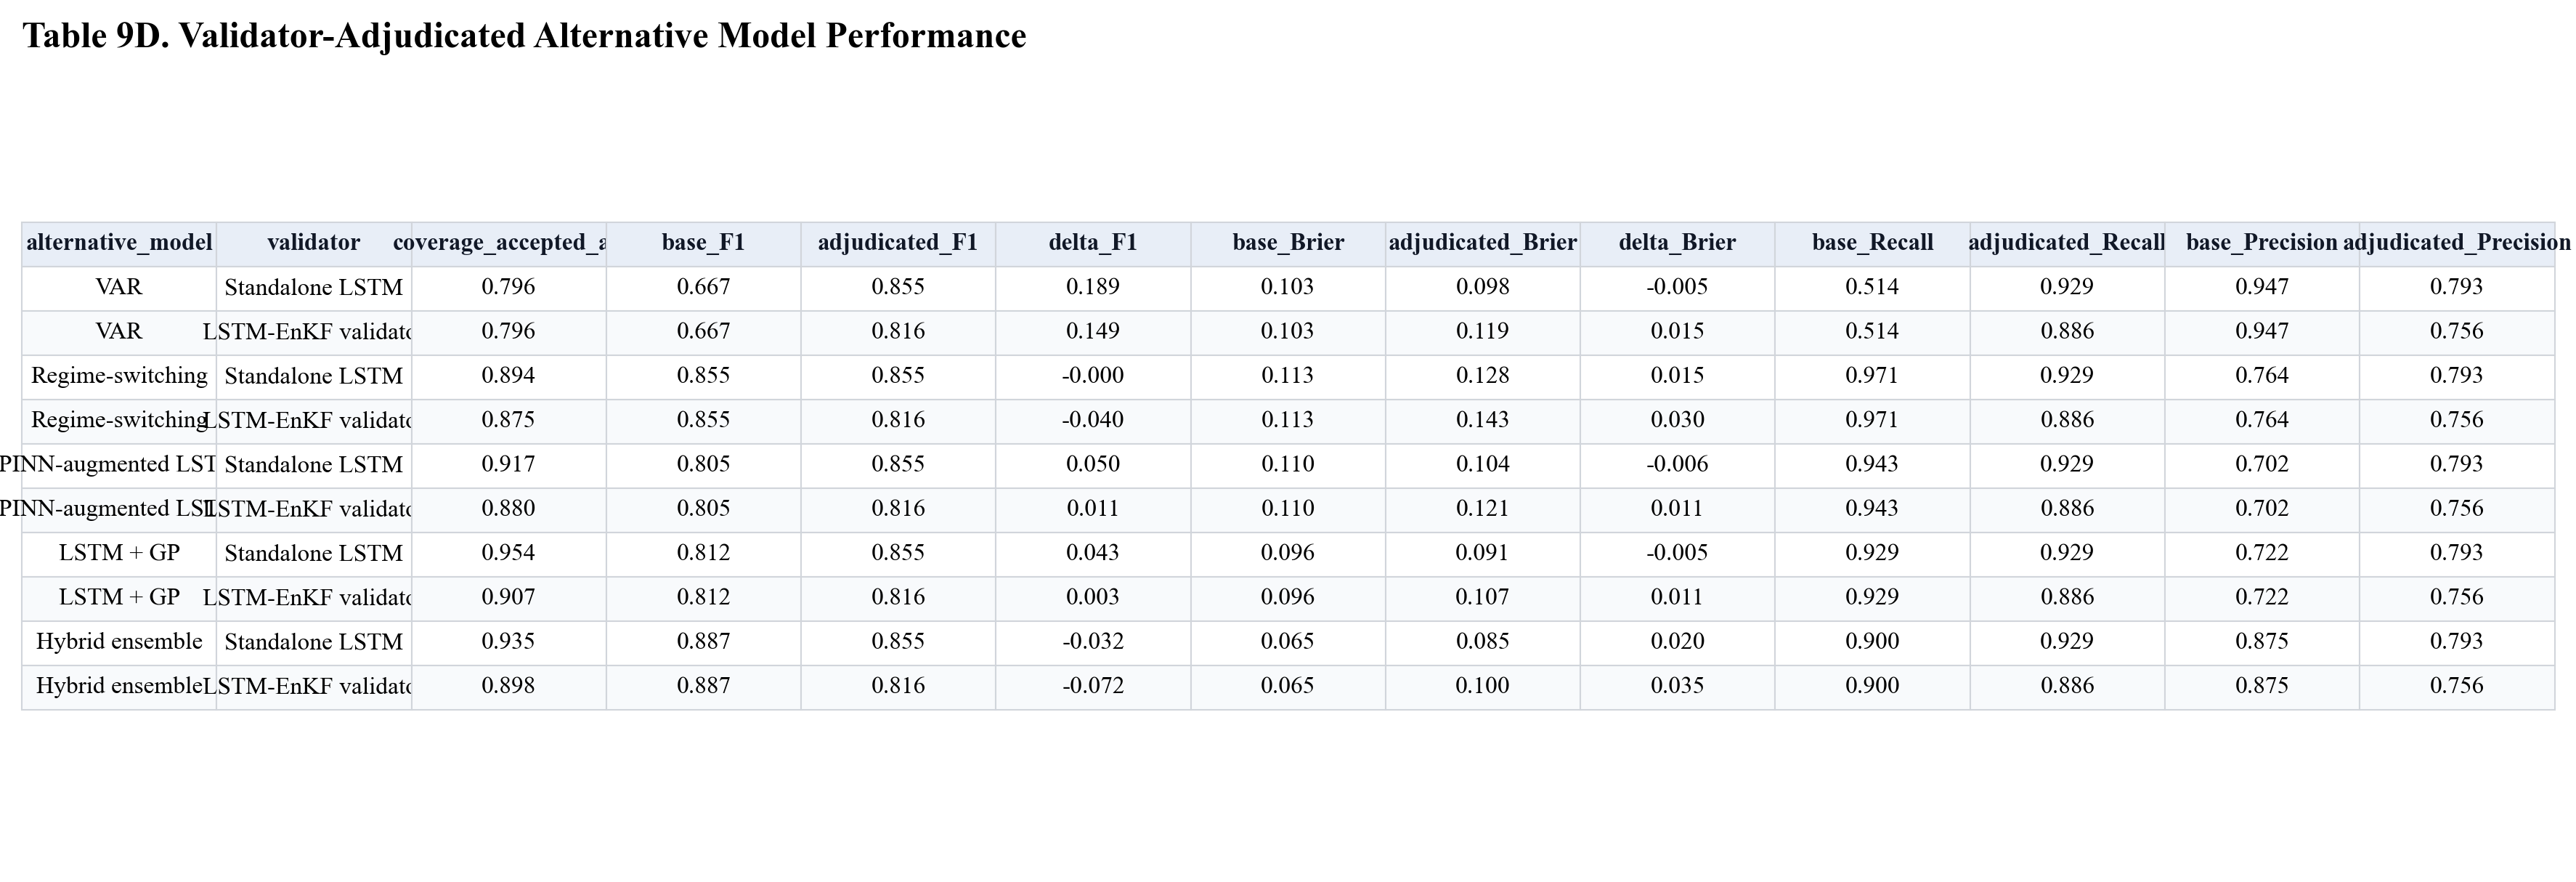

  saved output_refactored/validation_tools\Fig9D_validator_adjudicated_performance.png
  saved output_refactored/validation_tools\Fig9D_validator_adjudicated_performance.pdf


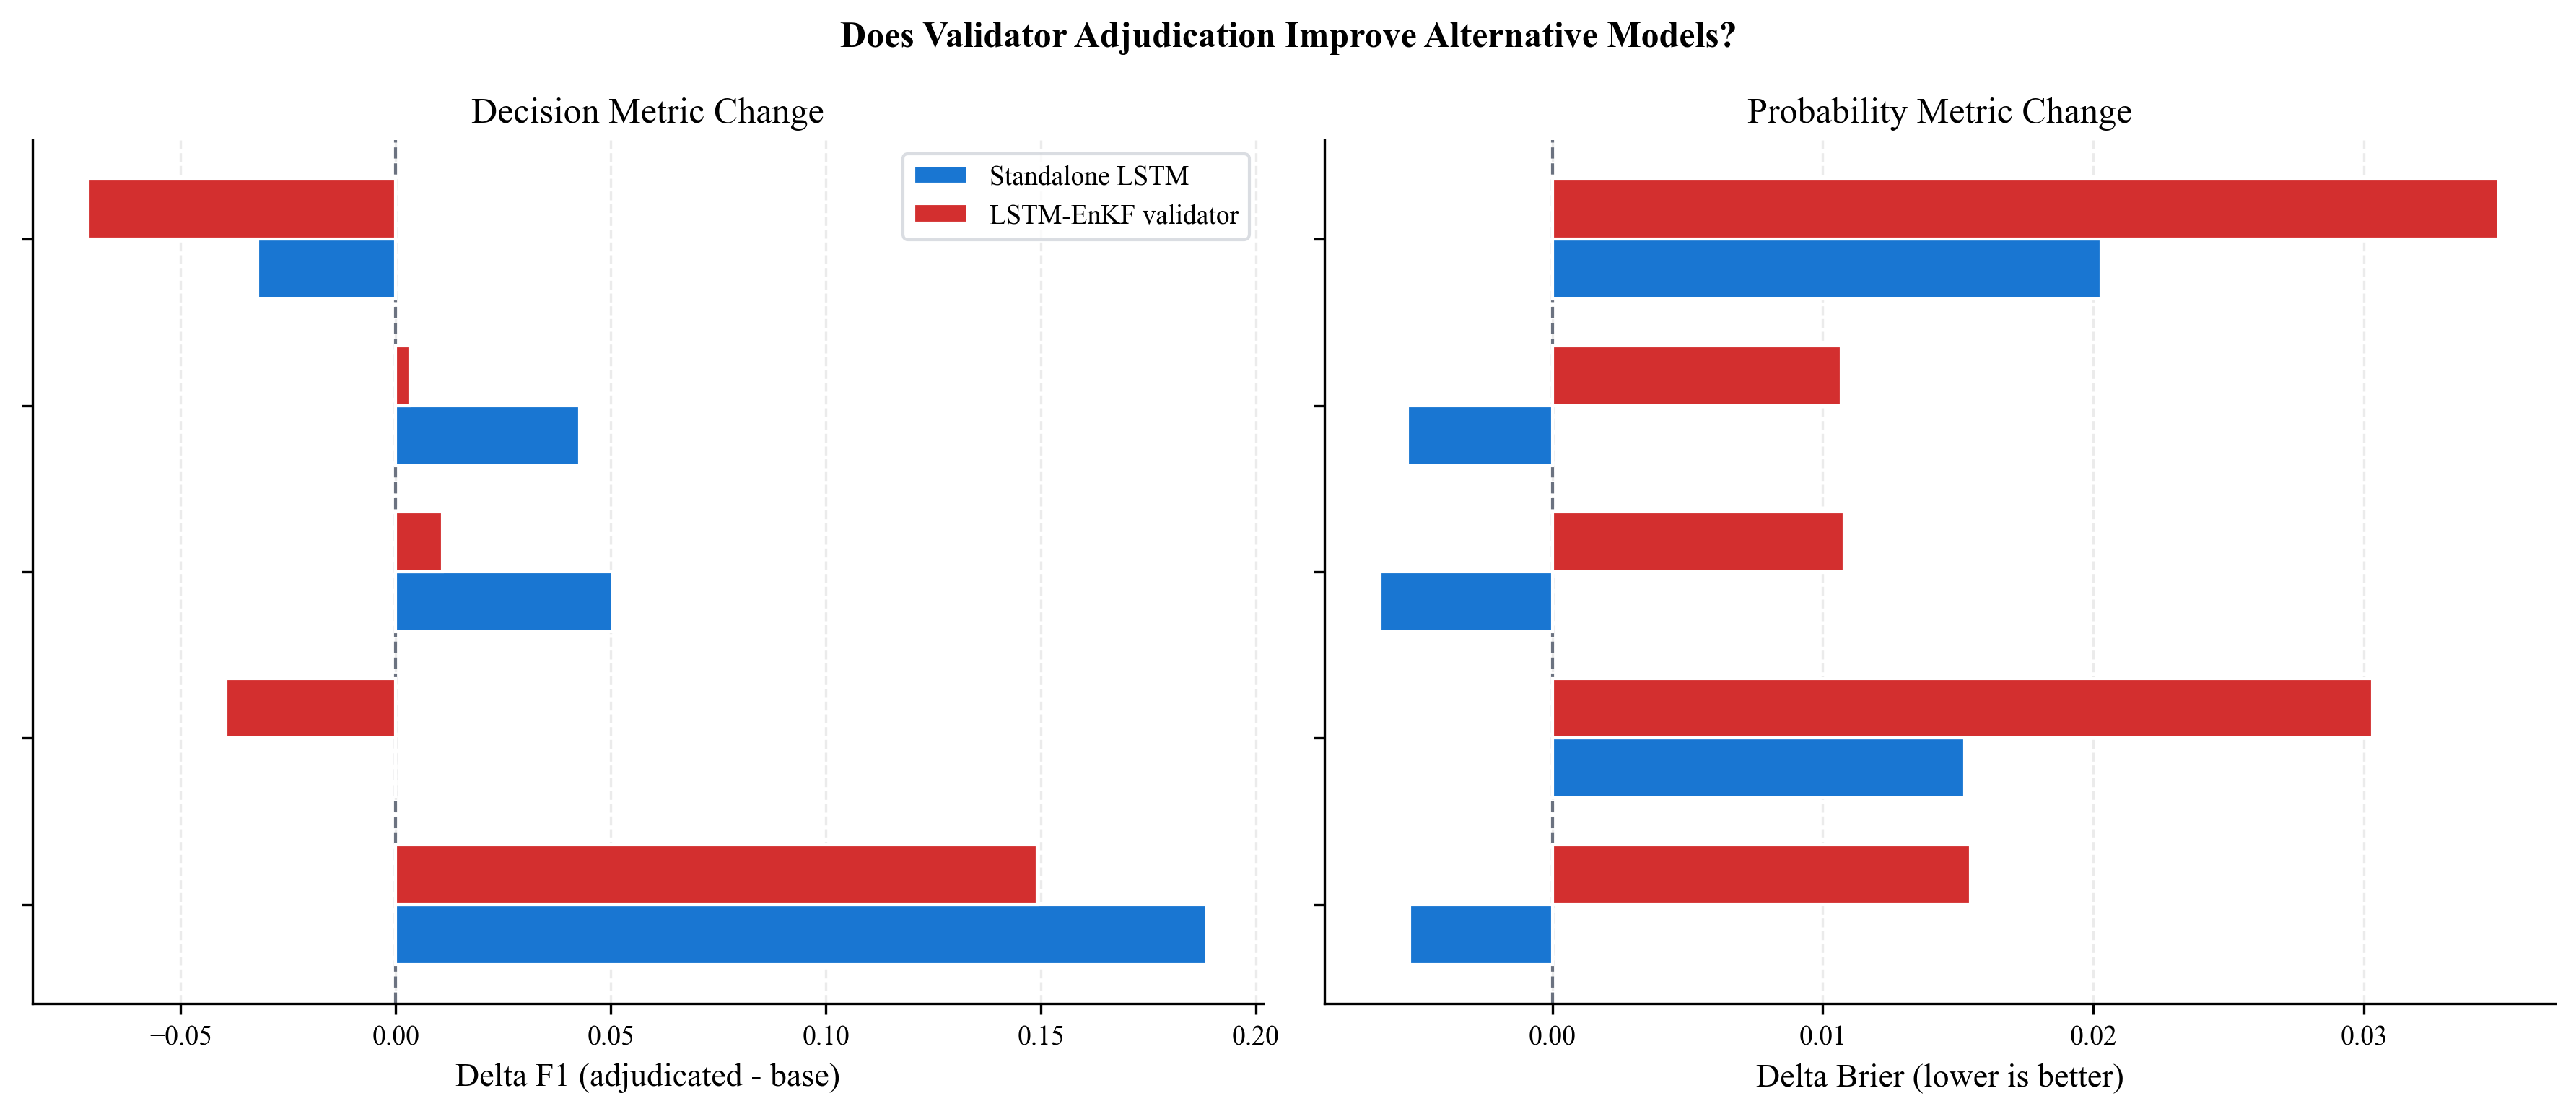

In [19]:
adjudication_rows = []
for alt_key in alternate_keys:
    alt_name = alternate_names[alt_key]
    for validator_name, spec in validator_specs.items():
        y, alt_prob, val_prob = align_tail(y_test, streams[alt_key], streams[spec['key']])
        alt_pred = (alt_prob >= 0.5).astype(int)
        val_pred = (val_prob >= spec['threshold']).astype(int)
        agree = alt_pred == val_pred

        # Policy: accept the alternate model when validator agrees; when it
        # disagrees, let the validator adjudicate. This is a decision-support
        # policy, not a retrained ensemble.
        adjudicated_prob = np.where(agree, alt_prob, val_prob)
        adjudicated_pred = np.where(agree, alt_pred, val_pred)
        base = hard_metrics(y, alt_prob, threshold=0.5)
        adjudicated = {
            'Accuracy': float(accuracy_score(y, adjudicated_pred)),
            'Precision': float(precision_score(y, adjudicated_pred, zero_division=0)),
            'Recall': float(recall_score(y, adjudicated_pred, zero_division=0)),
            'F1': float(f1_score(y, adjudicated_pred, zero_division=0)),
            'Brier': float(brier_score_loss(y, adjudicated_prob)),
            'AUC': safe_auc(y, adjudicated_prob),
            'AUPRC': safe_ap(y, adjudicated_prob),
        }
        adjudication_rows.append({
            'alternative_model': alt_name,
            'validator': validator_name,
            'coverage_accepted_alt': float(agree.mean()),
            'base_F1': base['F1'],
            'adjudicated_F1': adjudicated['F1'],
            'delta_F1': adjudicated['F1'] - base['F1'],
            'base_Brier': base['Brier'],
            'adjudicated_Brier': adjudicated['Brier'],
            'delta_Brier': adjudicated['Brier'] - base['Brier'],
            'base_Recall': base['Recall'],
            'adjudicated_Recall': adjudicated['Recall'],
            'base_Precision': base['Precision'],
            'adjudicated_Precision': adjudicated['Precision'],
        })

adj_df = pd.DataFrame(adjudication_rows)
save_table(adj_df, 'Table9_validator_adjudicated_performance.csv',
           'Table 9D. Validator-Adjudicated Alternative Model Performance')

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True)
models = adj_df['alternative_model'].unique().tolist()
y_pos = np.arange(len(models))
height = 0.36
for i, validator_name in enumerate(validator_specs):
    sub = adj_df[adj_df['validator'] == validator_name].set_index('alternative_model').reindex(models)
    axes[0].barh(y_pos + (i - 0.5) * height, sub['delta_F1'], height,
                 label=validator_name, color=COLORS[validator_name], edgecolor='white', zorder=3)
    axes[1].barh(y_pos + (i - 0.5) * height, sub['delta_Brier'], height,
                 label=validator_name, color=COLORS[validator_name], edgecolor='white', zorder=3)
axes[0].axvline(0, color=COLORS['gray'], linestyle='--', linewidth=1)
axes[1].axvline(0, color=COLORS['gray'], linestyle='--', linewidth=1)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(models)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([])
axes[0].set_xlabel('Delta F1 (adjudicated - base)')
axes[1].set_xlabel('Delta Brier (lower is better)')
axes[0].set_title('Decision Metric Change')
axes[1].set_title('Probability Metric Change')
for ax in axes:
    ax.grid(axis='x', alpha=0.25, linestyle='--', zorder=0)
    ax.invert_yaxis()
axes[0].legend(frameon=True, edgecolor='#D1D5DB')
fig.suptitle('Does Validator Adjudication Improve Alternative Models?', fontweight='bold')
plt.tight_layout()
savefig(fig, 'Fig9D_validator_adjudicated_performance')
plt.show()

## Coverage–Accuracy Operating Curve

The agreement-gated acceptance results in Table 9C report a single operating point per (alt, validator) pair, defined by the hard `agree == disagree` boolean. Sweeping a continuous "agreement strictness" threshold τ — accepting a forecast only when `|alt_prob − val_prob| ≤ τ` — traces a coverage–accuracy curve, the validator's analog of an ROC curve. Two validators with the same single operating point can have very different curves.


  saved output_refactored/validation_tools\Fig9K_coverage_accuracy_curve.png
  saved output_refactored/validation_tools\Fig9K_coverage_accuracy_curve.pdf


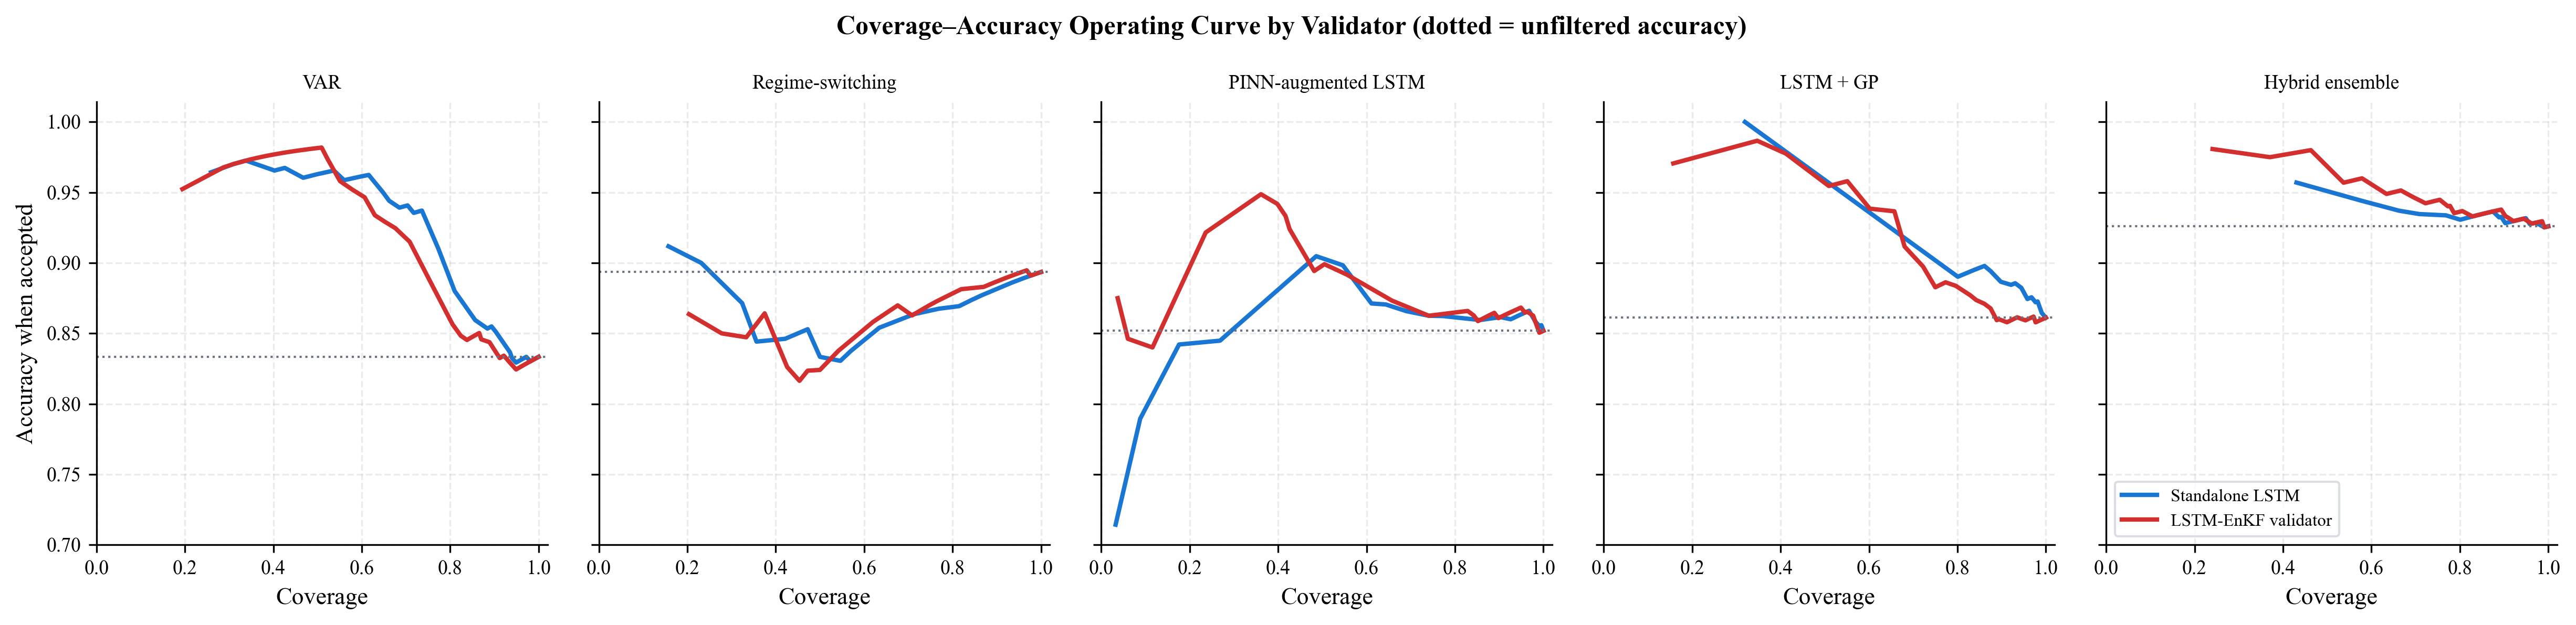

  saved table output_refactored/validation_tools\Table9_coverage_accuracy_summary.csv


,alternative_model,validator,curve_area,accuracy_at_70pct_coverage,baseline_overall_accuracy
0,VAR,Standalone LSTM,0.686291,0.940469,0.833333
1,VAR,LSTM-EnKF validator,0.742826,0.917508,0.833333
2,Regime-switching,Standalone LSTM,0.730260,0.862052,0.893519
3,Regime-switching,LSTM-EnKF validator,0.684834,0.864575,0.893519
4,PINN-augmented LSTM,Standalone LSTM,0.829236,0.865117,0.851852
5,PINN-augmented LSTM,LSTM-EnKF validator,0.853433,0.867750,0.851852
6,LSTM + GP,Standalone LSTM,0.631339,0.913195,0.861111
7,LSTM + GP,LSTM-EnKF validator,0.784756,0.904971,0.861111
8,Hybrid ensemble,Standalone LSTM,0.534308,0.935077,0.925926
9,Hybrid ensemble,LSTM-EnKF validator,0.725064,0.945795,0.925926


  saved output_refactored/validation_tools\Table9_coverage_accuracy_summary.png
  saved output_refactored/validation_tools\Table9_coverage_accuracy_summary.pdf


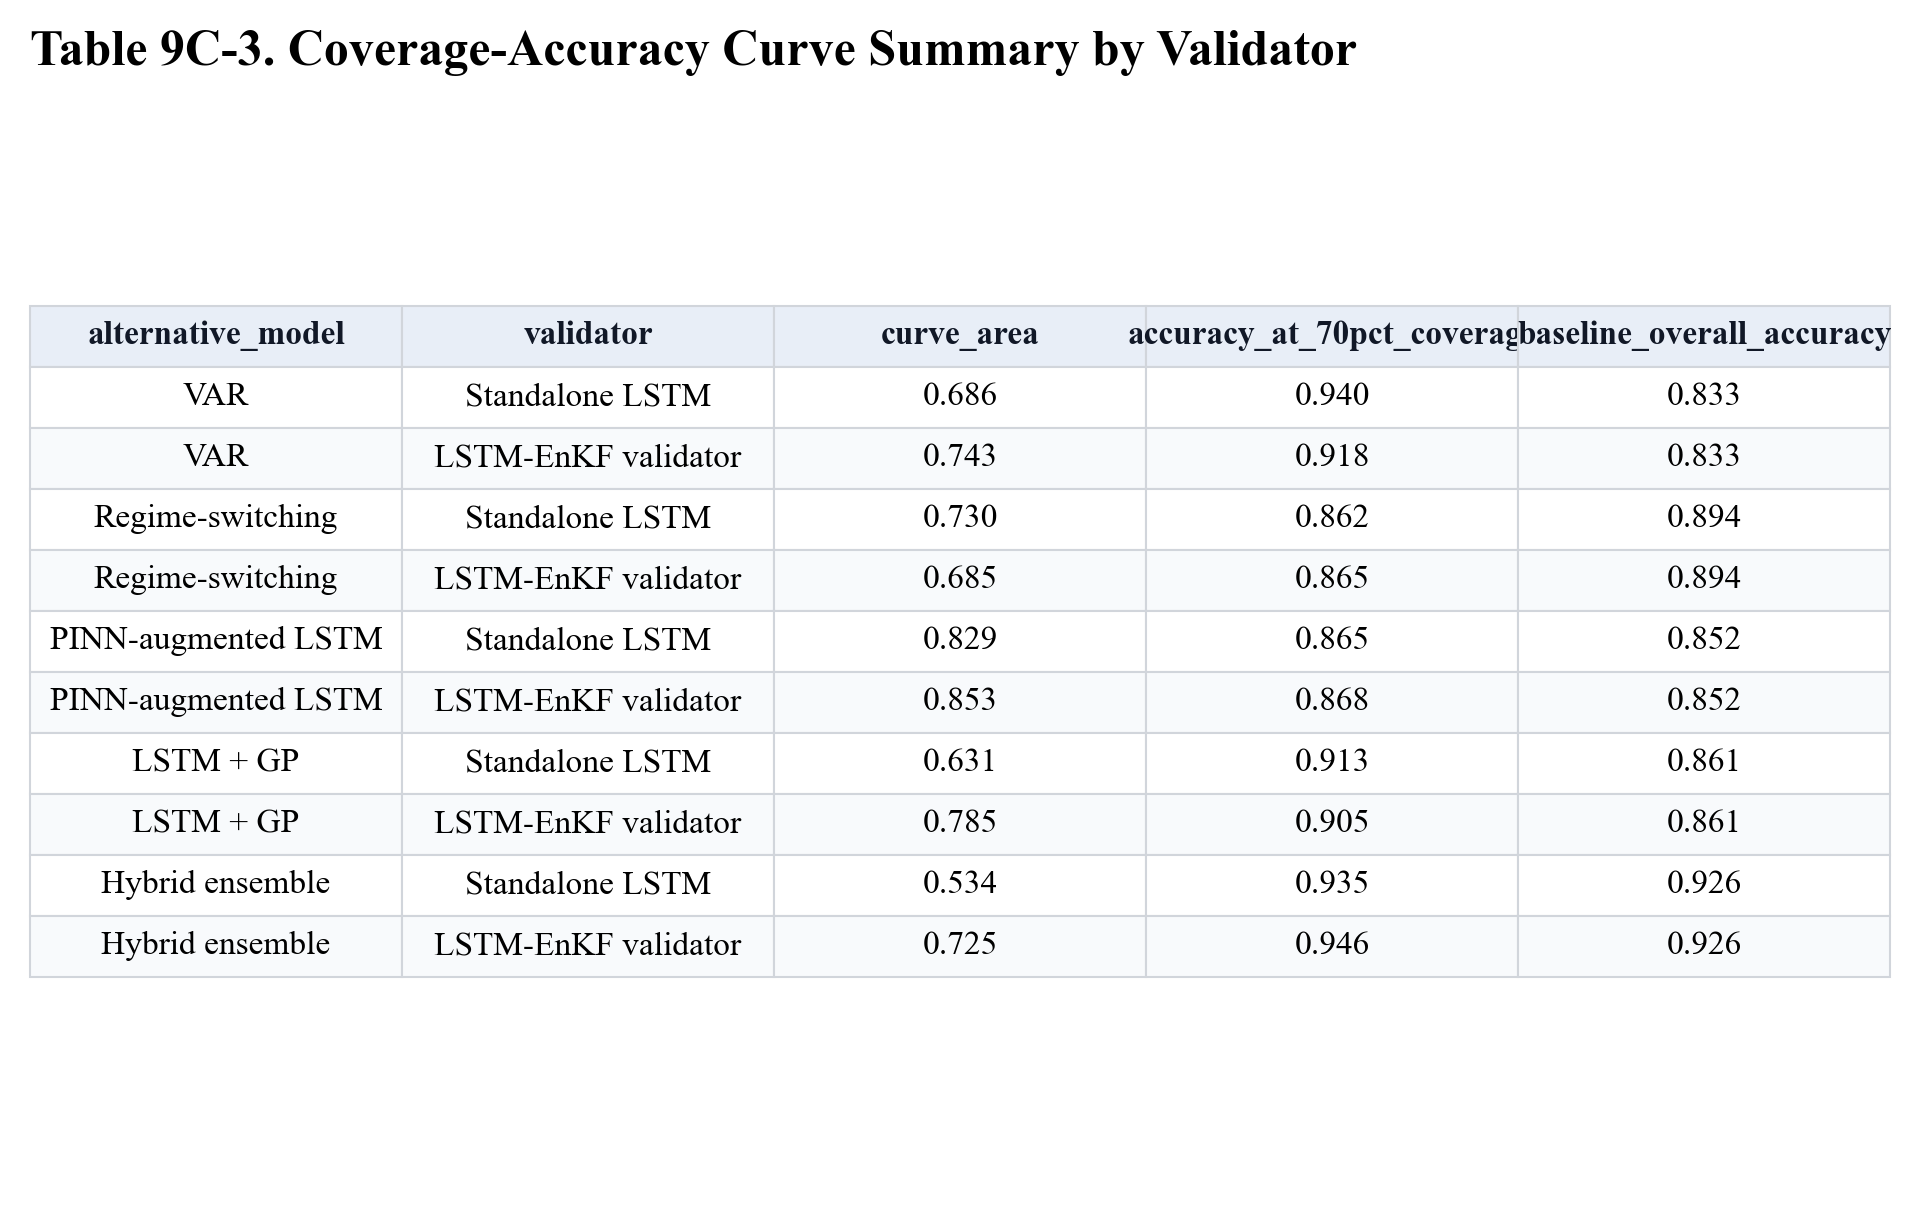


A validator dominating the upper-left of its panel is the better triage tool: it offers high accuracy at low coverage. accuracy_at_70pct_coverage is a single operating-point summary at a policy-relevant coverage level.


In [21]:
taus = np.linspace(0, 1, 51)

curve_summary_rows = []
fig, axes = plt.subplots(1, len(alternate_keys), figsize=(3.3 * len(alternate_keys), 4),
                         sharey=True, sharex=True)
if len(alternate_keys) == 1:
    axes = [axes]

for ax, alt_key in zip(axes, alternate_keys):
    alt_name = alternate_names[alt_key]
    y, alt_prob = align_tail(y_test, streams[alt_key])
    alt_pred = (alt_prob >= 0.5).astype(int)
    overall_acc = float((alt_pred == y).mean())

    for validator_name, spec in validator_specs.items():
        _, _, val_prob = align_tail(y_test, streams[alt_key], streams[spec['key']])
        gap = np.abs(alt_prob - val_prob)
        coverages, accuracies = [], []
        for tau in taus:
            accept = gap <= tau
            if accept.sum() == 0:
                coverages.append(0.0)
                accuracies.append(np.nan)
                continue
            coverages.append(float(accept.mean()))
            accuracies.append(float((alt_pred[accept] == y[accept]).mean()))

        ax.plot(coverages, accuracies, color=COLORS[validator_name], lw=2, label=validator_name)

        # Compute an "operating-curve AUC" — area under the curve, plotted as
        # accuracy vs coverage. Trapezoidal rule, with NaNs treated as drop-outs.
        cov_arr = np.array(coverages)
        acc_arr = np.array(accuracies, dtype=float)
        finite = np.isfinite(acc_arr) & np.isfinite(cov_arr)
        if finite.sum() >= 2:
            order = np.argsort(cov_arr[finite])
            _trapz = getattr(np, 'trapezoid', getattr(np, 'trapz', None))
            curve_auc = float(_trapz(acc_arr[finite][order], cov_arr[finite][order]))
        else:
            curve_auc = np.nan
        # Accuracy at fixed 70% coverage (interpolated)
        if finite.sum() >= 2:
            order = np.argsort(cov_arr[finite])
            xs = cov_arr[finite][order]; ys = acc_arr[finite][order]
            acc_at_70 = float(np.interp(0.70, xs, ys)) if xs.min() <= 0.70 <= xs.max() else np.nan
        else:
            acc_at_70 = np.nan
        curve_summary_rows.append({
            'alternative_model': alt_name,
            'validator': validator_name,
            'curve_area': curve_auc,
            'accuracy_at_70pct_coverage': acc_at_70,
            'baseline_overall_accuracy': overall_acc,
        })

    ax.axhline(overall_acc, color=COLORS['gray'], linestyle=':', lw=1)
    ax.set_title(alt_name, fontsize=9)
    ax.set_xlim(0, 1.02)
    ax.set_xlabel('Coverage')
    ax.grid(alpha=0.25, linestyle='--')

axes[0].set_ylabel('Accuracy when accepted')
axes[-1].legend(frameon=True, edgecolor='#D1D5DB', loc='lower left', fontsize=8)
fig.suptitle('Coverage–Accuracy Operating Curve by Validator (dotted = unfiltered accuracy)',
             fontweight='bold')
plt.tight_layout()
savefig(fig, 'Fig9K_coverage_accuracy_curve')
plt.show()

curve_df = pd.DataFrame(curve_summary_rows)
save_table(curve_df, 'Table9_coverage_accuracy_summary.csv',
           'Table 9C-3. Coverage-Accuracy Curve Summary by Validator')

print('\nA validator dominating the upper-left of its panel is the better triage tool: it offers high accuracy at low coverage. accuracy_at_70pct_coverage is a single operating-point summary at a policy-relevant coverage level.')


## Overall Validator Comparison

  saved table output_refactored/validation_tools\Table9_validator_summary.csv


,validator,mean_error_detection_AUROC,mean_error_detection_AUPRC,mean_agreement_coverage,mean_accepted_alt_accuracy,mean_accepted_accuracy_lift,mean_alt_error_capture_by_flags,mean_alt_false_alarm_capture,mean_alt_missed_event_capture,mean_delta_F1_when_adjudicating,mean_delta_Brier_when_adjudicating
0,Standalone LSTM,0.494083,0.188143,0.899074,0.930010,0.056862,0.462959,0.392579,0.379552,0.049920,0.003707
1,LSTM-EnKF validator,0.537978,0.208212,0.871296,0.927051,0.053903,0.469680,0.352897,0.578711,0.010447,0.020443


  saved output_refactored/validation_tools\Table9_validator_summary.png
  saved output_refactored/validation_tools\Table9_validator_summary.pdf


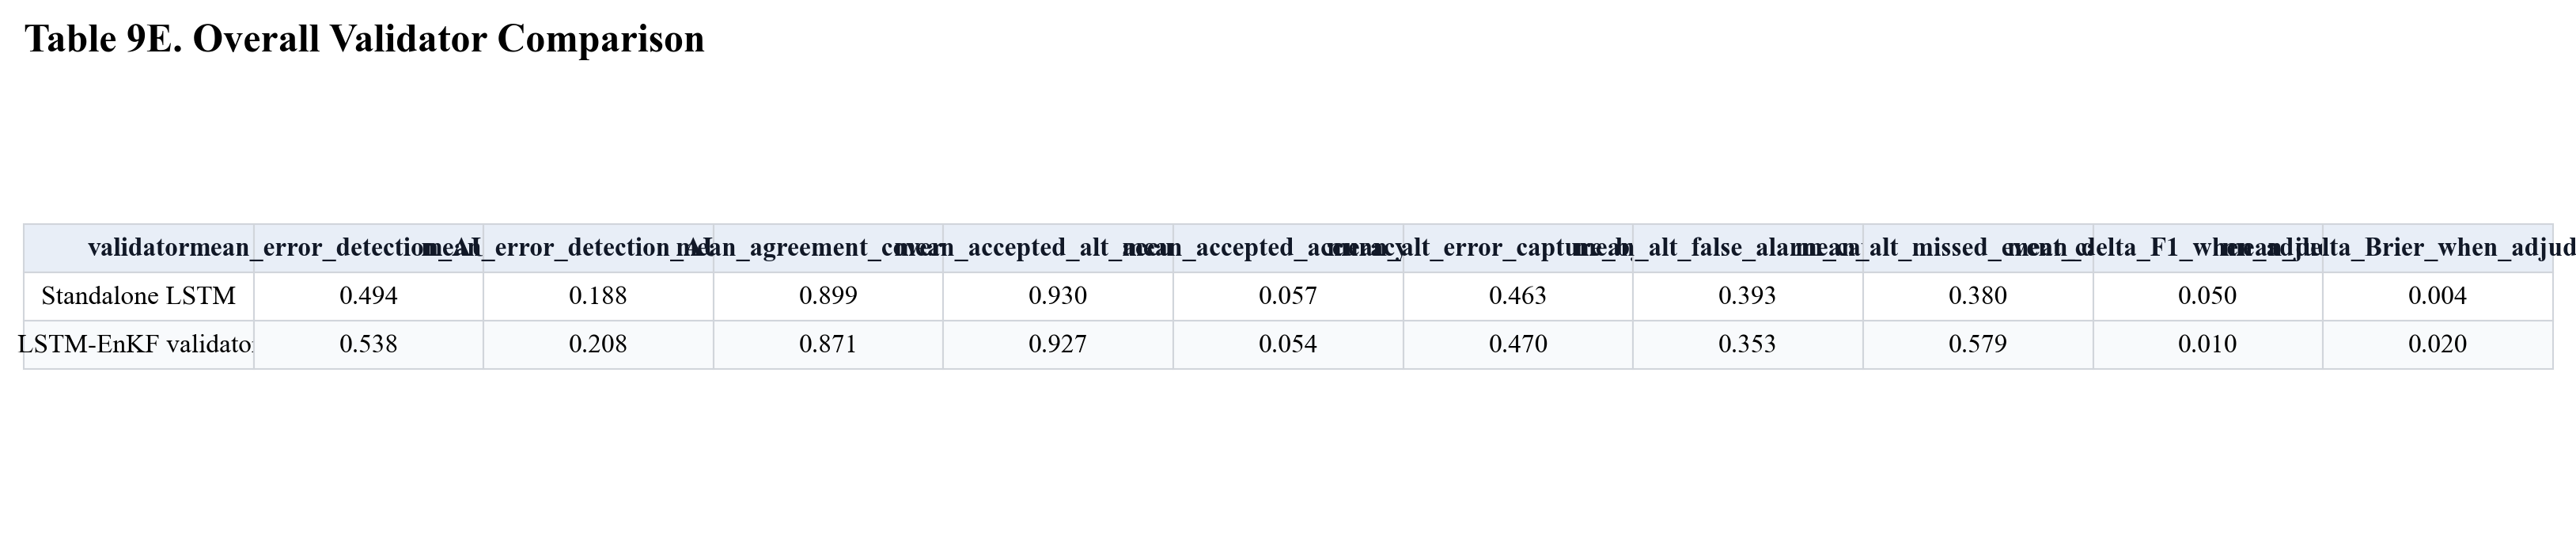

  saved table output_refactored/validation_tools\Table9_validator_verdict_by_criterion.csv


,criterion,preferred_validator,spread
0,mean_error_detection_AUROC,LSTM-EnKF validator,0.043895
1,mean_error_detection_AUPRC,LSTM-EnKF validator,0.020069
2,mean_agreement_coverage,Standalone LSTM,0.027778
3,mean_accepted_alt_accuracy,No clear winner,0.002959
4,mean_accepted_accuracy_lift,No clear winner,0.002959
5,mean_alt_error_capture_by_flags,No clear winner,0.006721
6,mean_alt_false_alarm_capture,Standalone LSTM,0.039683
7,mean_alt_missed_event_capture,LSTM-EnKF validator,0.199160
8,mean_delta_F1_when_adjudicating,Standalone LSTM,0.039474
9,mean_delta_Brier_when_adjudicating,Standalone LSTM,0.016736


  saved output_refactored/validation_tools\Table9_validator_verdict_by_criterion.png
  saved output_refactored/validation_tools\Table9_validator_verdict_by_criterion.pdf


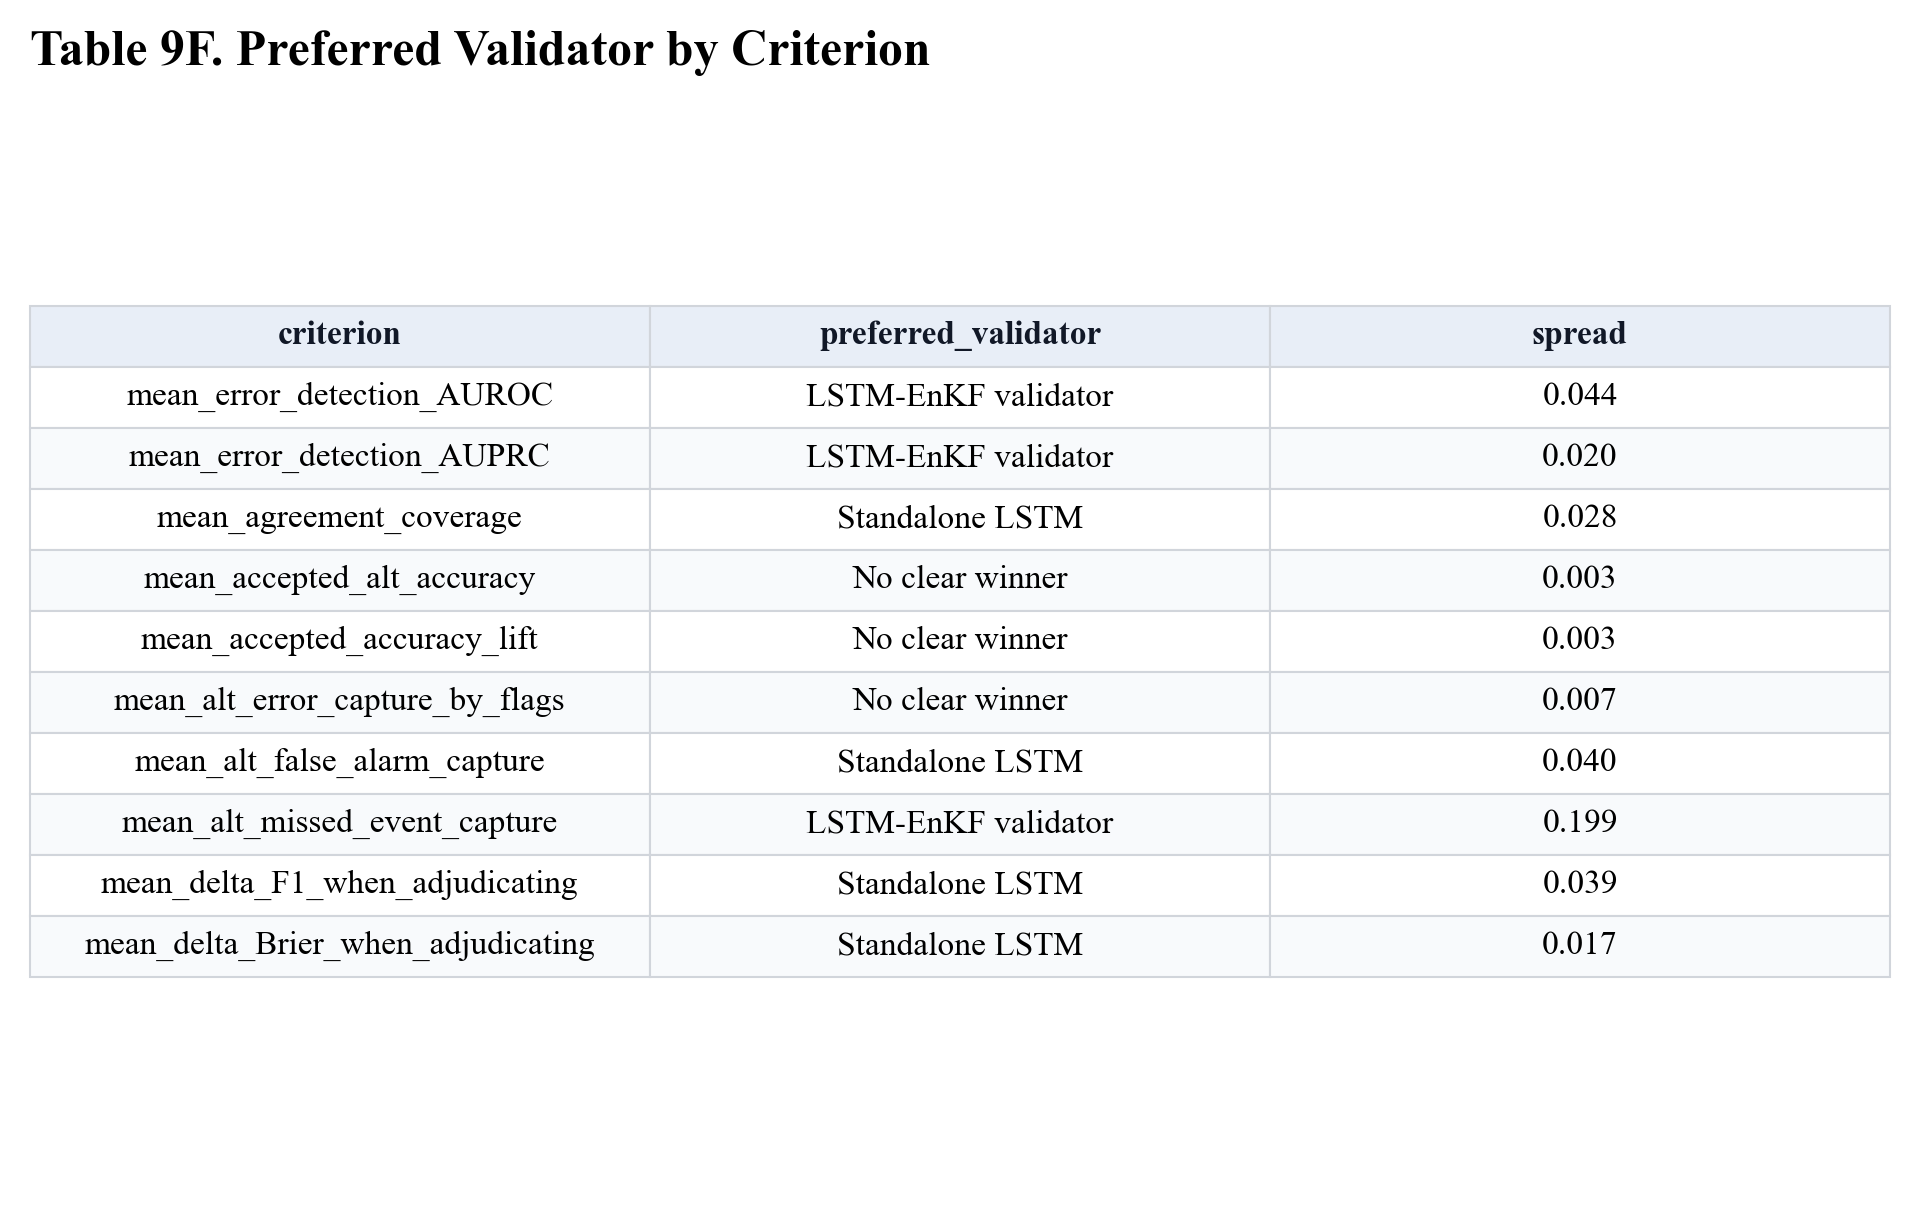

  saved output_refactored/validation_tools\Fig9E_validator_summary_profile.png
  saved output_refactored/validation_tools\Fig9E_validator_summary_profile.pdf


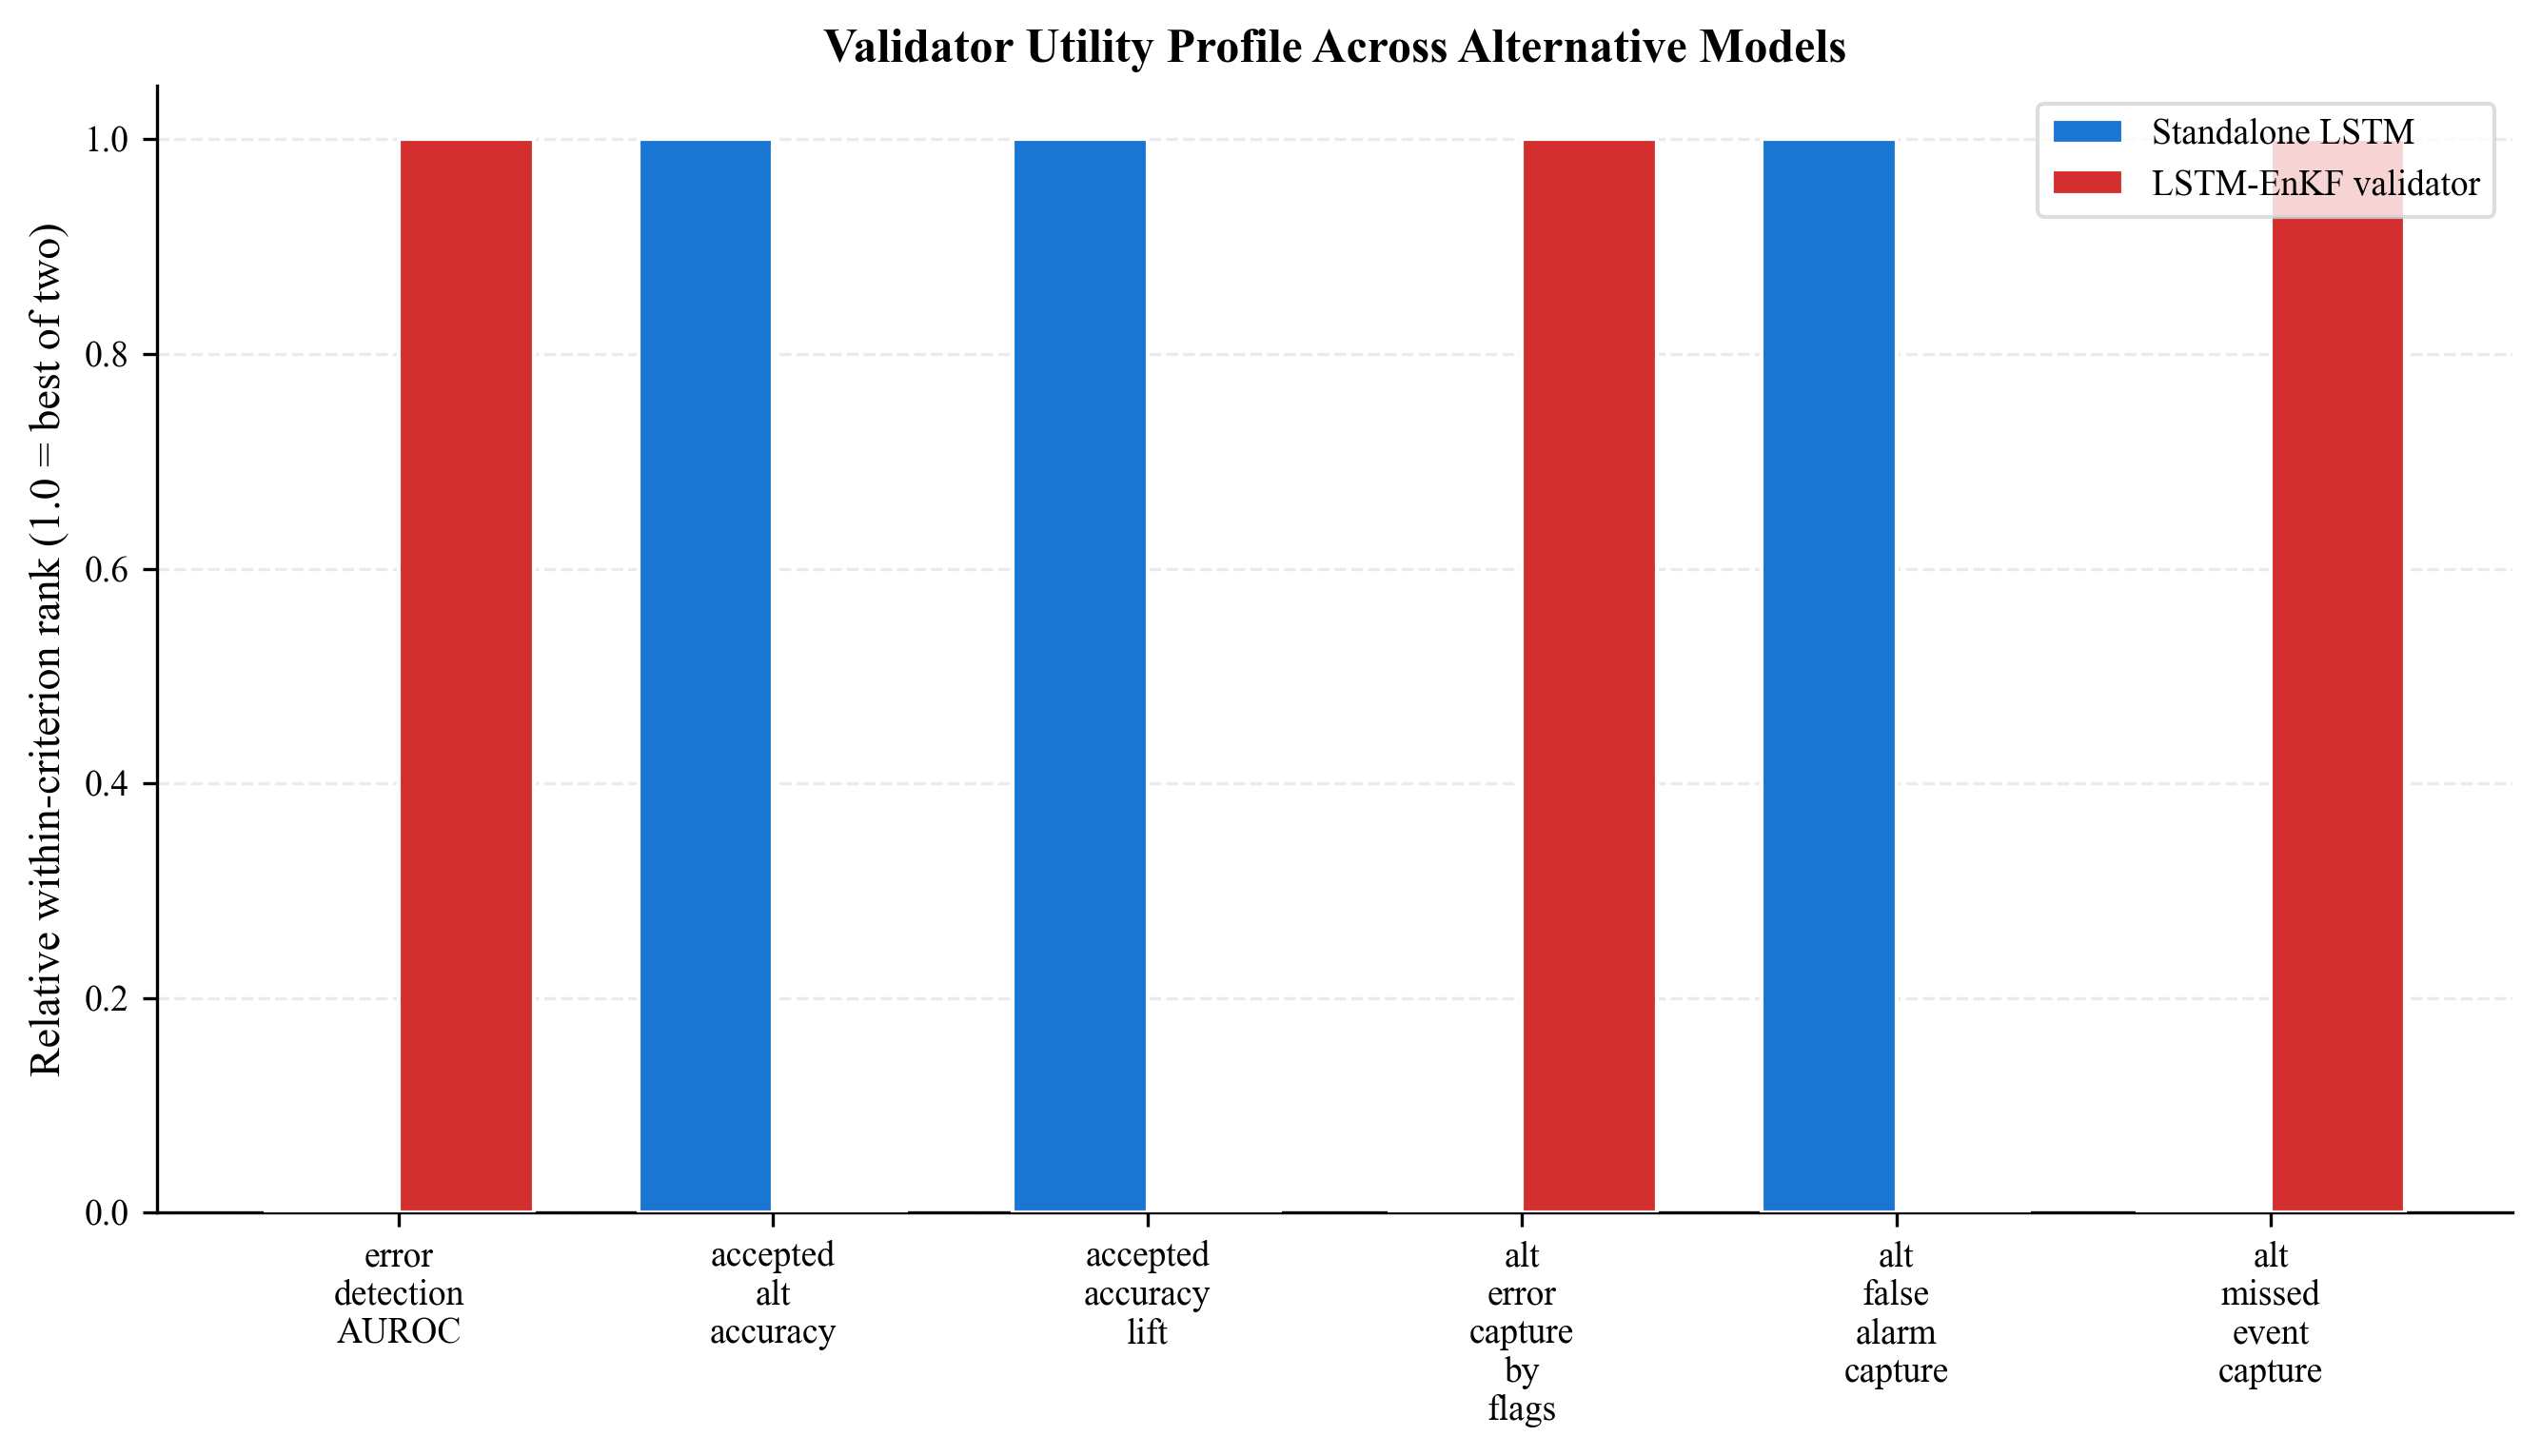


Interpretation guide:
- Strong validation tools should have high error-detection AUROC and high accepted accuracy.
- A positive delta_F1 means using the validator to adjudicate disagreements improved hard predictions.
- A negative delta_Brier means adjudication improved probability quality.
- False-alarm capture and missed-event capture are operationally distinct: the former protects credibility, the latter protects public safety. A validator may be strong on one and weak on the other.
- Verdicts here are descriptive. Holm-corrected paired-bootstrap CIs in the next section are the authoritative comparison.
- If EnKF does not win direct forecasting metrics but wins error-capture or capture-direction criteria, frame it as a validation/triage tool, not a superior forecaster.


In [22]:
# Aggregate across alternate models. Higher is better except mean_delta_Brier.
summary_rows = []
for validator_name in validator_specs:
    err = error_df[(error_df['validator'] == validator_name) &
                   (error_df['signal'] == 'Confidence-weighted contradiction')]
    gate = gate_df[gate_df['validator'] == validator_name]
    adj = adj_df[adj_df['validator'] == validator_name]
    summary_rows.append({
        'validator': validator_name,
        'mean_error_detection_AUROC': err['AUROC_alt_wrong'].mean(),
        'mean_error_detection_AUPRC': err['AUPRC_alt_wrong'].mean(),
        'mean_agreement_coverage': gate['agreement_coverage'].mean(),
        'mean_accepted_alt_accuracy': gate['accepted_alt_accuracy'].mean(),
        'mean_accepted_accuracy_lift': gate['accepted_accuracy_lift'].mean(),
        'mean_alt_error_capture_by_flags': gate['alt_error_capture_by_flags'].mean(),
        'mean_alt_false_alarm_capture': gate['alt_false_alarm_capture'].mean(),
        'mean_alt_missed_event_capture': gate['alt_missed_event_capture'].mean(),
        'mean_delta_F1_when_adjudicating': adj['delta_F1'].mean(),
        'mean_delta_Brier_when_adjudicating': adj['delta_Brier'].mean(),
    })
summary_df = pd.DataFrame(summary_rows)

# Simple directional verdict per metric.
# Minimum spread below which we refuse to declare a winner. The CI-based
# decision in the next section (Holm-corrected paired bootstrap) is the
# authoritative comparison; this table just summarizes raw direction.
MIN_VERDICT_SPREAD = 0.01

verdict_rows = []
metrics = [c for c in summary_df.columns if c != 'validator']
for metric in metrics:
    higher_is_better = metric != 'mean_delta_Brier_when_adjudicating'
    vals = summary_df.set_index('validator')[metric]
    spread = float(abs(vals.max() - vals.min()))
    if spread < MIN_VERDICT_SPREAD:
        winner = 'No clear winner'
    else:
        winner = vals.idxmax() if higher_is_better else vals.idxmin()
    verdict_rows.append({'criterion': metric, 'preferred_validator': winner, 'spread': spread})
verdict_df = pd.DataFrame(verdict_rows)

save_table(summary_df, 'Table9_validator_summary.csv',
           'Table 9E. Overall Validator Comparison')
save_table(verdict_df, 'Table9_validator_verdict_by_criterion.csv',
           'Table 9F. Preferred Validator by Criterion')

fig, ax = plt.subplots(figsize=(9, 5.2))
radar_metrics = [
    'mean_error_detection_AUROC',
    'mean_accepted_alt_accuracy',
    'mean_accepted_accuracy_lift',
    'mean_alt_error_capture_by_flags',
    'mean_alt_false_alarm_capture',
    'mean_alt_missed_event_capture',
]
plot = summary_df.set_index('validator')[radar_metrics].copy()
# Normalize columns to [0,1] for a compact comparison plot.
norm = plot.copy()
for col in norm.columns:
    cmin, cmax = norm[col].min(), norm[col].max()
    norm[col] = 0.5 if np.isclose(cmin, cmax) else (norm[col] - cmin) / (cmax - cmin)

x = np.arange(len(radar_metrics))
width = 0.36
for i, validator_name in enumerate(norm.index):
    ax.bar(x + (i - 0.5) * width, norm.loc[validator_name].values, width,
           label=validator_name, color=COLORS[validator_name], edgecolor='white', zorder=3)
ax.set_xticks(x)
ax.set_xticklabels([m.replace('mean_', '').replace('_', '\n') for m in radar_metrics])
ax.set_ylabel('Relative within-criterion rank (1.0 = best of two)')
ax.set_ylim(0, 1.05)
ax.set_title('Validator Utility Profile Across Alternative Models', fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='--', zorder=0)
ax.legend(frameon=True, edgecolor='#D1D5DB')
plt.tight_layout()
savefig(fig, 'Fig9E_validator_summary_profile')
plt.show()

print('\nInterpretation guide:')
print('- Strong validation tools should have high error-detection AUROC and high accepted accuracy.')
print('- A positive delta_F1 means using the validator to adjudicate disagreements improved hard predictions.')
print('- A negative delta_Brier means adjudication improved probability quality.')
print('- False-alarm capture and missed-event capture are operationally distinct: the former protects credibility, the latter protects public safety. A validator may be strong on one and weak on the other.')
print('- Verdicts here are descriptive. Holm-corrected paired-bootstrap CIs in the next section are the authoritative comparison.')
print('- If EnKF does not win direct forecasting metrics but wins error-capture or capture-direction criteria, frame it as a validation/triage tool, not a superior forecaster.')

## Statistical Comparison of Validator Utility

This section compares the two validators under matched test-week resampling. For each alternative model, we bootstrap the same weeks for both validators and estimate the paired difference:

`LSTM-EnKF validator - Standalone LSTM validator`

Positive differences favor the EnKF validator for most metrics. For Brier-score deltas, negative differences favor the EnKF validator because lower Brier is better. The p-values are two-sided bootstrap sign probabilities, with Holm correction applied across the full family of (alternative-model × metric) comparison tests (family size = number of alternative models × number of metrics in `STAT_METRICS`). This is the strictest reasonable correction; per-metric or per-model corrections would yield more findings but at the cost of weaker family-wise control.

  saved table output_refactored/validation_tools\Table9_validator_paired_bootstrap_tests.csv


,alternative_model,metric,metric_label,standalone_value,enkf_value,diff_enkf_minus_standalone,ci_lo,ci_hi,p_bootstrap_raw,direction_raw,preferred_validator_raw,n_bootstrap_valid,p_holm,preferred_validator_holm,significant_holm_0.05
0,VAR,error_detection_AUROC,Error-detection AUROC,0.720370,0.721451,0.001080,-0.124434,0.128614,0.939000,No clear difference,No significant difference,2000,1.000,No significant difference,False
1,VAR,error_detection_AUPRC,Error-detection AUPRC,0.315158,0.373237,0.058079,-0.058521,0.191689,0.326000,No clear difference,No significant difference,2000,1.000,No significant difference,False
2,VAR,accepted_accuracy,Accepted accuracy,0.959302,0.941860,-0.017442,-0.045804,0.010662,0.192000,No clear difference,No significant difference,2000,1.000,No significant difference,False
3,VAR,flag_precision_alt_wrong,Flag precision,0.659091,0.590909,-0.068182,-0.147989,0.008376,0.091000,No clear difference,No significant difference,2000,1.000,No significant difference,False
4,VAR,error_capture_by_flags,Error capture,0.805556,0.722222,-0.083333,-0.228571,0.058824,0.347000,No clear difference,No significant difference,2000,1.000,No significant difference,False
5,VAR,false_alarm_capture_by_flags,False-alarm capture,NaN,NaN,NaN,0.000000,0.000000,1.000000,No clear difference,No significant difference,103,1.000,No significant difference,False
6,VAR,missed_event_capture_by_flags,Missed-event capture,0.852941,0.764706,-0.088235,-0.241379,0.060653,0.347000,No clear difference,No significant difference,2000,1.000,No significant difference,False
7,VAR,adjudicated_delta_F1,Adjudicated F1 lift,0.188596,0.149123,-0.039474,-0.088619,0.005655,0.106000,No clear difference,No significant difference,2000,1.000,No significant difference,False
8,VAR,adjudicated_delta_Brier,Adjudicated Brier delta,-0.005276,0.015447,0.020723,0.004455,0.037773,0.014000,EnKF higher,Standalone LSTM,2000,0.602,No significant difference,False
9,Regime-switching,error_detection_AUROC,Error-detection AUROC,0.234512,0.271232,0.036720,-0.068594,0.136441,0.502000,No clear difference,No significant difference,2000,1.000,No significant difference,False


  saved table output_refactored/validation_tools\Table9_validator_statistical_summary.csv


,metric,metric_label,mean_diff_enkf_minus_standalone,median_diff_enkf_minus_standalone,n_alt_models,n_enkf_directionally_better,n_standalone_directionally_better,n_holm_significant_enkf,n_holm_significant_standalone,sign_test_p_exploratory
0,error_detection_AUROC,Error-detection AUROC,0.043895,0.036720,5,5,0,0,0,0.0625
1,error_detection_AUPRC,Error-detection AUPRC,0.020069,0.031199,5,4,1,0,0,0.3750
2,accepted_accuracy,Accepted accuracy,-0.002959,0.001435,5,3,2,0,0,1.0000
3,flag_precision_alt_wrong,Flag precision,-0.158362,-0.114332,5,0,5,0,0,0.0625
4,error_capture_by_flags,Error capture,0.006721,0.031250,5,3,2,0,0,1.0000
5,false_alarm_capture_by_flags,False-alarm capture,-0.039683,-0.023810,5,0,2,0,0,0.5000
6,missed_event_capture_by_flags,Missed-event capture,0.199160,0.285714,5,2,1,0,0,1.0000
7,adjudicated_delta_F1,Adjudicated F1 lift,-0.039474,-0.039474,5,0,5,0,0,0.0625
8,adjudicated_delta_Brier,Adjudicated Brier delta,0.016736,0.016024,5,0,5,0,0,0.0625


  saved output_refactored/validation_tools\Table9_validator_statistical_summary.png
  saved output_refactored/validation_tools\Table9_validator_statistical_summary.pdf


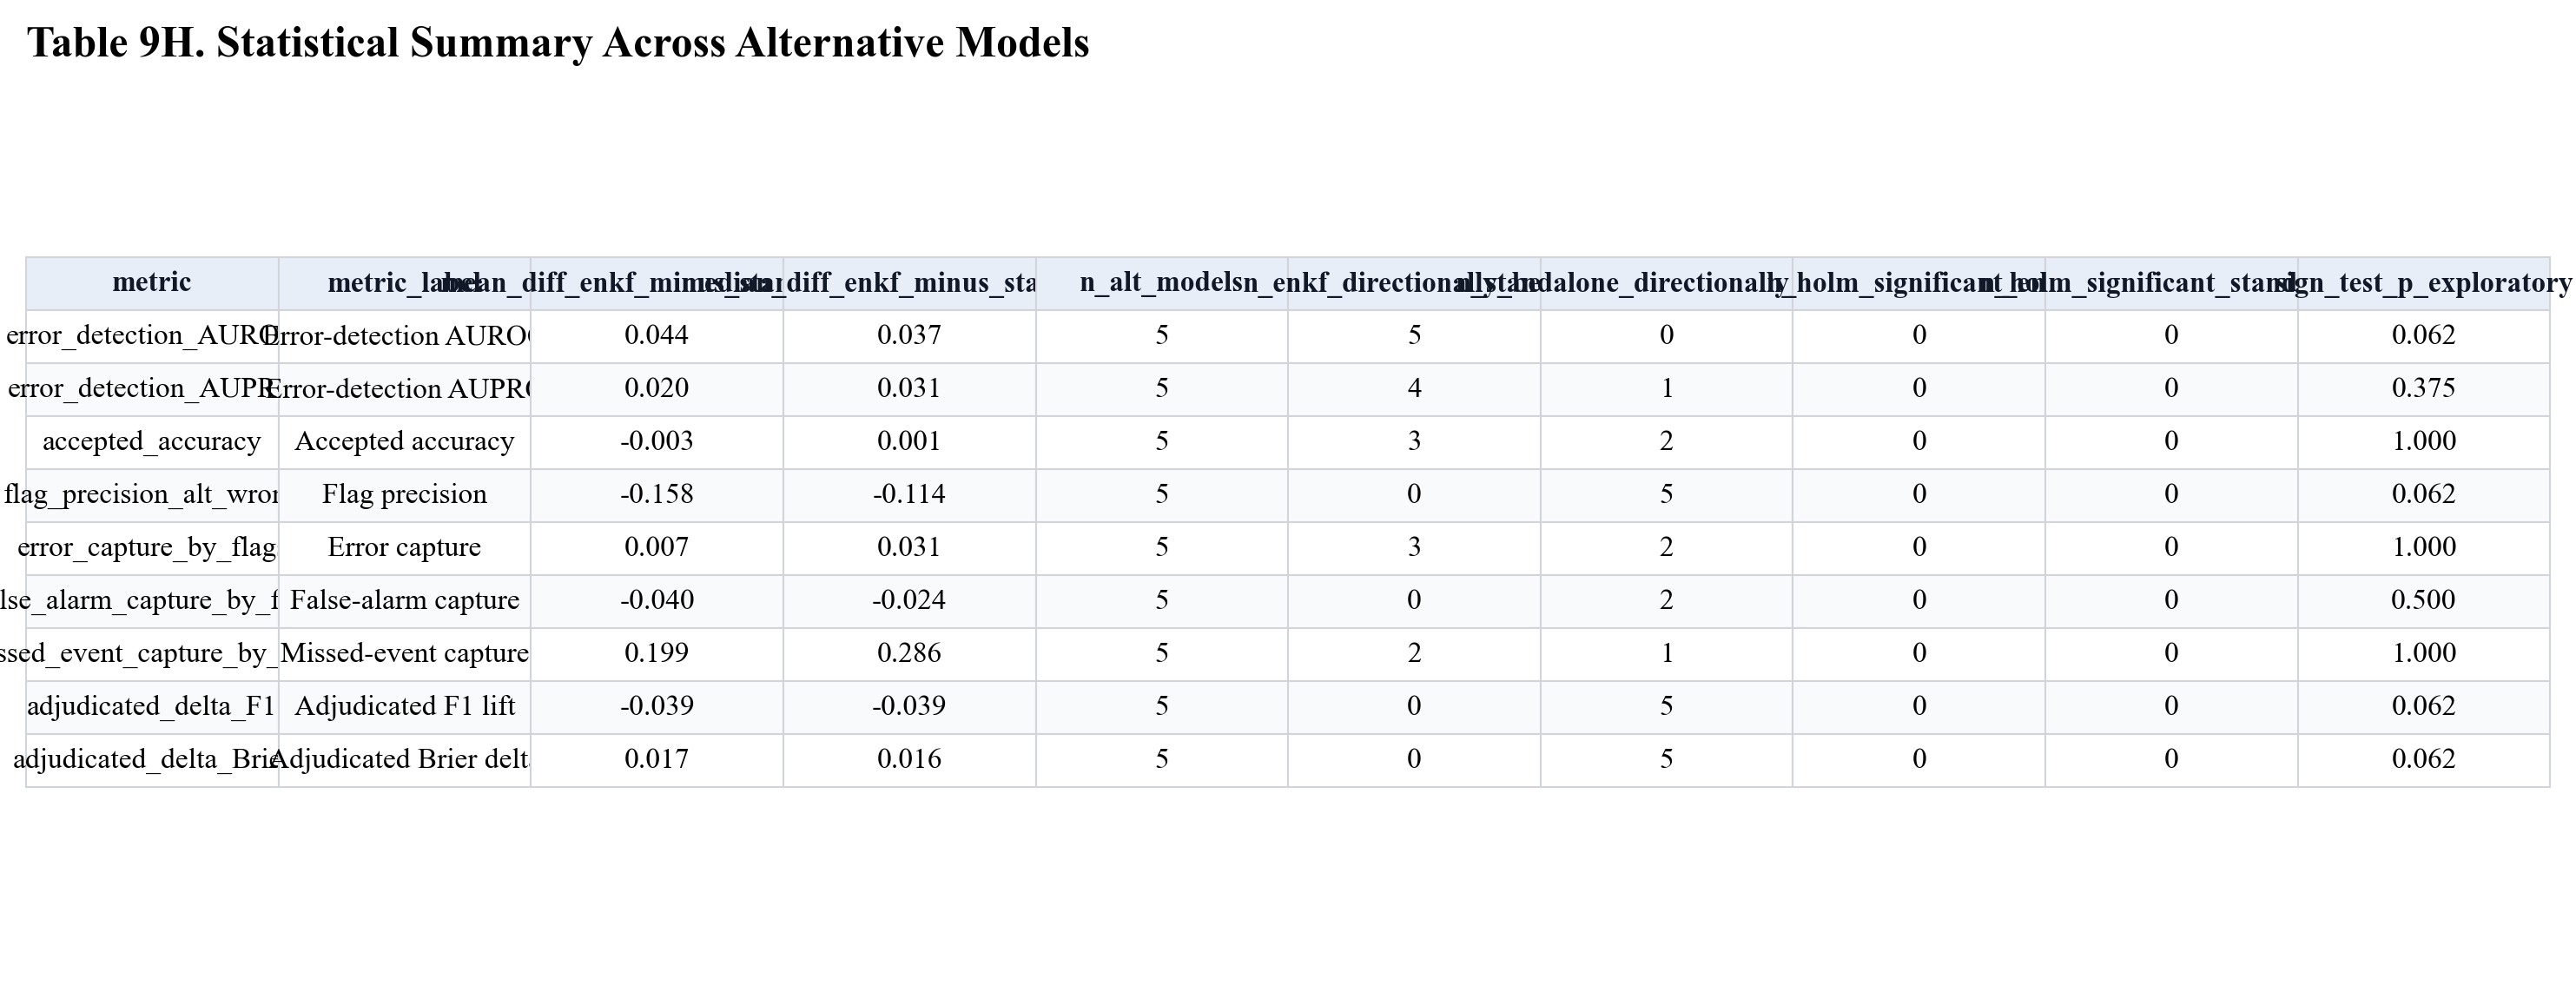

  saved output_refactored/validation_tools\Fig9F_validator_paired_bootstrap_forest.png
  saved output_refactored/validation_tools\Fig9F_validator_paired_bootstrap_forest.pdf


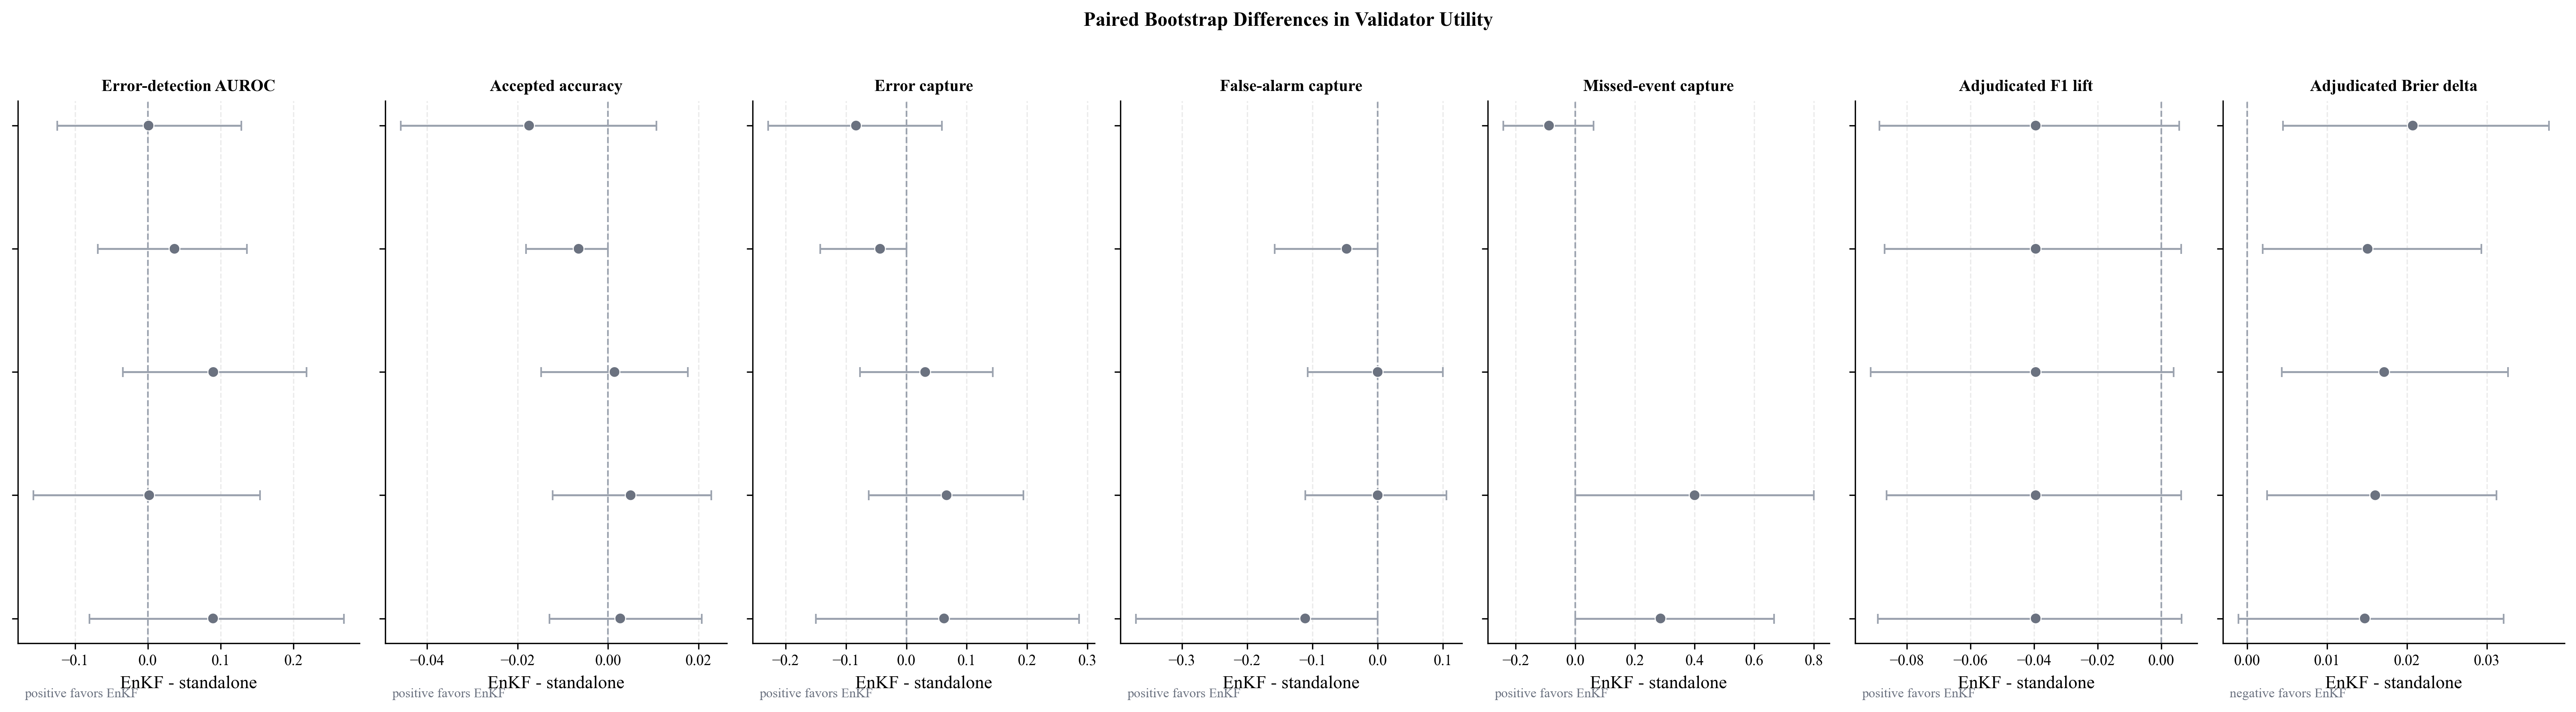

  saved table output_refactored/validation_tools\Table9_validator_significance_counts.csv


,metric_label,LSTM-EnKF validator,Standalone LSTM,No significant difference
0,Error-detection AUROC,0,0,5
1,Error-detection AUPRC,0,0,5
2,Accepted accuracy,0,0,5
3,Flag precision,0,0,5
4,Error capture,0,0,5
5,False-alarm capture,0,0,5
6,Missed-event capture,0,0,5
7,Adjudicated F1 lift,0,0,5
8,Adjudicated Brier delta,0,0,5


  saved output_refactored/validation_tools\Table9_validator_significance_counts.png
  saved output_refactored/validation_tools\Table9_validator_significance_counts.pdf


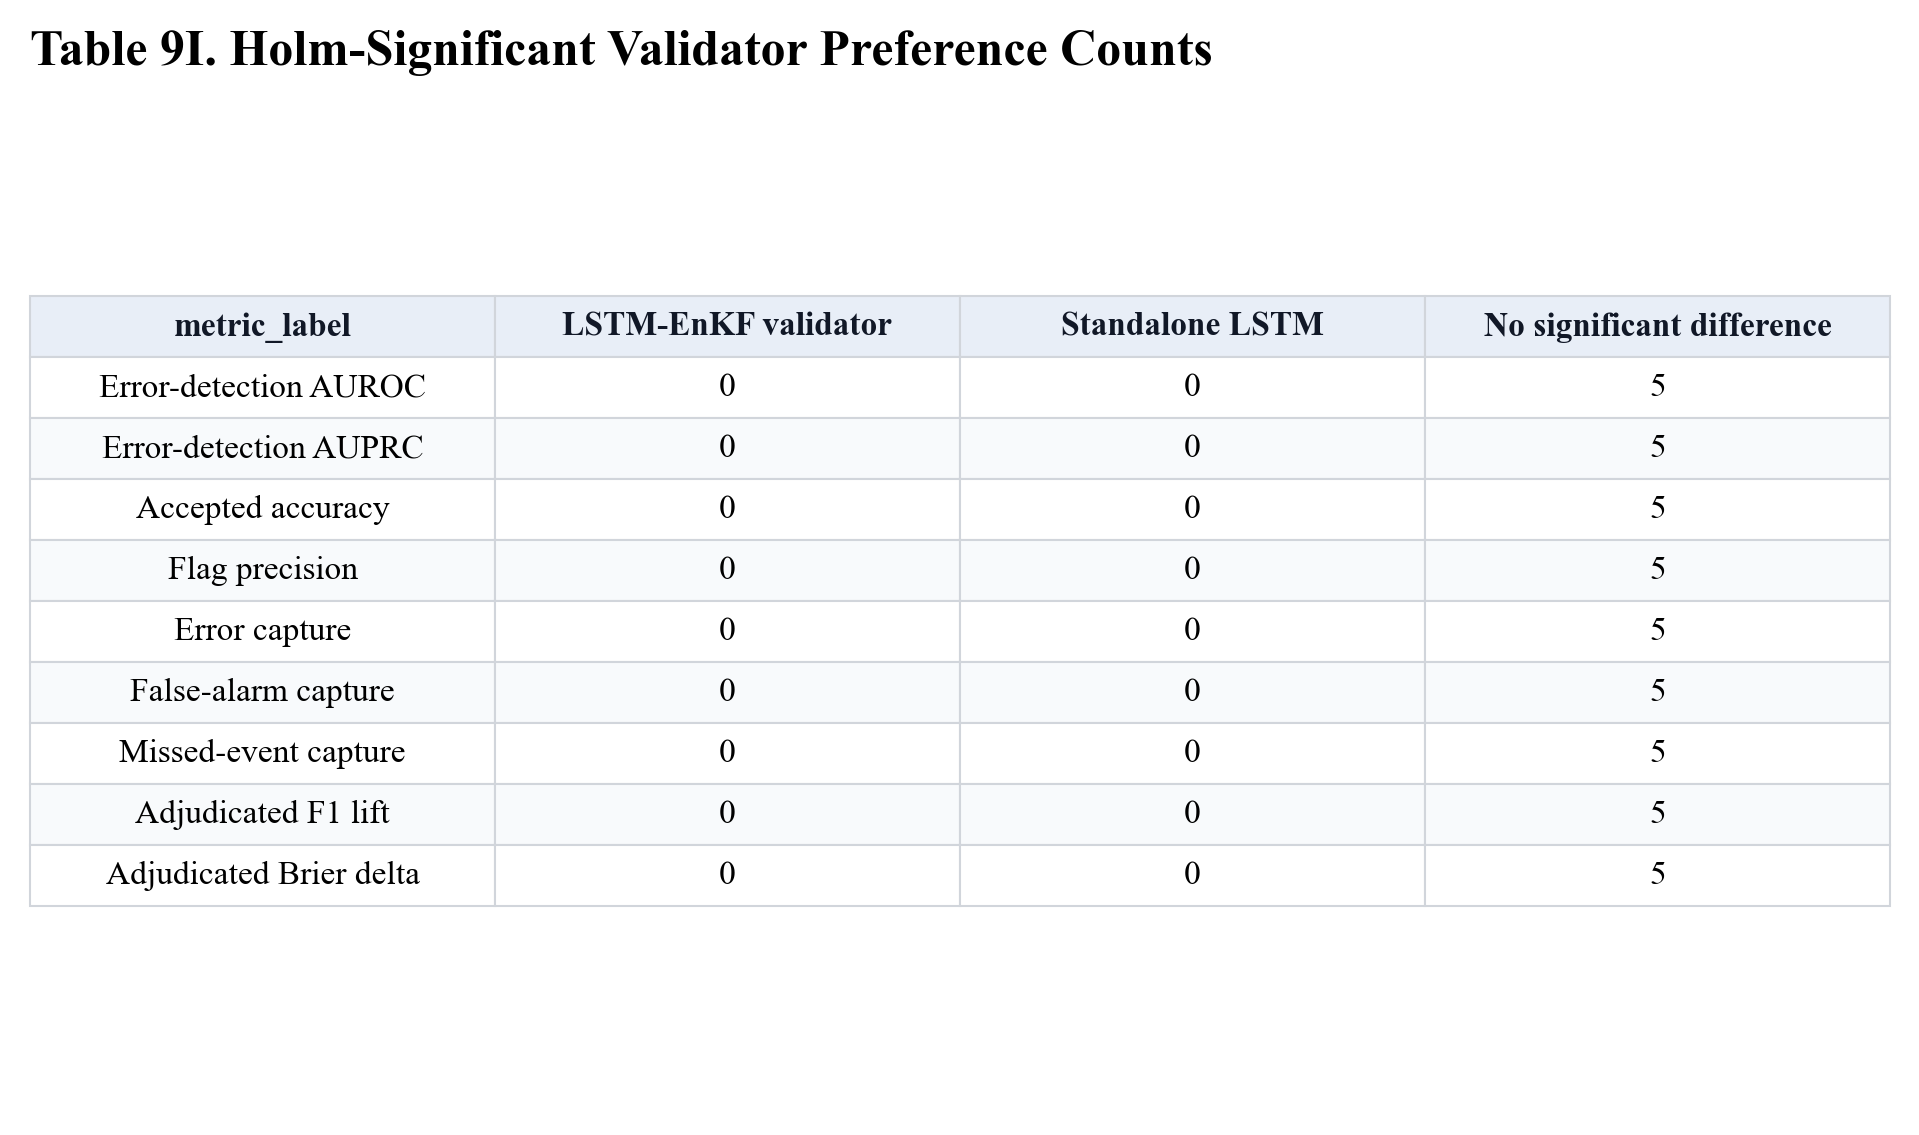

  saved output_refactored/validation_tools\Fig9G_validator_significance_counts.png
  saved output_refactored/validation_tools\Fig9G_validator_significance_counts.pdf


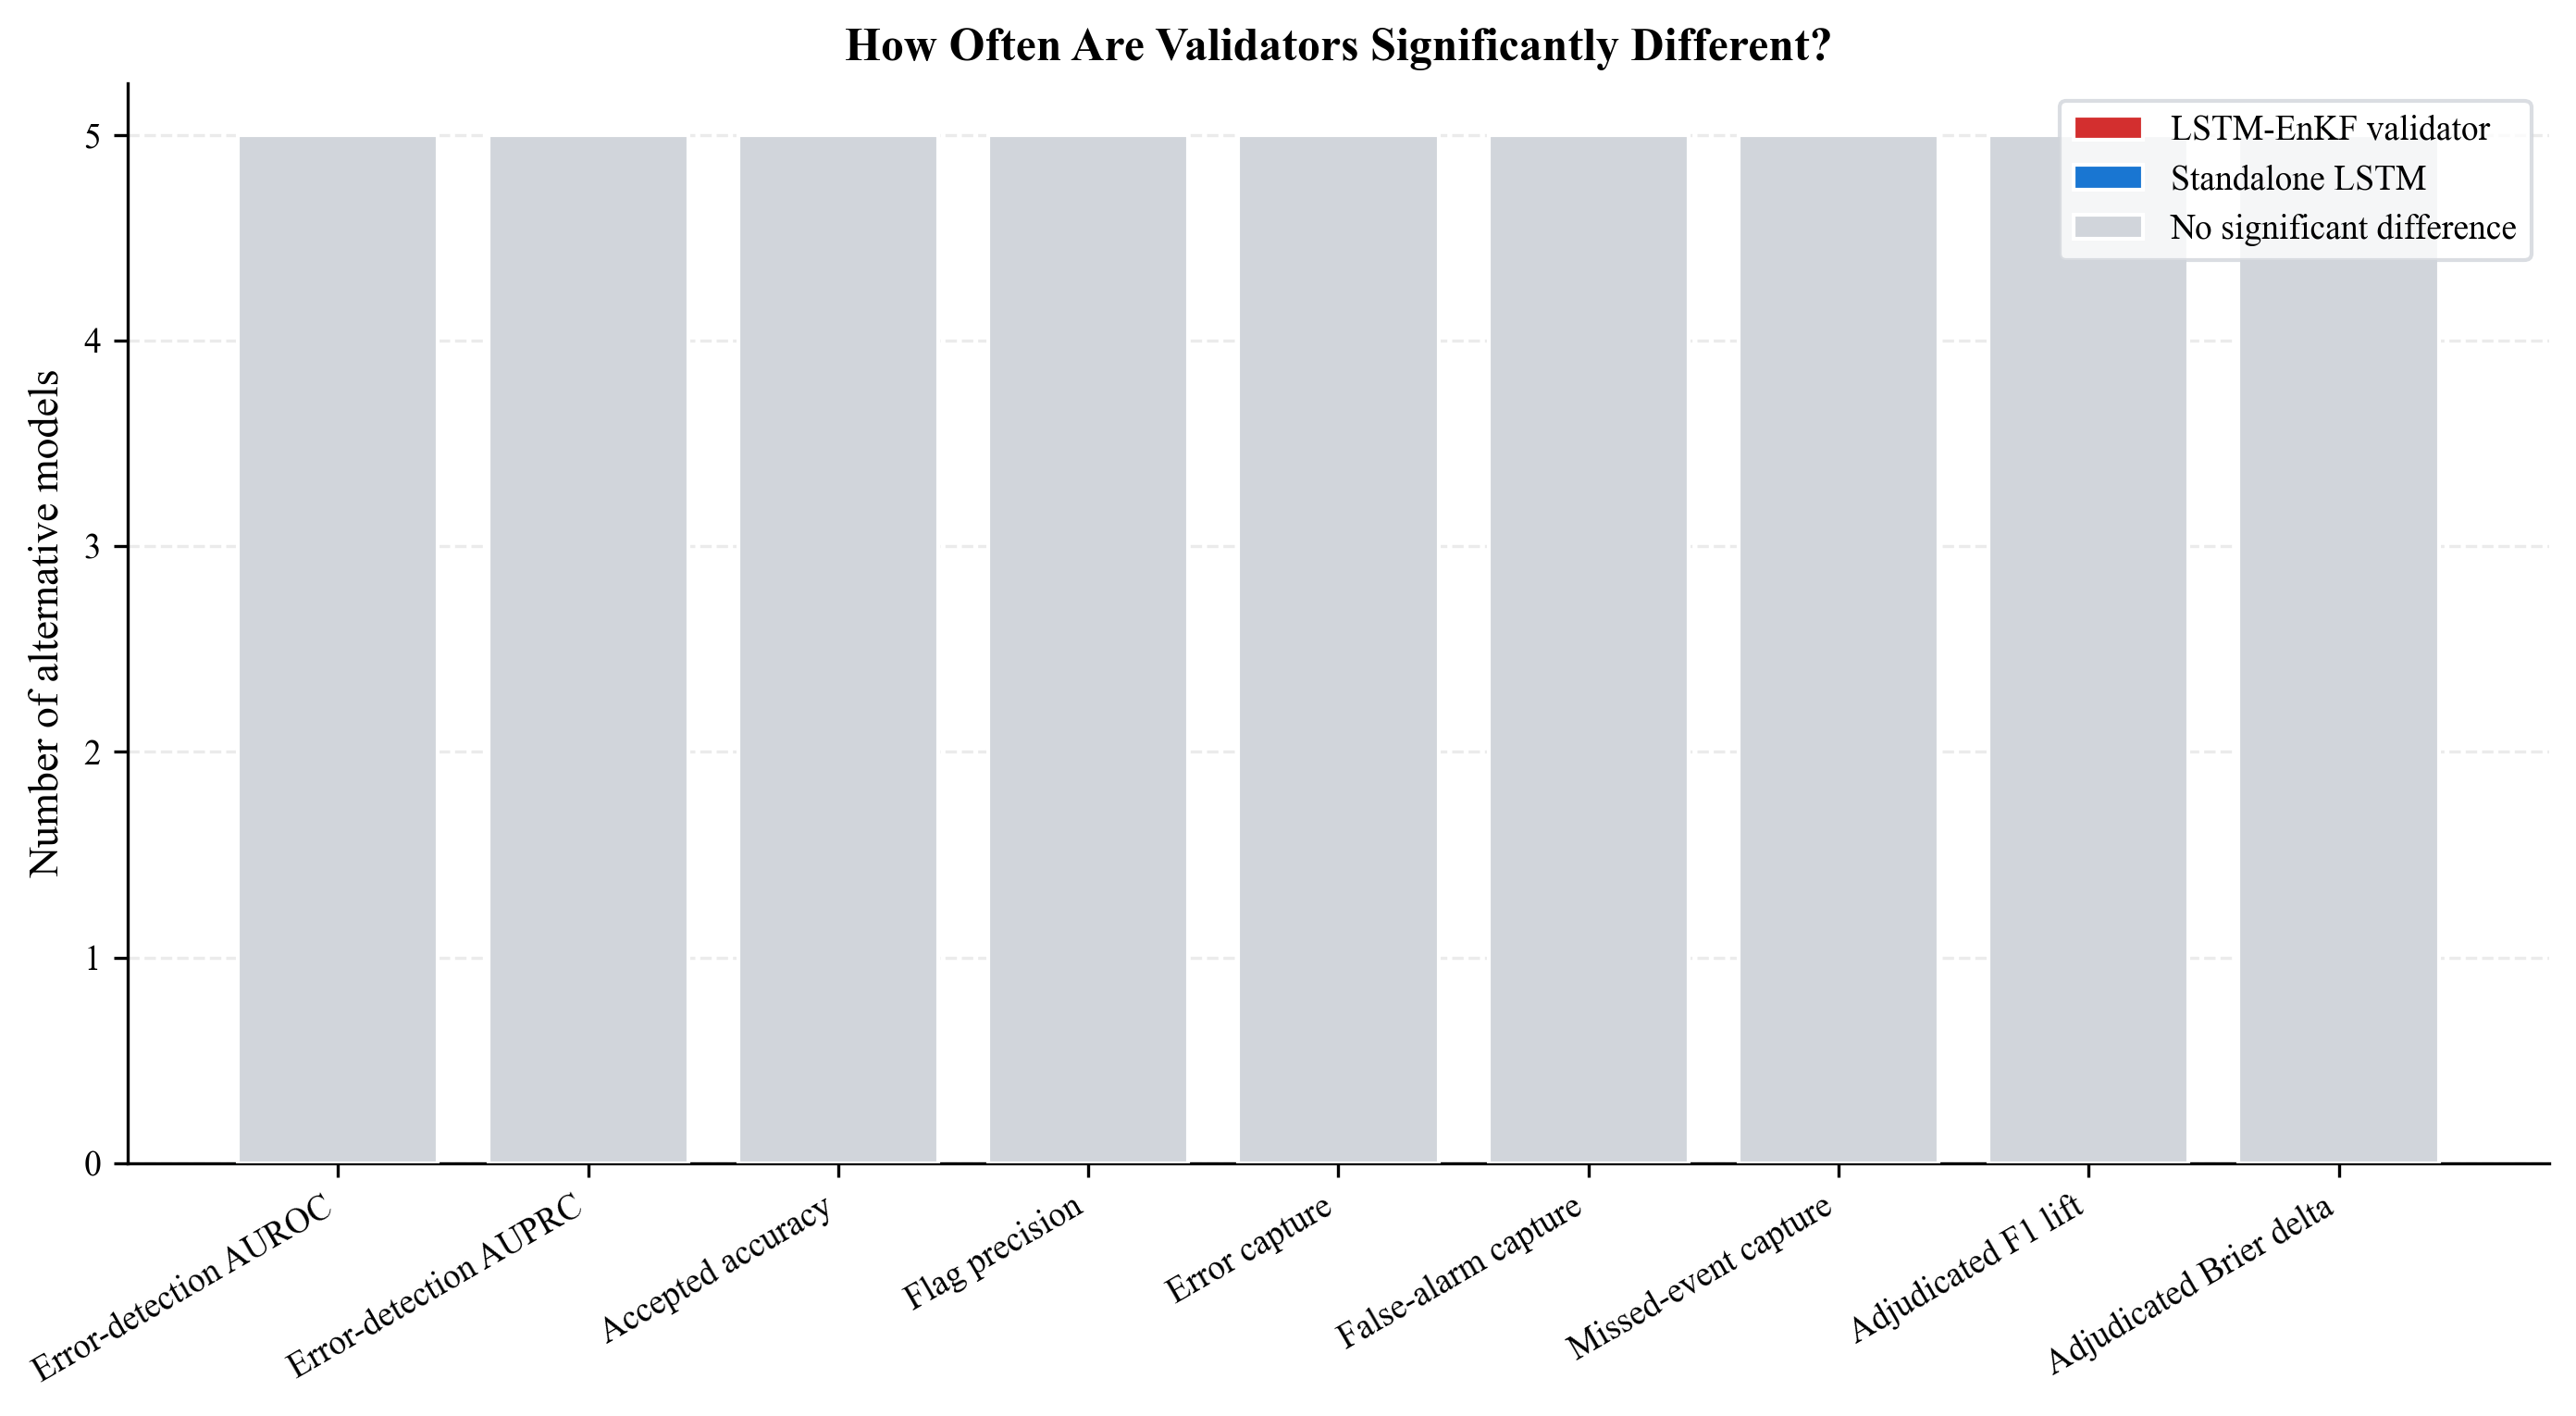

In [23]:
BOOTSTRAP_N_VALIDATOR = 2000
VALIDATOR_ALPHA = 0.05
rng = np.random.RandomState(SEED)

try:
    from scipy.stats import binomtest
except Exception:
    binomtest = None


def validator_utility_metrics(y, alt_prob, validator_prob, validator_threshold):
    y = np.asarray(y).astype(int)
    alt_prob = np.asarray(alt_prob, dtype=float)
    validator_prob = np.asarray(validator_prob, dtype=float)

    alt_pred = (alt_prob >= 0.5).astype(int)
    val_pred = (validator_prob >= validator_threshold).astype(int)
    agree = alt_pred == val_pred
    disagree = ~agree
    alt_wrong = alt_pred != y
    alt_fp = (alt_pred == 1) & (y == 0)
    alt_fn = (alt_pred == 0) & (y == 1)
    disputed_positive = (alt_pred == 1) & (val_pred == 0)
    disputed_negative = (alt_pred == 0) & (val_pred == 1)

    # Symmetric confidence-weighted contradiction. Same helper used in Cell 8.
    contradiction = disagreement_signal(alt_prob, validator_prob, validator_threshold)

    adjudicated_prob = np.where(agree, alt_prob, validator_prob)
    adjudicated_pred = np.where(agree, alt_pred, val_pred)

    base_f1 = f1_score(y, alt_pred, zero_division=0)
    base_brier = brier_score_loss(y, alt_prob)
    adjudicated_f1 = f1_score(y, adjudicated_pred, zero_division=0)
    adjudicated_brier = brier_score_loss(y, adjudicated_prob)

    # Minimum-event guard. Capture rates with very few false positives or false
    # negatives in the bootstrap sample are dominated by integer-jump noise.
    FA_MIN = 5
    false_alarm_capture = (
        float((alt_fp & disputed_positive).sum() / alt_fp.sum())
        if alt_fp.sum() >= FA_MIN else np.nan
    )
    missed_event_capture = (
        float((alt_fn & disputed_negative).sum() / alt_fn.sum())
        if alt_fn.sum() >= FA_MIN else np.nan
    )

    return {
        'error_detection_AUROC': safe_auc(alt_wrong.astype(int), contradiction),
        'error_detection_AUPRC': safe_ap(alt_wrong.astype(int), contradiction),
        'agreement_coverage': float(agree.mean()),
        'accepted_accuracy': accuracy_score(y[agree], alt_pred[agree]) if agree.any() else np.nan,
        'flag_precision_alt_wrong': float((alt_wrong & disagree).sum() / disagree.sum()) if disagree.sum() > 0 else np.nan,
        'error_capture_by_flags': float((alt_wrong & disagree).sum() / alt_wrong.sum()) if alt_wrong.sum() > 0 else np.nan,
        'false_alarm_capture_by_flags': false_alarm_capture,
        'missed_event_capture_by_flags': missed_event_capture,
        'adjudicated_delta_F1': float(adjudicated_f1 - base_f1),
        'adjudicated_delta_Brier': float(adjudicated_brier - base_brier),
    }


STAT_METRICS = {
    'error_detection_AUROC': {'higher_better': True, 'label': 'Error-detection AUROC'},
    'error_detection_AUPRC': {'higher_better': True, 'label': 'Error-detection AUPRC'},
    'accepted_accuracy': {'higher_better': True, 'label': 'Accepted accuracy'},
    'flag_precision_alt_wrong': {'higher_better': True, 'label': 'Flag precision'},
    'error_capture_by_flags': {'higher_better': True, 'label': 'Error capture'},
    'false_alarm_capture_by_flags': {'higher_better': True, 'label': 'False-alarm capture'},
    'missed_event_capture_by_flags': {'higher_better': True, 'label': 'Missed-event capture'},
    'adjudicated_delta_F1': {'higher_better': True, 'label': 'Adjudicated F1 lift'},
    'adjudicated_delta_Brier': {'higher_better': False, 'label': 'Adjudicated Brier delta'},
}

standalone_spec = validator_specs['Standalone LSTM']
enkf_spec = validator_specs['LSTM-EnKF validator']
stat_rows = []

for alt_key in alternate_keys:
    alt_name = alternate_names[alt_key]
    y, alt_prob, standalone_prob, enkf_prob = align_tail(
        y_test,
        streams[alt_key],
        streams[standalone_spec['key']],
        streams[enkf_spec['key']],
    )
    n = len(y)
    standalone_obs = validator_utility_metrics(y, alt_prob, standalone_prob, standalone_spec['threshold'])
    enkf_obs = validator_utility_metrics(y, alt_prob, enkf_prob, enkf_spec['threshold'])

    boot_by_metric = {metric: [] for metric in STAT_METRICS}
    for _ in range(BOOTSTRAP_N_VALIDATOR):
        idx = rng.choice(n, size=n, replace=True)
        y_b = y[idx]
        alt_b = alt_prob[idx]
        standalone_b = standalone_prob[idx]
        enkf_b = enkf_prob[idx]
        standalone_m = validator_utility_metrics(y_b, alt_b, standalone_b, standalone_spec['threshold'])
        enkf_m = validator_utility_metrics(y_b, alt_b, enkf_b, enkf_spec['threshold'])
        for metric in STAT_METRICS:
            diff = enkf_m[metric] - standalone_m[metric]
            if np.isfinite(diff):
                boot_by_metric[metric].append(diff)

    for metric, info in STAT_METRICS.items():
        observed_diff = enkf_obs[metric] - standalone_obs[metric]
        boot = np.asarray(boot_by_metric[metric], dtype=float)
        if len(boot) > 0:
            ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
            p_raw = bootstrap_p_two_sided(boot)
        else:
            ci_lo = ci_hi = p_raw = np.nan

        if np.isfinite(ci_lo) and np.isfinite(ci_hi) and ci_lo > 0:
            direction = 'EnKF higher'
        elif np.isfinite(ci_lo) and np.isfinite(ci_hi) and ci_hi < 0:
            direction = 'Standalone higher'
        else:
            direction = 'No clear difference'

        if metric == 'adjudicated_delta_Brier':
            if np.isfinite(ci_lo) and np.isfinite(ci_hi) and ci_hi < 0:
                preferred = 'LSTM-EnKF validator'
            elif np.isfinite(ci_lo) and np.isfinite(ci_hi) and ci_lo > 0:
                preferred = 'Standalone LSTM'
            else:
                preferred = 'No significant difference'
        else:
            if np.isfinite(ci_lo) and np.isfinite(ci_hi) and ci_lo > 0:
                preferred = 'LSTM-EnKF validator'
            elif np.isfinite(ci_lo) and np.isfinite(ci_hi) and ci_hi < 0:
                preferred = 'Standalone LSTM'
            else:
                preferred = 'No significant difference'

        stat_rows.append({
            'alternative_model': alt_name,
            'metric': metric,
            'metric_label': info['label'],
            'standalone_value': standalone_obs[metric],
            'enkf_value': enkf_obs[metric],
            'diff_enkf_minus_standalone': observed_diff,
            'ci_lo': ci_lo,
            'ci_hi': ci_hi,
            'p_bootstrap_raw': p_raw,
            'direction_raw': direction,
            'preferred_validator_raw': preferred,
            'n_bootstrap_valid': int(len(boot)),
        })

stat_df = pd.DataFrame(stat_rows)
stat_df['p_holm'] = holm_adjust(stat_df['p_bootstrap_raw'].values)

preferred_holm = []
for _, row in stat_df.iterrows():
    # Use CI direction plus Holm significance to avoid overclaiming from p alone.
    if row['p_holm'] < VALIDATOR_ALPHA and row['ci_lo'] > 0:
        preferred = 'LSTM-EnKF validator' if row['metric'] != 'adjudicated_delta_Brier' else 'Standalone LSTM'
    elif row['p_holm'] < VALIDATOR_ALPHA and row['ci_hi'] < 0:
        preferred = 'Standalone LSTM' if row['metric'] != 'adjudicated_delta_Brier' else 'LSTM-EnKF validator'
    else:
        preferred = 'No significant difference'
    preferred_holm.append(preferred)
stat_df['preferred_validator_holm'] = preferred_holm
stat_df['significant_holm_0.05'] = stat_df['preferred_validator_holm'] != 'No significant difference'

save_table(stat_df, 'Table9_validator_paired_bootstrap_tests.csv',
           'Table 9G. Paired Bootstrap Tests: EnKF Validator Minus Standalone Validator',
           render=False)

# Summarize across alternative models. This is descriptive/exploratory because
# the alternative models are not independent of each other.
summary_rows = []
for metric, info in STAT_METRICS.items():
    sub = stat_df[stat_df['metric'] == metric].copy()
    if info['higher_better']:
        enkf_better = int((sub['diff_enkf_minus_standalone'] > 0).sum())
        standalone_better = int((sub['diff_enkf_minus_standalone'] < 0).sum())
        sig_enkf = int((sub['preferred_validator_holm'] == 'LSTM-EnKF validator').sum())
        sig_standalone = int((sub['preferred_validator_holm'] == 'Standalone LSTM').sum())
    else:
        enkf_better = int((sub['diff_enkf_minus_standalone'] < 0).sum())
        standalone_better = int((sub['diff_enkf_minus_standalone'] > 0).sum())
        sig_enkf = int((sub['preferred_validator_holm'] == 'LSTM-EnKF validator').sum())
        sig_standalone = int((sub['preferred_validator_holm'] == 'Standalone LSTM').sum())
    n_non_tie = enkf_better + standalone_better
    sign_p = np.nan
    if binomtest is not None and n_non_tie > 0:
        sign_p = float(binomtest(max(enkf_better, standalone_better), n_non_tie, 0.5).pvalue)
    summary_rows.append({
        'metric': metric,
        'metric_label': info['label'],
        'mean_diff_enkf_minus_standalone': sub['diff_enkf_minus_standalone'].mean(),
        'median_diff_enkf_minus_standalone': sub['diff_enkf_minus_standalone'].median(),
        'n_alt_models': int(len(sub)),
        'n_enkf_directionally_better': enkf_better,
        'n_standalone_directionally_better': standalone_better,
        'n_holm_significant_enkf': sig_enkf,
        'n_holm_significant_standalone': sig_standalone,
        'sign_test_p_exploratory': sign_p,
    })
stat_summary_df = pd.DataFrame(summary_rows)
save_table(stat_summary_df, 'Table9_validator_statistical_summary.csv',
           'Table 9H. Statistical Summary Across Alternative Models')

# Figure: paired-difference forest plots for the main validation criteria.
forest_metrics = [
    'error_detection_AUROC',
    'accepted_accuracy',
    'error_capture_by_flags',
    'false_alarm_capture_by_flags',
    'missed_event_capture_by_flags',
    'adjudicated_delta_F1',
    'adjudicated_delta_Brier',
]
fig, axes = plt.subplots(1, len(forest_metrics), figsize=(3.1 * len(forest_metrics), 5.8), sharey=True)
if len(forest_metrics) == 1:
    axes = [axes]
models = stat_df['alternative_model'].drop_duplicates().tolist()
y_pos = np.arange(len(models))
for ax, metric in zip(axes, forest_metrics):
    sub = stat_df[stat_df['metric'] == metric].set_index('alternative_model').reindex(models)
    diff = sub['diff_enkf_minus_standalone'].values.astype(float)
    lo = sub['ci_lo'].values.astype(float)
    hi = sub['ci_hi'].values.astype(float)
    xerr = np.vstack([diff - lo, hi - diff])
    colors = np.where(sub['significant_holm_0.05'].values, '#D32F2F', '#6B7280')
    ax.axvline(0, color='#9CA3AF', linestyle='--', linewidth=1)
    ax.errorbar(diff, y_pos, xerr=xerr, fmt='none', ecolor='#9CA3AF', elinewidth=1.2, capsize=3, zorder=2)
    ax.scatter(diff, y_pos, c=colors, s=42, edgecolor='white', linewidth=0.6, zorder=3)
    ax.set_title(STAT_METRICS[metric]['label'], fontweight='bold', fontsize=10)
    ax.grid(axis='x', alpha=0.25, linestyle='--', zorder=0)
    ax.set_xlabel('EnKF - standalone')
    if metric == 'adjudicated_delta_Brier':
        ax.text(0.02, -0.10, 'negative favors EnKF', transform=ax.transAxes, fontsize=8, color='#6B7280')
    else:
        ax.text(0.02, -0.10, 'positive favors EnKF', transform=ax.transAxes, fontsize=8, color='#6B7280')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(models)
for ax in axes[1:]:
    ax.set_yticks(y_pos)
    ax.set_yticklabels([])
axes[0].invert_yaxis()
fig.suptitle('Paired Bootstrap Differences in Validator Utility', fontweight='bold', y=1.02)
plt.tight_layout()
savefig(fig, 'Fig9F_validator_paired_bootstrap_forest')
plt.show()

# Figure: count of statistically preferred validator by criterion.
count_rows = []
for metric, info in STAT_METRICS.items():
    sub = stat_df[stat_df['metric'] == metric]
    count_rows.append({
        'metric_label': info['label'],
        'LSTM-EnKF validator': int((sub['preferred_validator_holm'] == 'LSTM-EnKF validator').sum()),
        'Standalone LSTM': int((sub['preferred_validator_holm'] == 'Standalone LSTM').sum()),
        'No significant difference': int((sub['preferred_validator_holm'] == 'No significant difference').sum()),
    })
preference_counts = pd.DataFrame(count_rows)
save_table(preference_counts, 'Table9_validator_significance_counts.csv',
           'Table 9I. Holm-Significant Validator Preference Counts')

fig, ax = plt.subplots(figsize=(9.5, 5.2))
x = np.arange(len(preference_counts))
bottom = np.zeros(len(preference_counts))
for label, color in [('LSTM-EnKF validator', '#D32F2F'), ('Standalone LSTM', '#1976D2'), ('No significant difference', '#D1D5DB')]:
    vals = preference_counts[label].values
    ax.bar(x, vals, bottom=bottom, label=label, color=color, edgecolor='white', zorder=3)
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(preference_counts['metric_label'], rotation=30, ha='right')
ax.set_ylabel('Number of alternative models')
ax.set_title('How Often Are Validators Significantly Different?', fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='--', zorder=0)
ax.legend(frameon=True, edgecolor='#D1D5DB')
plt.tight_layout()
savefig(fig, 'Fig9G_validator_significance_counts')
plt.show()

## Artifact Manifest

In [24]:
manifest_rows = []
for p in sorted(Path(VALIDATION_DIR).glob('Table9_*.csv')):
    manifest_rows.append({'artifact_type': 'table_csv', 'path': str(p)})
for p in sorted(Path(VALIDATION_DIR).glob('Fig9*.png')):
    manifest_rows.append({'artifact_type': 'figure_png', 'path': str(p)})
for p in sorted(Path(VALIDATION_DIR).glob('Fig9*.pdf')):
    manifest_rows.append({'artifact_type': 'figure_pdf', 'path': str(p)})
manifest = pd.DataFrame(manifest_rows)
save_table(manifest, 'Table9_artifact_manifest.csv',
           'Table 9J. Validation-Tool Artifact Manifest', render=False)

  saved table output_refactored/validation_tools\Table9_artifact_manifest.csv


,artifact_type,path
0,table_csv,output_refactored\validation_tools\Table9_agre...
1,table_csv,output_refactored\validation_tools\Table9_arti...
2,table_csv,output_refactored\validation_tools\Table9_cove...
3,table_csv,output_refactored\validation_tools\Table9_disa...
4,table_csv,output_refactored\validation_tools\Table9_incr...
5,table_csv,output_refactored\validation_tools\Table9_mode...
6,table_csv,output_refactored\validation_tools\Table9_vali...
7,table_csv,output_refactored\validation_tools\Table9_vali...
8,table_csv,output_refactored\validation_tools\Table9_vali...
9,table_csv,output_refactored\validation_tools\Table9_vali...


'output_refactored/validation_tools\\Table9_artifact_manifest.csv'